# How to Measure School Quality from Exam Results

> **⚠️ FROZEN COPY — pinned to exam years 2021–2025.**
> This is the canonical base analysis; it deliberately ignores any later
> years (2026+) dropped into the data directory, so its results never shift.
> The live notebook (`how_to_measure_school_quality.ipynb`) has no year cap
> and stays current. This copy sets `WRITE_OUTPUT_FILES = False`, so
> re-running it cannot overwrite the live map/analyst data.

**Context:** OKE Warszawa publishes [results of the Polish 8th-grade exam](https://www.oke.waw.pl/egzamin-osmoklasisty/wyniki-sprawozdania/) (egzamin ósmoklasisty)
for every school each year. This frozen copy uses exam years 2021–2025.

**Goal of this notebook:** Decide *which single number* best represents a school's quality,
given the data we have — and show the reasoning behind that choice.

**Why this matters:** The number we choose will colour the dots on a public map.
A bad choice can unfairly label a school as weak (or strong) due to statistical noise,
not real differences in teaching quality.

**Structure:**
1. Load data
2. Show why only 3 subjects are usable
3. Choose the best per-year metric and the best way to aggregate across years
   (jointly: 8 metrics × 5 aggregation methods = 40 candidates, evaluated by LOO stability)
4. Identify schools that are *consistently* in the top
5. Combine all 3 subjects into one score
6. Final metric definition

## 0. Setup

In [1]:
# Run with: uv run jupyter lab
import json
import re
import time
import unicodedata
from datetime import datetime
from pathlib import Path
from typing import NamedTuple

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import ticker
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120  # sharper inline figures (Matplotlib default is ~100 DPI)

DATA_DIR = Path('../data/egzamin-osmoklasisty')
OUTPUT_DIR = Path('../output')          # xlsx files for analysts
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DATA_DIR = Path('../docs/data')    # JSON files consumed by the map app
DOCS_DATA_DIR.mkdir(parents=True, exist_ok=True)

# ── Run configuration ────────────────────────────────────────────────────────
# FORCE_REGENERATE:   skip the idempotence check and always rewrite the exports.
# WRITE_OUTPUT_FILES: actually write the JSON/xlsx files to disk. Set False in a
#   year-pinned "decision record" / archive copy so re-running it can't overwrite
#   the live data — only an unrestricted production copy should write outputs.
FORCE_REGENERATE = False
WRITE_OUTPUT_FILES = False  # FROZEN 2021–2025 copy: must not overwrite live data

CORE_SUBJECTS     = ['polski', 'matematyka', 'angielski']
MINORITY_SUBJECTS = ['francuski', 'hiszpanski', 'niemiecki', 'rosyjski', 'wloski']
ALL_SUBJECTS      = CORE_SUBJECTS + MINORITY_SUBJECTS   # 3 core + 5 minor languages
# Subject code -> English display name (all subjects).
SUBJECT_LABELS = {
    'polski':     'Polish',
    'matematyka': 'Maths',
    'angielski':  'English',
    'francuski':  'French',
    'hiszpanski': 'Spanish',
    'niemiecki':  'German',
    'rosyjski':   'Russian',
    'wloski':     'Italian',
}
SUBJECT_COLORS = {
    'polski':    '#2166ac',
    'matematyka': '#d6604d',
    'angielski': '#1a9850',
}

# ── Helper: render DataFrame as HTML table with min-per-row highlighted ──────
# Manual HTML rendering with inline <td style="..."> — works around CSS
# sanitisers in VS Code / nbconvert that strip <style> blocks from Jupyter
# Styler output.
from IPython.display import HTML


def render_min_highlighted_table(df, caption, value_fmt='{:.3f}', axis=1):
    """Display df as an HTML table with minimum cells highlighted green.

    axis=1 (default): highlight minimum of each row
    axis=0:           highlight minimum of each column
    """
    # Pre-compute the minimum per row or per column
    if axis == 1:
        mins_per_row = df.min(axis=1)
        def is_min(row_idx, col_idx, val):
            return pd.notna(val) and pd.notna(mins_per_row.iloc[row_idx]) and val == mins_per_row.iloc[row_idx]
    elif axis == 0:
        mins_per_col = df.min(axis=0)
        def is_min(row_idx, col_idx, val):
            return pd.notna(val) and pd.notna(mins_per_col.iloc[col_idx]) and val == mins_per_col.iloc[col_idx]
    else:
        raise ValueError(f'axis must be 0 or 1, got {axis}')

    rows_html = []
    for row_idx, (idx, row) in enumerate(df.iterrows()):
        cells = []
        for col_idx, val in enumerate(row):
            bg = 'background-color: #c6efce; ' if is_min(row_idx, col_idx, val) else ''
            fmt_val = value_fmt.format(val) if pd.notna(val) else ''
            cells.append(
                f'<td style="padding: 4px 10px; border: 1px solid #ddd; '
                f'text-align: right; {bg}">{fmt_val}</td>'
            )
        idx_label = ' / '.join(str(x) for x in idx) if isinstance(idx, tuple) else str(idx)
        rows_html.append(
            f'<tr><th style="padding: 4px 10px; border: 1px solid #ddd; '
            f'text-align: left; background: #f8f8f8;">{idx_label}</th>'
            f'{"".join(cells)}</tr>'
        )
    headers_html = ''.join(
        f'<th style="padding: 4px 10px; border: 1px solid #ddd; '
        f'background: #f8f8f8;">{c}</th>'
        for c in df.columns
    )
    index_label = (
        ' / '.join(df.index.names)
        if isinstance(df.index, pd.MultiIndex)
        else (df.index.name or '')
    )
    html = (
        f'<p style="margin: 4px 0; font-style: italic;">{caption}</p>'
        f'<table style="border-collapse: collapse; font-size: 0.9em;">'
        f'<thead><tr><th style="padding: 4px 10px; border: 1px solid #ddd; '
        f'background: #f8f8f8;">{index_label}</th>{headers_html}</tr></thead>'
        f'<tbody>{"".join(rows_html)}</tbody></table>'
    )
    return HTML(html)

## 1. Load data

Each year's results come in a separate Excel file. We load them all and stack them
into one DataFrame where each row is one school in one year.

In [2]:
YEAR_FILE_RE = re.compile(r'^\d{4}', re.IGNORECASE)


def normalize_text(text: str) -> str:
    text = unicodedata.normalize('NFKD', text)
    text = ''.join(ch for ch in text if not unicodedata.combining(ch))
    text = text.replace('ł', 'l').replace('Ł', 'L')  # ł has no NFKD decomposition
    text = text.replace('\n', ' ')
    return re.sub(r'\s+', ' ', text).lower().strip()


def clean_header_value(value: object) -> str:
    if value is None:
        return ''
    text = str(value)
    if text.startswith('Unnamed:') or text == 'nan':
        return ''
    return re.sub(r'\s+', ' ', text.replace('\n', ' ')).strip()


def normalize_multiindex_columns(columns: pd.MultiIndex) -> pd.MultiIndex:
    lvl0_values, lvl1_values = [], []
    last_lvl0 = 'meta'
    for raw0, raw1 in columns.to_list():
        lvl0_raw = clean_header_value(raw0)
        lvl1_raw = clean_header_value(raw1)
        if lvl0_raw:
            last_lvl0 = normalize_text(lvl0_raw).removeprefix('jezyk ')
        lvl0_values.append(last_lvl0)
        lvl1_values.append(normalize_text(lvl1_raw) if lvl1_raw else 'value')
    return pd.MultiIndex.from_arrays([lvl0_values, lvl1_values], names=['subject', 'metric'])


def read_exam_file(path: Path) -> pd.DataFrame:
    year = int(YEAR_FILE_RE.match(path.name).group(0))
    df = pd.read_excel(path, sheet_name='SAS', header=[0, 1])
    df.columns = normalize_multiindex_columns(df.columns)
    df[('meta', 'year')] = year
    return df


# ── Provenance: every source file in DATA_DIR must be documented ───────
# SOURCES.csv records where each xlsx came from (webpage, document link, date).
# Raise loudly if a file present in DATA_DIR is missing from it, to force
# documenting provenance whenever a new file is dropped in. Dotfiles (e.g.
# LibreOffice .~lock files) are ignored — they are not source data.
def source_files(directory):
    return sorted(q for q in directory.glob('*.xlsx*') if not q.name.startswith('.'))

sources = pd.read_csv(DATA_DIR / 'SOURCES.csv', dtype=str)
documented = {name.strip() for name in sources['file_name'].dropna()}
present = {q.name for q in source_files(DATA_DIR)}
undocumented = present - documented
if undocumented:
    raise ValueError(
        f'Source files in {DATA_DIR} missing from SOURCES.csv: {sorted(undocumented)}.\n'
        f'Add a row (file_name, year, webpage, document_link, retrieved_date, notes) '
        f'documenting where each came from.'
    )
stale = documented - present
if stale:
    print(f'WARNING: SOURCES.csv lists files not on disk: {sorted(stale)}')

# ── FROZEN COPY: pin to exam years 2021–2025 ──────────────────────────────
# This copy is the canonical 2021–2025 base analysis; it must NOT shift when
# later exam years (2026+) are dropped into DATA_DIR. The live notebook has no
# cap and stays current. Loading is restricted to FROZEN_YEARS and asserted.
FROZEN_YEARS = [2021, 2022, 2023, 2024, 2025]
files = [
    p for p in source_files(DATA_DIR)
    if YEAR_FILE_RE.match(p.name)
    and int(YEAR_FILE_RE.match(p.name).group(0)) in FROZEN_YEARS
]
assert files, f'No data files found in {DATA_DIR}'

# Assert exactly the frozen set is loaded, so a missing file (or a future
# year slipping through) fails loudly instead of silently changing the base.
loaded_years = sorted(int(YEAR_FILE_RE.match(p.name).group(0)) for p in files)
assert loaded_years == FROZEN_YEARS, (
    f'Frozen copy expects exactly {FROZEN_YEARS}, but loaded {loaded_years}. '
    f'Check DATA_DIR / SOURCES.csv.'
)

raw_frames = [read_exam_file(p) for p in files]
df_raw = pd.concat(raw_frames, ignore_index=True)

print(f'Loaded {len(files)} files (FROZEN to 2021–2025): {loaded_years}')
print(f'Total rows: {len(df_raw):,}  (one row = one school × one year)')

Loaded 5 files (FROZEN to 2021–2025): [2021, 2022, 2023, 2024, 2025]
Total rows: 8,260  (one row = one school × one year)


In [3]:
# Build a flat working DataFrame with consistent column names
# Each subject contributes 3 columns: n_students, median_pct, mean_pct

records = {}
records['rspo']        = df_raw[('meta', 'rspo')]
records['year']        = df_raw[('meta', 'year')]
records['school_name'] = df_raw[('meta', 'nazwa szkoly')]
records['is_public']  = df_raw.get(('meta', 'czy publiczna'), pd.Series(dtype=str))
records['gmina']      = df_raw.get(('meta', 'gmina - nazwa'), pd.Series(dtype=str))
records['powiat']     = df_raw.get(('meta', 'powiat - nazwa'), pd.Series(dtype=str))
records['typ_gminy']  = df_raw.get(('meta', 'typ gminy'), pd.Series(dtype=str))
records['miejscowosc']= df_raw.get(('meta', 'miejscowosc'), pd.Series(dtype=str))
records['ulica_nr']   = df_raw.get(('meta', 'ulica nr'), pd.Series(dtype=str))

for subject_code in ALL_SUBJECTS:
    records[f'n_{subject_code}']      = pd.to_numeric(df_raw[(subject_code, 'liczba zdajacych')])
    records[f'median_{subject_code}'] = pd.to_numeric(df_raw[(subject_code, 'mediana (%)')])
    records[f'mean_{subject_code}']   = pd.to_numeric(df_raw[(subject_code, 'wynik sredni (%)')])

df = pd.DataFrame(records)
df = df[df['n_polski'].notna() & (df['n_polski'] > 0)].copy()
print(f'Working dataset: {len(df):,} rows, {df["rspo"].nunique():,} unique schools')
print(f'Columns with data: {[c for c in df.columns if c.startswith("n_")]}')

Working dataset: 8,259 rows, 1,790 unique schools
Columns with data: ['n_polski', 'n_matematyka', 'n_angielski', 'n_francuski', 'n_hiszpanski', 'n_niemiecki', 'n_rosyjski', 'n_wloski']


### Remove rows with missing data in core subjects

In [4]:
# ── H1: does n < 5 students → missing median/mean? ───────────────────────────
print('H1: % missing median by student count group\n')
h1_rows = []
for subject in CORE_SUBJECTS:
    n_col, median_column = f'n_{subject}', f'median_{subject}'
    tmp = df[[n_col, median_column]].dropna(subset=[n_col])
    for lower_bound, upper_bound, label in [(0, 5, 'n < 5'), (5, 10, '5 ≤ n < 10'), (10, None, 'n ≥ 10')]:
        mask = (tmp[n_col] < upper_bound) if upper_bound else (tmp[n_col] >= lower_bound)
        mask &= (tmp[n_col] >= lower_bound)
        sub = tmp[mask]
        h1_rows.append({
            'subject': SUBJECT_LABELS[subject],
            'group': label,
            'rows': len(sub),
            '% missing median': f"{sub[median_column].isna().mean():.1%}",
        })

display(
    pd.DataFrame(h1_rows)
    .pivot(index='group', columns='subject', values='% missing median')
    .loc[['n < 5', '5 ≤ n < 10', 'n ≥ 10']]
)

# ── H2: does 2021 have more missing data for n ≥ 5 schools? ──────────────────
print('\nH2: % missing median for schools with n ≥ 5, by year\n')
h2_rows = []
for year in sorted(df['year'].unique()):
    yr = df[df['year'] == year]
    for subject in CORE_SUBJECTS:
        n_col, median_column = f'n_{subject}', f'median_{subject}'
        subset = yr[yr[n_col] >= 5]
        h2_rows.append({
            'year': year,
            'subject': SUBJECT_LABELS[subject],
            '% missing': f"{subset[median_column].isna().mean():.1%}",
        })

display(
    pd.DataFrame(h2_rows)
    .pivot(index='year', columns='subject', values='% missing')
)

H1: % missing median by student count group



subject,English,Maths,Polish
group,,,
n < 5,100.0%,100.0%,100.0%
5 ≤ n < 10,21.3%,20.9%,21.0%
n ≥ 10,0.0%,0.0%,0.0%



H2: % missing median for schools with n ≥ 5, by year



subject,English,Maths,Polish
year,,,
2021,18.7%,18.0%,18.1%
2022,0.0%,0.0%,0.0%
2023,0.0%,0.0%,0.0%
2024,0.0%,0.0%,0.0%
2025,0.0%,0.0%,0.0%


In [5]:
# ── Drop rows missing core subject data ───────────────────────────────────────
complete_mask = pd.Series(True, index=df.index)
for subject in CORE_SUBJECTS:
    complete_mask &= df[f'median_{subject}'].notna()
    complete_mask &= df[f'mean_{subject}'].notna()

df_rejected = df[~complete_mask].copy()
df = df[complete_mask].copy()

def missing_subjects(row):
    return ', '.join(
        s for s in CORE_SUBJECTS
        if pd.isna(row[f'median_{s}']) or pd.isna(row[f'mean_{s}'])
    )

df_rejected['missing_subjects'] = df_rejected.apply(missing_subjects, axis=1)

print(f'Rejected: {len(df_rejected):,} rows  |  kept: {len(df):,}')
print()
print('Rejected rows by year:')
kept_by_year = df.groupby('year')['rspo'].count().rename('total')
rejected_by_year    = df_rejected.groupby('year').agg(rows=('rspo', 'count'), unique_schools=('rspo', 'nunique'))
rejected_by_year['% of year'] = (rejected_by_year['rows'] / (rejected_by_year['rows'] + kept_by_year) * 100).round(1).astype(str) + '%'
display(rejected_by_year)

# Export rejected schools. Idempotent: skip writing if the CSV content is unchanged.
# Compare against the existing CSV first (faster to read than xlsx).
export_cols = (
    ['rspo', 'school_name', 'year', 'missing_subjects']
    + [f'{m}_{s}' for s in CORE_SUBJECTS for m in ['n', 'median', 'mean']]
)
rejected_export = df_rejected[[c for c in export_cols if c in df_rejected.columns]].reset_index(drop=True)

rejected_csv = OUTPUT_DIR / 'rejected_schools.csv'
rejected_xlsx = OUTPUT_DIR / 'rejected_schools.xlsx'

needs_write = True
if rejected_csv.exists():
    try:
        existing = pd.read_csv(rejected_csv)
        # Align column order and types for comparison
        existing = existing[[c for c in rejected_export.columns if c in existing.columns]].reset_index(drop=True)
        if list(existing.columns) == list(rejected_export.columns) and existing.shape == rejected_export.shape:
            # Float comparison with isclose; everything else with equality
            equal = True
            for col in rejected_export.columns:
                if rejected_export[col].dtype.kind == 'f':
                    if not np.allclose(rejected_export[col].fillna(0), existing[col].fillna(0), rtol=1e-6, equal_nan=False) \
                       or not (rejected_export[col].isna() == existing[col].isna()).all():
                        equal = False
                        break
                else:
                    if not (rejected_export[col].fillna('').astype(str) == existing[col].fillna('').astype(str)).all():
                        equal = False
                        break
            if equal:
                needs_write = False
    except Exception as exc:
        print(f'  could not read existing rejected_schools.csv ({exc}); rewriting')

if needs_write and WRITE_OUTPUT_FILES:
    # Write xlsx first, then csv — Kamil's preferred order
    rejected_export.to_excel(rejected_xlsx, index=False)
    rejected_export.to_csv(rejected_csv, index=False)
    print(f'\nSaved {len(rejected_export):,} rejected rows → {OUTPUT_DIR}/rejected_schools.{{xlsx,csv}}')
elif needs_write:
    print('  rejected_schools: changed but WRITE_OUTPUT_FILES=False — not writing')
else:
    print(f'\nrejected_schools.{{xlsx,csv}}: no changes, skipping ({len(rejected_export):,} rows)')

Rejected: 774 rows  |  kept: 7,485

Rejected rows by year:


,rows,unique_schools,% of year
year,,,
2021,388,388,23.5%
2022,71,71,4.2%
2023,63,63,3.7%
2024,145,145,9.2%
2025,107,107,6.4%



rejected_schools.{xlsx,csv}: no changes, skipping (774 rows)


## 2. Why only Polish, Maths, and English?

All students take Polish, Maths, and English. The other foreign languages
(French, German, Spanish, Russian, Italian) are taken by a small minority —
so we can't meaningfully compare schools on those.

Below is histogram of numbers of students taking exam in all data (so each school is counted for each year).
We already removed small schools for which we had no mean / median data in source files.

In [6]:
# ECDF of student counts per school-year for all subjects
# (subject lists moved to the setup cell)

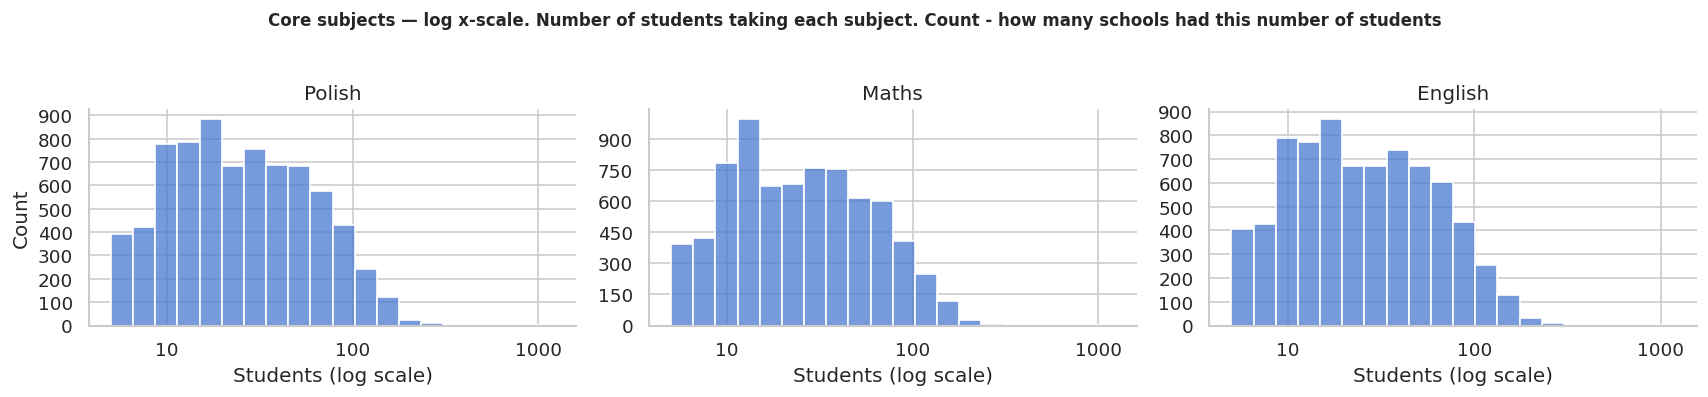

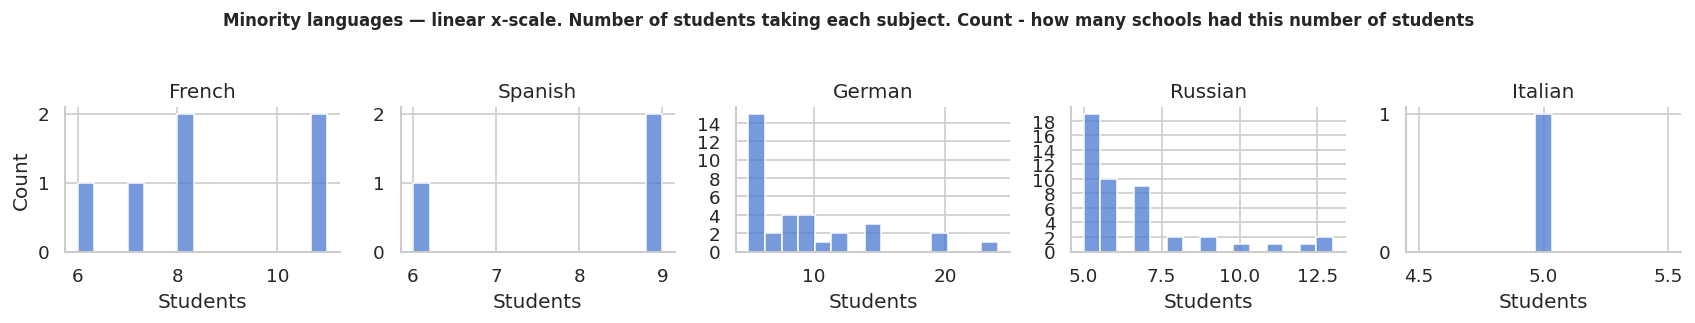


Minority languages — records with valid median data (n ≥ 5):


,School-year records,Median students,Max students
Subject,,,
French,6,8,11
Spanish,3,9,9
German,34,7,24
Russian,47,6,13
Italian,1,5,5


In [7]:
# ── Core subjects: log x-scale | Minority languages: linear x-scale ──────────
long_core = pd.concat([
    df.loc[df[f'median_{s}'].notna(), [f'n_{s}']]
    .rename(columns={f'n_{s}': 'Students'})
    .assign(Language=SUBJECT_LABELS[s])
    for s in CORE_SUBJECTS if f'n_{s}' in df.columns
]).dropna()
long_core['Language'] = pd.Categorical(
    long_core['Language'],
    categories=[SUBJECT_LABELS[s] for s in CORE_SUBJECTS],
    ordered=True,
)

long_min = pd.concat([
    df.loc[df[f'median_{s}'].notna(), [f'n_{s}']]
    .rename(columns={f'n_{s}': 'Students'})
    .assign(Language=SUBJECT_LABELS[s])
    for s in MINORITY_SUBJECTS if f'n_{s}' in df.columns
]).dropna()
long_min['Language'] = pd.Categorical(
    long_min['Language'],
    categories=[SUBJECT_LABELS[s] for s in MINORITY_SUBJECTS if f'n_{s}' in df.columns],
    ordered=True,
)

# Core — log x-scale
g1 = sns.FacetGrid(long_core, col='Language', col_wrap=3,
                   sharex=False, sharey=False, height=3.2, aspect=1.5)
g1.map(sns.histplot, 'Students', bins=20, log_scale=(True, False))
g1.set_titles('{col_name}')
g1.set_axis_labels('Students (log scale)', 'Count')
for ax in g1.axes.flat:
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
g1.figure.suptitle('Core subjects — log x-scale. Number of students taking each subject. Count - how many schools had this number of students', fontsize=10, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

g = sns.FacetGrid(long_min, col='Language', col_wrap=5,
                  sharex=False, sharey=False, height=2.6, aspect=1.1)
g.map(sns.histplot, 'Students', bins=15)
g.set_titles('{col_name}')
g.set_axis_labels('Students', 'Count')
for ax in g.axes.flat:
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
g.figure.suptitle('Minority languages — linear x-scale. Number of students taking each subject. Count - how many schools had this number of students', fontsize=10, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# ── Summary table for minority languages (only records with valid median, i.e. n ≥ 5) ──
rows = []
for subject_code in MINORITY_SUBJECTS:
    col = f'n_{subject_code}'
    if col not in df.columns:
        continue
    s = df.loc[df[f'median_{subject_code}'].notna(), col].dropna()
    if s.empty:
        continue
    rows.append({
        'Subject':             SUBJECT_LABELS[subject_code],
        'School-year records': len(s),
        'Median students':     int(s.median()),
        'Max students':        int(s.max()),
    })
print('\nMinority languages — records with valid median data (n ≥ 5):')
display(pd.DataFrame(rows).set_index('Subject'))

### Distribution of students count per school

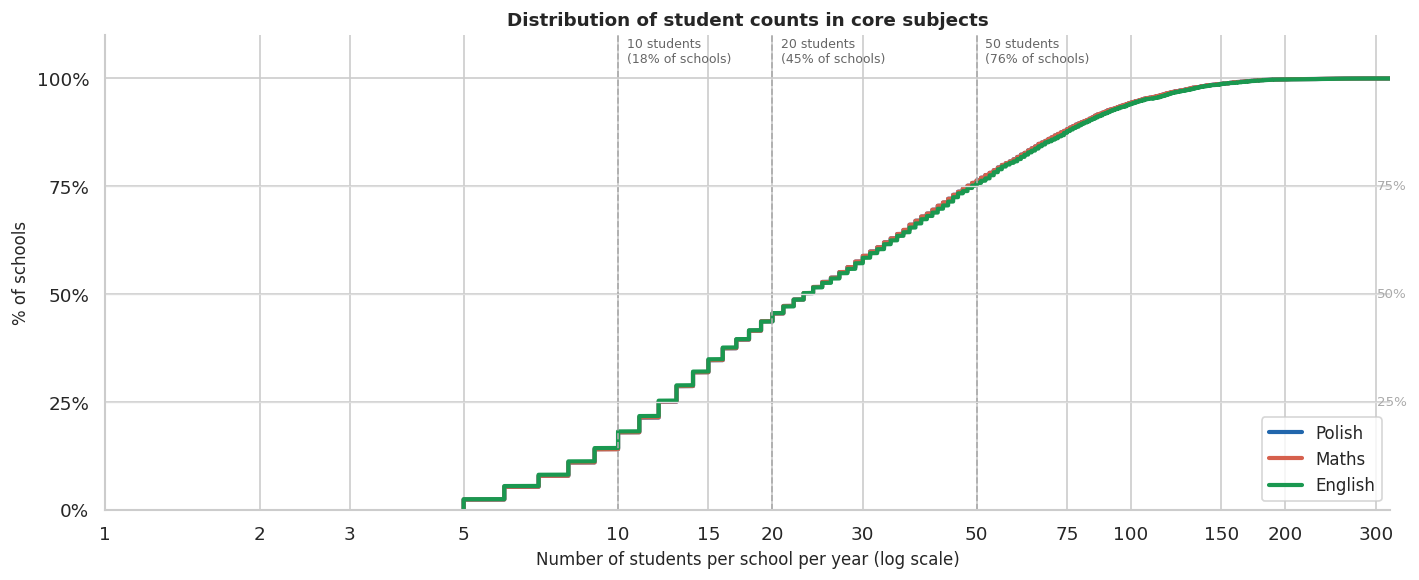

In [8]:
# ── ECDF for the 3 core subjects ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

core_colors = ['#2166ac', '#d6604d', '#1a9850']
for subject_code, color in zip(CORE_SUBJECTS, core_colors):
    col = f'n_{subject_code}'
    if col not in df.columns:
        continue
    x = np.sort(df[col].dropna().values)
    y = np.arange(1, len(x) + 1) / len(x) * 100
    ax.plot(x, y, label=SUBJECT_LABELS[subject_code], color=color, lw=2.5)

# Reference lines — percentages computed from actual n_polski distribution
_n_ref = df['n_polski'].dropna().values
for thresh in [10, 20, 50]:
    pct = ((_n_ref <= thresh).mean() * 100)
    ax.axvline(thresh, color='#aaa', ls='--', lw=1)
    ax.text(thresh * 1.04, 103,
            f'{thresh} students\n({pct:.0f}% of schools)',
            fontsize=7.5, color='#666', va='bottom')

for ref in [25, 50, 75]:
    ax.axhline(ref, color='#ddd', lw=0.8)
    ax.text(302, ref, f'{ref}%', fontsize=8, color='#aaa', va='center', ha='left')

ax.set_xscale('log')
ticks = [1, 2, 3, 5, 10, 15, 20, 30, 50, 75, 100, 150, 200, 300]
ax.set_xticks(ticks)
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax.set_xlim(1, 320)
ax.set_ylim(0, 110)
ax.set_yticks([0, 25, 50, 75, 100])
ax.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
ax.set_xlabel('Number of students per school per year (log scale)', fontsize=10)
ax.set_ylabel('% of schools', fontsize=10)
ax.set_title('Distribution of student counts in core subjects', fontsize=11, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Takeaway:** Almost half of all schools have no more than 20 students sitting any given exam in any given year.
For around one fifth of schools, this number is not more than 10. This matters a lot for how we measure quality (couple good/bad students can strongly affect school results).

## 3. Choosing the best per-year metric

### The problem with raw scores

The exam difficulty changes year to year. In 2021, the voivodeship median for Maths was **46 pp**;
in 2022 it jumped to **60 pp**. A school scoring 55 pp in both years looks stable,
but in 2021 it was 9 pp *above* average and in 2022 it was 5 pp *below* average.
Raw scores alone can't tell us how a school is doing relative to its peers.

Below we show three views of the problem:
1. Year-to-year shifts in the voivodeship-wide distribution (next chart)
2. Why the median of medians jumps more than the mean of means (after that)
3. Within a single school, how much do results swing year to year? (after that)

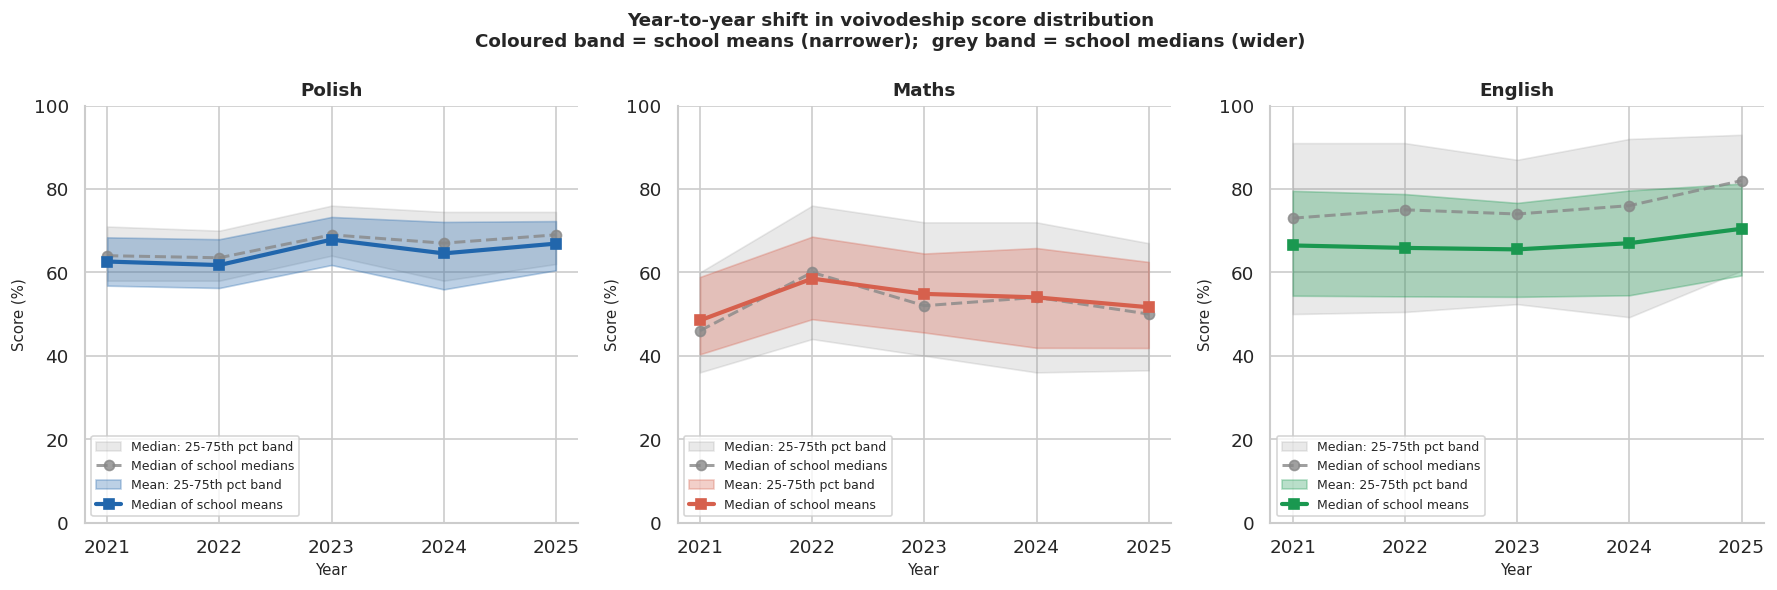

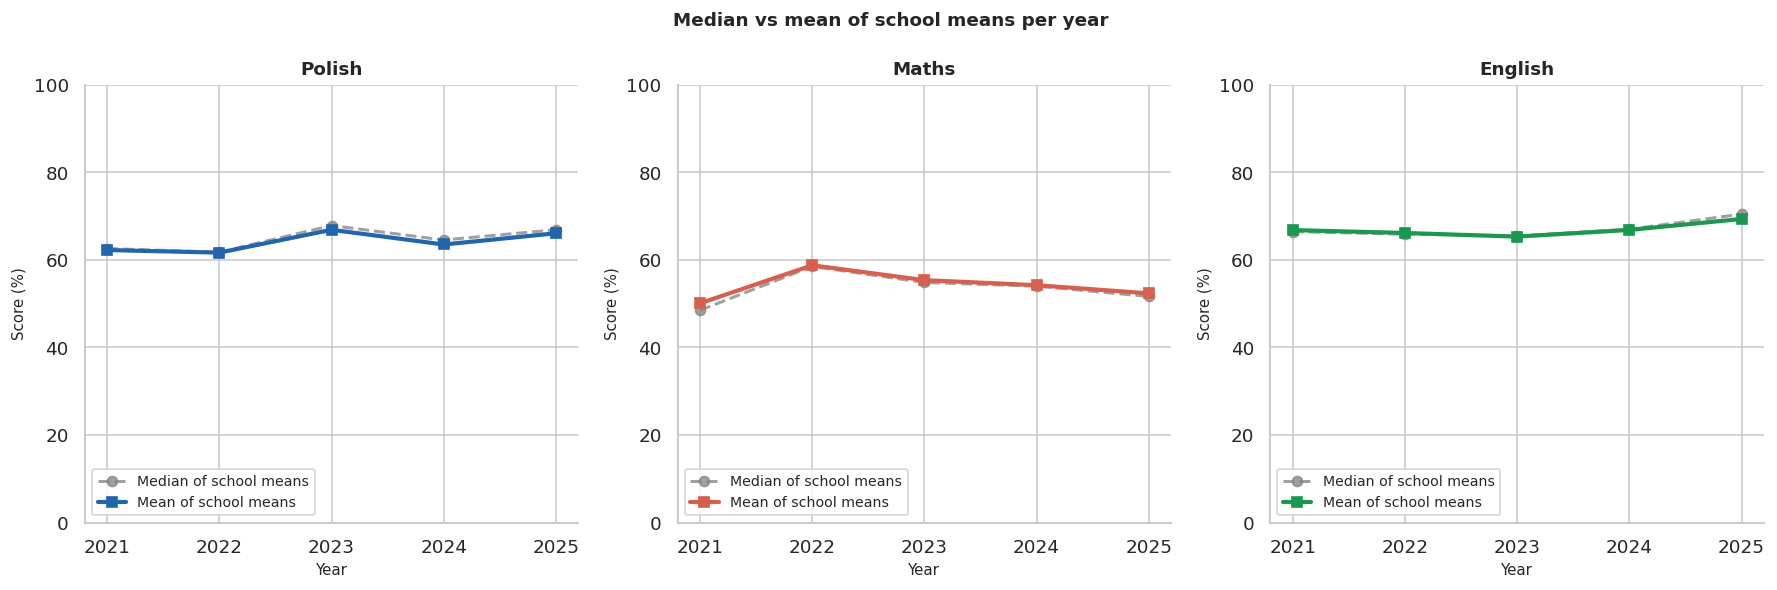

Median of school medians:


,Polish,Maths,English
year,,,
2021,64.0,46.0,73.0
2022,63.5,60.0,75.0
2023,69.0,52.0,74.0
2024,67.0,54.0,76.0
2025,69.0,50.0,82.0



Median of school means:


,Polish,Maths,English
year,,,
2021,62.6,48.5,66.5
2022,61.8,58.5,65.9
2023,67.9,54.8,65.5
2024,64.6,54.0,67.0
2025,66.9,51.6,70.5



Mean of school means:


,Polish,Maths,English
year,,,
2021,62.2,50.1,66.8
2022,61.7,58.8,66.1
2023,66.9,55.4,65.3
2024,63.5,54.2,66.8
2025,66.1,52.3,69.3



Year-to-year range (max - min across 5 years) -- smaller = more stable:


,Polish,Maths,English
Median of mediana range (pp),5.5,14.0,9.0
Mean of means range (pp),5.2,8.7,4.0


In [9]:
# Year-to-year voivodeship distribution: school medians (grey) vs school means (coloured)
years     = sorted(df['year'].unique())
n_years = len(years)
grouped = df.groupby('year')   # group once, reused for every band/table below

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, subject in zip(axes, CORE_SUBJECTS):
    color = SUBJECT_COLORS[subject]

    quantiles_median = grouped[f'median_{subject}'].quantile([0.25, 0.50, 0.75]).unstack()
    quantiles_mean   = grouped[f'mean_{subject}'].quantile([0.25, 0.50, 0.75]).unstack()
    q25_median, q50_median, q75_median = quantiles_median.values.T
    q25_avg,    q50_avg,    q75_avg    = quantiles_mean.values.T

    ax.fill_between(years, q25_median, q75_median, alpha=0.18, color='#888888',
                    label='Median: 25-75th pct band')
    ax.plot(years, q50_median, 'o--', lw=1.8, color='#888888', alpha=0.8,
            label='Median of school medians')
    ax.fill_between(years, q25_avg, q75_avg, alpha=0.30, color=color,
                    label='Mean: 25-75th pct band')
    ax.plot(years, q50_avg, 's-', lw=2.5, color=color,
            label='Median of school means')

    ax.set_title(SUBJECT_LABELS[subject], fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Score (%)', fontsize=9)
    ax.set_xticks(years)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=7.5, loc='lower left')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Year-to-year shift in voivodeship score distribution\n'
    'Coloured band = school means (narrower);  grey band = school medians (wider)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()
# Median of school means vs mean of school means
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, subject in zip(axes, CORE_SUBJECTS):
    color = SUBJECT_COLORS[subject]
    grouped_mean = grouped[f'mean_{subject}']

    q50_avg  = grouped_mean.quantile(0.50).values
    mean_avg = grouped_mean.mean().values

    ax.plot(years, q50_avg, 'o--', lw=1.8, color='#888888', alpha=0.8,
            label='Median of school means')
    ax.plot(years, mean_avg, 's-', lw=2.5, color=color,
            label='Mean of school means')

    ax.set_title(SUBJECT_LABELS[subject], fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Score (%)', fontsize=9)
    ax.set_xticks(years)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=8.5, loc='lower left')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Median vs mean of school means per year', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('Median of school medians:')
voivodeship_median_table = pd.DataFrame({
    SUBJECT_LABELS[s]: grouped[f'median_{s}'].median()
    for s in CORE_SUBJECTS
})
display(voivodeship_median_table.round(1))

print('\nMedian of school means:')
voivodeship_mean_table = pd.DataFrame({
    SUBJECT_LABELS[s]: grouped[f'mean_{s}'].median()
    for s in CORE_SUBJECTS
})
display(voivodeship_mean_table.round(1))

print('\nMean of school means:')
voivodeship_mean_table = pd.DataFrame({
    SUBJECT_LABELS[s]: grouped[f'mean_{s}'].mean()
    for s in CORE_SUBJECTS
})
display(voivodeship_mean_table.round(1))

print(f'\nYear-to-year range (max - min across {n_years} years) -- smaller = more stable:')
median_range = {SUBJECT_LABELS[s]: round(
    grouped[f'median_{s}'].median().max()
    - grouped[f'median_{s}'].median().min(), 1)
    for s in CORE_SUBJECTS}
mean_range = {SUBJECT_LABELS[s]: round(
    grouped[f'mean_{s}'].mean().max()
    - grouped[f'mean_{s}'].mean().min(), 1)
    for s in CORE_SUBJECTS}
display(pd.DataFrame({'Median of mediana range (pp)': median_range,
                      'Mean of means range (pp)':   mean_range}).T)

#### Why does the median jumps more than mean?

1. If we consider only school means as expected when exam is easy (Polish, English) typically bad students push the mean down so mean is below median.
With hard subjects like Math situation is opposite - middle student has lower score so good students push mean higher than median.
We also see that in years were Math exam got easier the difference decreased.
2. But why median which in some settings is more stable than mean, here jumps way more?

**Why does the voivodeship median of medians in Maths jumps 14 pp while the voivodeship median of means moves only 10 pp?**

For Maths between 2021 and 2022, the voivodeship median of medians jumped from 46 to 60 (14 pp),
while the voivodeship median of means moved only from 48.5 to 58.5 (10 pp). What explains this 4 pp gap?

It's not random noise, and it's not just quantization (school medians come in 2 pp steps,
which can explain at most 1-2 pp of the jump). The real explanation requires looking
at how *individual* schools moved between the two years.

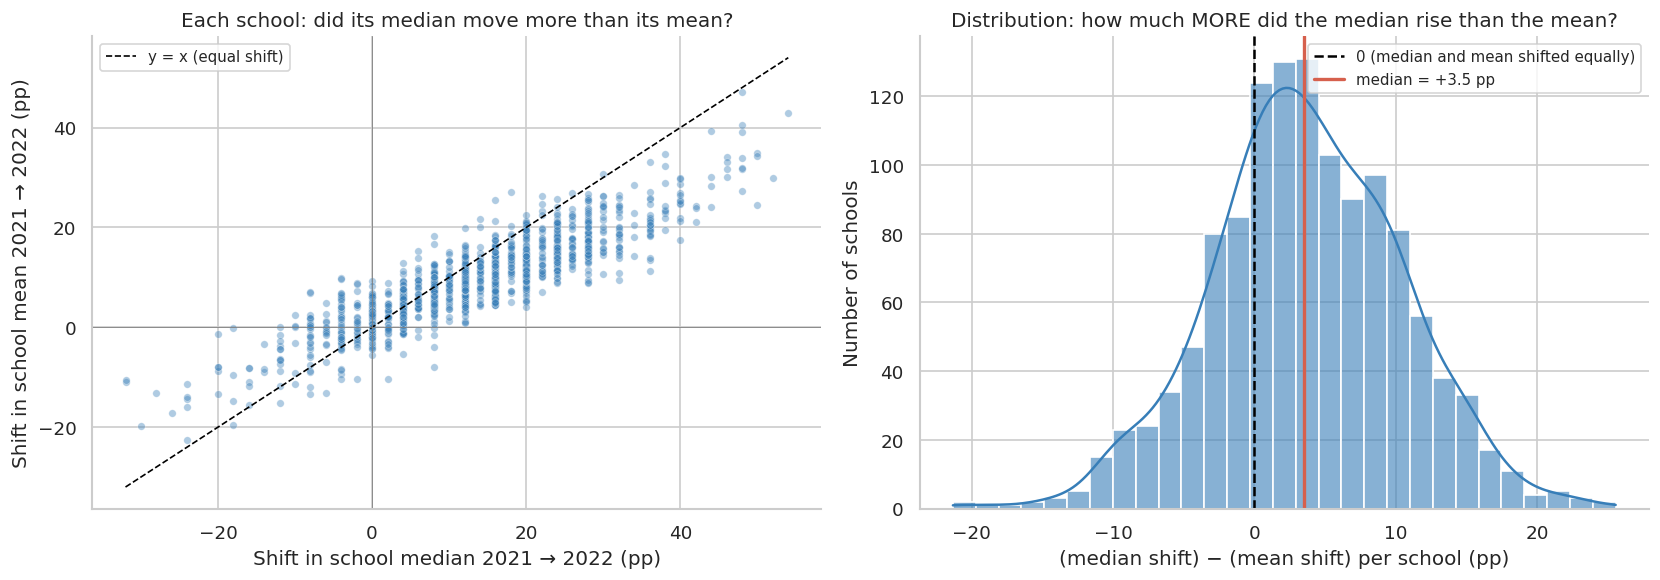

Schools tracked across 2021→2022: 1,247
Median shift in school medians: +14.0 pp
Median shift in school means:   +10.0 pp
Median of (median_shift − mean_shift): +3.5 pp
% schools where median rose more than mean: 71%


In [10]:
# Track the SAME schools across 2021 and 2022 — how much did each shift?
sub_2021 = df[df['year'] == 2021].set_index('rspo')
sub_2022 = df[df['year'] == 2022].set_index('rspo')
common = sub_2021.index.intersection(sub_2022.index)

median_shift = sub_2022.loc[common, 'median_matematyka'] - sub_2021.loc[common, 'median_matematyka']
shift_avg = sub_2022.loc[common, 'mean_matematyka']   - sub_2021.loc[common, 'mean_matematyka']
shift_math_df = pd.DataFrame({'median_shift': median_shift, 'shift_avg': shift_avg})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Scatter: shift in median vs shift in mean ---
ax = axes[0]
sns.scatterplot(data=shift_math_df, x='median_shift', y='shift_avg',
                ax=ax, alpha=0.4, s=20, color='#377eb8')

# Reference line y = x (where median and mean shifts would be equal)
x_min = min(shift_math_df.min().min(), -5)
x_max = max(shift_math_df.max().max(), 5)
ax.plot([x_min, x_max], [x_min, x_max], color='black', ls='--', lw=1,
        label='y = x (equal shift)')

ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('Shift in school median 2021 → 2022 (pp)')
ax.set_ylabel('Shift in school mean 2021 → 2022 (pp)')
ax.set_title('Each school: did its median move more than its mean?')
ax.legend(loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# Most points sit BELOW the y=x line → median rose more than the mean

# --- Histogram: median shift minus mean shift ---
ax = axes[1]
diff = median_shift - shift_avg
sns.histplot(diff, kde=True, ax=ax, color='#377eb8', alpha=0.6)
ax.axvline(0, color='black', ls='--', lw=1.5,
           label='0 (median and mean shifted equally)')
ax.axvline(diff.median(), color='#d6604d', lw=2,
           label=f'median = {diff.median():+.1f} pp')
ax.set_xlabel('(median shift) − (mean shift) per school (pp)')
ax.set_ylabel('Number of schools')
ax.set_title('Distribution: how much MORE did the median rise than the mean?')
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Numeric summary
print(f'Schools tracked across 2021→2022: {len(common):,}')
print(f'Median shift in school medians: {median_shift.median():+.1f} pp')
print(f'Median shift in school means:   {shift_avg.median():+.1f} pp')
print(f'Median of (median_shift − mean_shift): {(median_shift - shift_avg).median():+.1f} pp')
print(f'% schools where median rose more than mean: {((median_shift - shift_avg) > 0).mean()*100:.0f}%')

#### How did individual schools move 2021 → 2022?

**Left:** Each dot is one school. The X-axis is how much that school's median moved
between 2021 and 2022. The Y-axis is how much its mean moved. If both metrics
captured the same thing, dots would sit on the dashed y = x line.

The dots sit consistently *below* the line — meaning for almost every school, the
median rose **more** than the mean. The exam got easier, but the median student
benefited more than the average student.

**Right:** The same fact shown as a distribution. We plot (median shift) − (mean shift)
for each school. If this difference were near zero, the two metrics would behave
similarly. Instead the distribution is clearly shifted to the right of zero —
the median rose about 4 pp more than the mean for the typical school.

**Why does this happen?**

The mean averages over the whole class, including students at both extremes.
When the exam got easier, the strong students were already near 90–100% — they
couldn't gain as much (ceiling effect). The mean reflects this dampening.

The median is the score of the *middle* student. When the difficulty shifts,
this middle student's score moves by the full amount of the shift, because they
weren't pressed against the ceiling. So the median captures the shift in full,
the mean captures it after ceiling/floor effects dampen the extremes.

**Implication for the metric:**

The voivodeship mean is a more *linear* function of exam difficulty than the
voivodeship median — it absorbs ceiling and floor effects proportionally.
Subtracting the voivodeship mean from each school's mean (`diff_mean`) gives a
cleaner residual signal about that school's performance, relative to the
voivodeship in that year. Subtracting the voivodeship median (`diff_median`) leaves
residuals contaminated by the non-linear response of the median to difficulty
shifts. This is one more reason `diff_mean` beats `diff_median` in LOO stability.

#### How much does a single school swing year to year?

So far we looked at the voivodeship-wide distribution. Now: when we follow a
single school through 3+ years, how much does its result move?
And does the median or mean swing more *within a single school*?

This matters because it sets a floor on how precise our ranking can be: if a typical
school's median moves by 24 pp year to year, then a 5 pp difference between two
schools is comfortably within the noise.

Within-school year-to-year range of mean score (pp), schools with >= 3 years:
voi_range = voivodeship-wide year-to-year range (baseline).



,voi_range (pp),P25 (pp),P50 (pp),P75 (pp),P90 (pp),P95 (pp)
subject,,,,,,
Polish,5.2,9.1,12.9,18.1,23.5,26.1
Maths,8.7,11.9,16.3,22.4,29.3,34.1
English,4.0,8.4,13.2,19.7,27.7,33.0


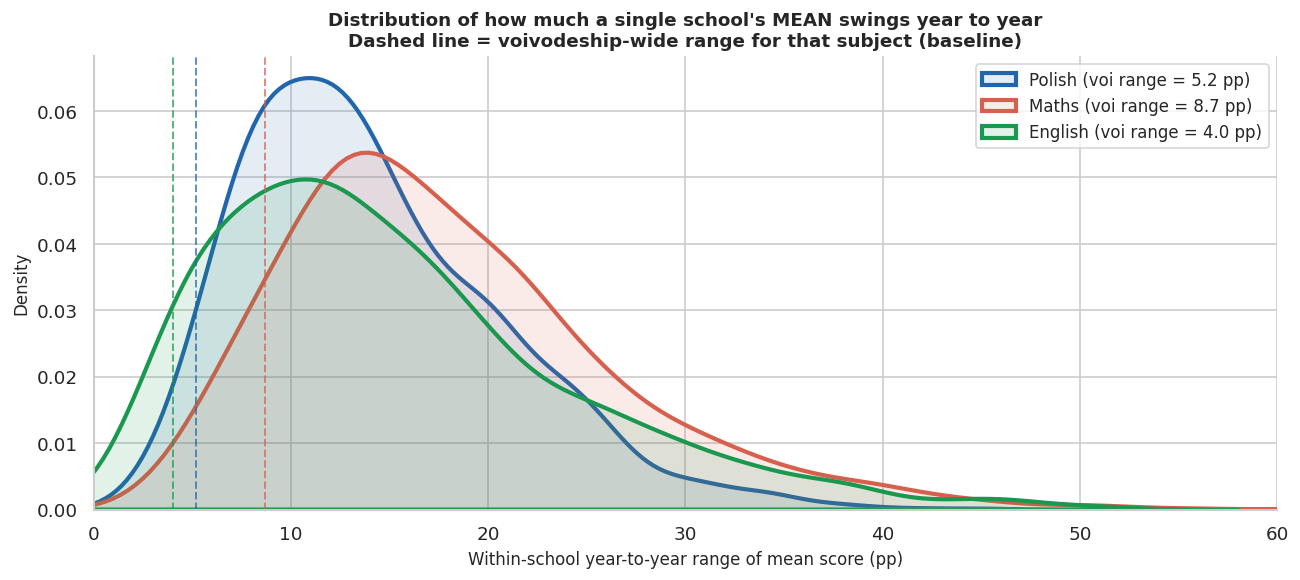

In [11]:
# ── Within-school year-to-year variation of the school mean ──────────────────
# Schools with >= 3 years of data give meaningful range/std.
# We focus on the mean since diff_mean / unit_norm_diff_mean won the LOO test.
year_count_for_swing = df.groupby('rspo')['year'].nunique()
df_swing = df[df['rspo'].isin(year_count_for_swing[year_count_for_swing >= 3].index)].copy()

# Per-school range (max - min) of mean score across the school's years
swing_records = []
for subject in CORE_SUBJECTS:
    mean_range = df_swing.groupby('rspo')[f'mean_{subject}'].agg(lambda x: x.max() - x.min())
    voi_avg_range = (df.groupby('year')[f'mean_{subject}'].mean().max()
                     - df.groupby('year')[f'mean_{subject}'].mean().min())
    row = {
        'subject':         SUBJECT_LABELS[subject],
        'voi_range (pp)':  round(voi_avg_range, 1),
    }
    for pct in [25, 50, 75, 90, 95]:
        row[f'P{pct} (pp)'] = round(np.percentile(mean_range.dropna(), pct), 1)
    swing_records.append(row)

swing_df = pd.DataFrame(swing_records).set_index('subject')
print("Within-school year-to-year range of mean score (pp), schools with >= 3 years:")
print("voi_range = voivodeship-wide year-to-year range (baseline).\n")
display(swing_df)

# ── Distribution of within-school mean range, per subject ───────────────────
# How wide is the band of mean-score swings for each subject?
fig, ax = plt.subplots(figsize=(11, 5))

for subject in CORE_SUBJECTS:
    rng = df_swing.groupby('rspo')[f'mean_{subject}'].agg(lambda x: x.max() - x.min()).dropna()
    voi_range = (df.groupby('year')[f'mean_{subject}'].mean().max()
                 - df.groupby('year')[f'mean_{subject}'].mean().min())

    sns.kdeplot(rng, ax=ax, color=SUBJECT_COLORS[subject], lw=2.5,
                label=f'{SUBJECT_LABELS[subject]} (voi range = {voi_range:.1f} pp)',
                fill=True, alpha=0.12)

    # Mark the voivodeship-wide range as a vertical line in matching colour
    ax.axvline(voi_range, color=SUBJECT_COLORS[subject], lw=1.2, ls='--', alpha=0.7)

ax.set_xlabel('Within-school year-to-year range of mean score (pp)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title(
    'Distribution of how much a single school\'s MEAN swings year to year\n'
    'Dashed line = voivodeship-wide range for that subject (baseline)',
    fontsize=11, fontweight='bold')
ax.set_xlim(0, 60)
ax.legend(fontsize=10, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**What the table shows:**

- **Single schools swing 1.7–2.6x more than the voivodeship-wide trend.** For the median
  school in Maths, results move 24 pp year to year, while the voivodeship-wide median
  moves 14 pp. Schools are individually noisier than the trend.
- **Maths has the smallest school/voivodeship ratio (1.7x at P50)**, despite the largest
  voivodeship swing (14 pp). This means much of the Maths year-to-year movement
  is "everybody shifted together" (driven by exam difficulty), not individual school
  variation. After we normalise by the voivodeship reference, Maths becomes much cleaner.
- **Polish and English ratios are 2.3-2.6x at P50 and reach 5.6-5.9x at P95.** Schools
  in these subjects are much more individually noisy than the voivodeship-wide trend.
- **Median swings more than mean inside each school.** For Maths the typical school
  median range is 24 pp vs 16 pp for the mean (47% wider); for English 21 vs 13 pp
  (59% wider). This is the same effect we saw in the 2021→2022 example — the median
  responds more aggressively to year-to-year changes in difficulty and cohort.

**Concrete example.** A "median" school in Maths has its full-data score somewhere
around the 50th percentile of the ranking — let's say its multi-year mean score is 52 pp.
With a year-to-year range of 24 pp, its best year might show 64 pp (~ 80th percentile)
and its worst year might show 40 pp (~ 20th percentile). The school's "true" position
in the ranking is anywhere across a 60-percentile-wide band depending on which year
you happen to look at.

**Implication:** We need a metric that *normalises by year* to subtract off most of
this voivodeship-wide noise, and we need to *aggregate across multiple years* to reduce
the within-school cohort noise. A single-year ranking will be dominated by luck.

**Real schools — examples of year-to-year swings**

To make the numbers concrete, let's pick a few real schools from the dataset
and look at how their mean score moved year by year. We sample across the
range of swing magnitudes — calm schools, typical schools, and very volatile ones.

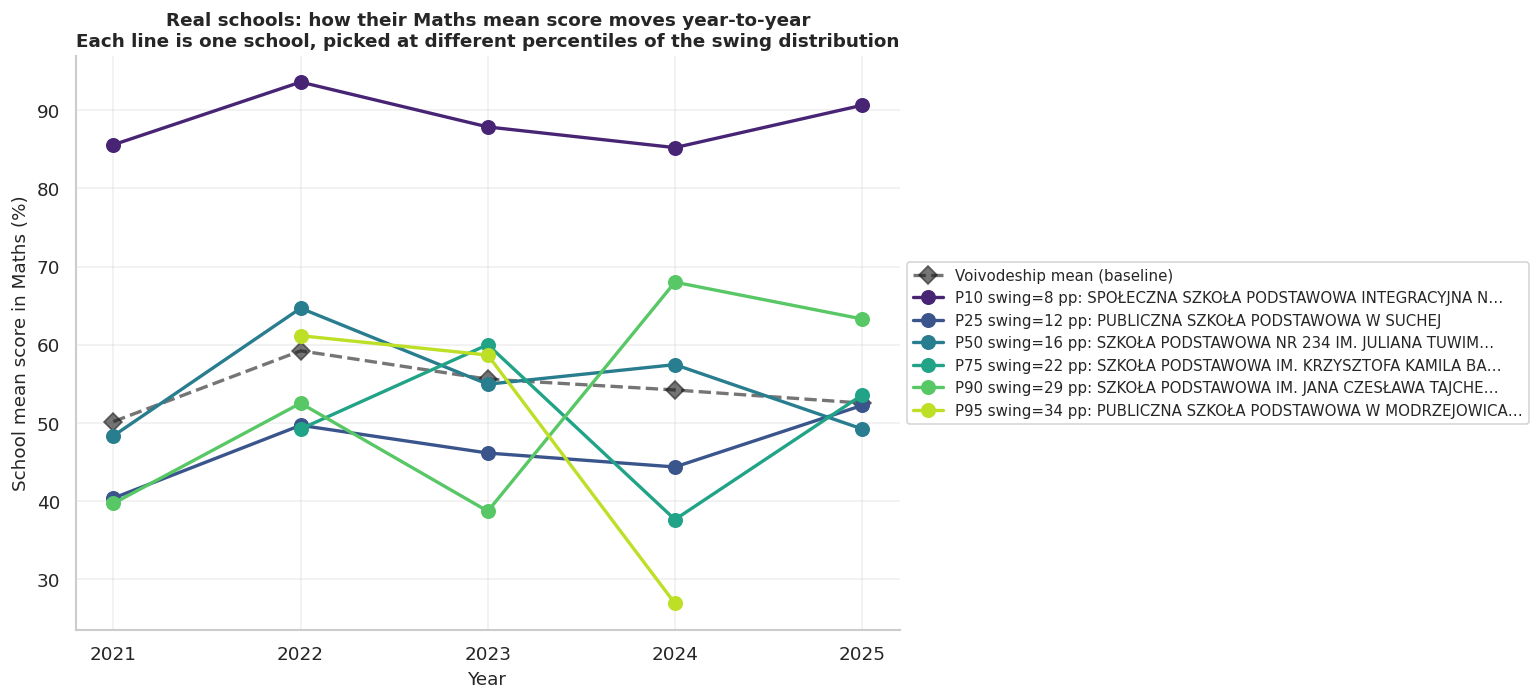


Table of the picked schools:


,school_name,n_years,min_mean,max_mean,swing (pp),mean_n_students
percentile,,,,,,
P10,SPOŁECZNA SZKOŁA PODSTAWOWA INTEGRACYJNA NR 10...,5,85.2,93.6,8.4,25.8
P25,PUBLICZNA SZKOŁA PODSTAWOWA W SUCHEJ,5,40.3,52.2,11.9,20.4
P50,SZKOŁA PODSTAWOWA NR 234 IM. JULIANA TUWIMA,5,48.3,64.7,16.3,47.4
P75,SZKOŁA PODSTAWOWA IM. KRZYSZTOFA KAMILA BACZYŃ...,4,37.6,60.0,22.4,8.2
P90,SZKOŁA PODSTAWOWA IM. JANA CZESŁAWA TAJCHERTA ...,5,38.7,68.0,29.3,10.2
P95,PUBLICZNA SZKOŁA PODSTAWOWA W MODRZEJOWICACH,3,26.9,61.1,34.3,6.7


In [12]:
# ── Concrete examples: real schools with various swing magnitudes ────────────
# Compute swing per school (Maths)
SUBJ_FOR_EXAMPLES = 'matematyka'
rng_per_school = (
    df_swing.groupby('rspo')[f'mean_{SUBJ_FOR_EXAMPLES}']
    .agg(lambda x: x.max() - x.min())
    .dropna()
    .sort_values()
)

n_total = len(rng_per_school)

# Pick representative schools at given percentile positions
pick_pcts = [10, 25, 50, 75, 90, 95]
picks = []
for p in pick_pcts:
    idx_pos = int(n_total * p / 100)
    rspo = rng_per_school.index[idx_pos]
    picks.append((p, rspo, rng_per_school.iloc[idx_pos]))

# Plot each school's mean trajectory across years
fig, ax = plt.subplots(figsize=(13, 6))

years_all = sorted(df_swing['year'].unique())
voi_mean_per_year = df_swing.groupby('year')[f'mean_{SUBJ_FOR_EXAMPLES}'].mean()
ax.plot(years_all, voi_mean_per_year.values, 'k--', lw=2,
        marker='D', markersize=8, label='Voivodeship mean (baseline)', alpha=0.6)

cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(picks)))
for (pct, rspo, swing), color in zip(picks, cmap):
    school_data = df_swing[df_swing['rspo'] == rspo].sort_values('year')
    name = school_data['school_name'].iloc[0]
    # Truncate long names
    name_short = name[:42] + '…' if len(name) > 42 else name
    ax.plot(school_data['year'], school_data[f'mean_{SUBJ_FOR_EXAMPLES}'],
            marker='o', lw=2, color=color, markersize=8,
            label=f'P{pct} swing={swing:.0f} pp: {name_short}')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel(f'School mean score in {SUBJECT_LABELS[SUBJ_FOR_EXAMPLES]} (%)', fontsize=11)
ax.set_title(
    f'Real schools: how their {SUBJECT_LABELS[SUBJ_FOR_EXAMPLES]} mean score moves year-to-year\n'
    f'Each line is one school, picked at different percentiles of the swing distribution',
    fontsize=11, fontweight='bold')
ax.set_xticks(years_all)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Table summary
print('\nTable of the picked schools:')
rows = []
for pct, rspo, swing in picks:
    school_data = df_swing[df_swing['rspo'] == rspo].sort_values('year')
    rows.append({
        'percentile': f'P{pct}',
        'school_name': school_data['school_name'].iloc[0],
        'n_years': len(school_data),
        'min_mean': round(school_data[f'mean_{SUBJ_FOR_EXAMPLES}'].min(), 1),
        'max_mean': round(school_data[f'mean_{SUBJ_FOR_EXAMPLES}'].max(), 1),
        'swing (pp)': round(swing, 1),
        'mean_n_students': round(school_data[f'n_{SUBJ_FOR_EXAMPLES}'].mean(), 1),
    })
display(pd.DataFrame(rows).set_index('percentile'))

### Picking the best metric — LOO stability test

We now have to choose *which* per-year metric to use as our normalised score,
**and how to aggregate it across years**. We treat both as one joint decision
because they are tested together in the same LOO experiment.

### Per-year metric candidates

For each school in each year we can compute:

| Metric | Description |
|--------|-------------|
| `mean` | Average student score |
| `median` | Middle student's score (less sensitive to outliers) |
| `diff_mean` | School mean − voivodeship mean for that year |
| `diff_median` | School median − voivodeship median for that year |
| `unit_norm_diff_mean` | `diff_mean` divided by the distance to the ceiling (if positive) or floor (if negative). Result in [−1, +1] |
| `unit_norm_diff_median` | Same logic using `diff_median` |
| `pct_mean` | Percentile rank of the school mean in that year (across all schools) |
| `pct_median` | Percentile rank of the school median in that year |

### Aggregation method candidates

Once we have a per-year value per school, we need to collapse N years into
one number per school. The candidates:

| Aggregation | Description |
|-------------|-------------|
| `mean` (equal weight) | Arithmetic mean across years; each year counts the same regardless of cohort size |
| `mean_weighted_by_students_count` | Weighted mean, weight = `n_students` per year. A year with 50 students counts 10× as much as a year with 5 |
| `mean_weighted_by_students_count_sqrt` | Same idea but weight = `√n_students`. Smaller penalty for small years |
| `median` (of years) | Middle year's value, ignores cohort sizes |
| `trimmed_mean` | Drop the best and worst year, mean of the rest |

### How we choose

We use **jackknife (leave-one-out) stability**: for a school with N years of data,
we compute the score N times, each time leaving out one year. The more the result
changes, the less stable the metric — and a less stable metric means the score is
driven by luck (which year happened to be included) rather than real school quality.

We want the metric where the N estimates are *closest together* — measured by the
**LOO standard deviation**, normalised by the metric's overall spread across all
schools, so that metrics on different scales can be compared. Each combination
of (per-year metric × aggregation method) gets its own LOO std — 8 × 5 = 40
combinations per subject.

### Compute metrics per year

In [13]:
# Compute voivodeship median per year per subject (used for diff_median)
voivodeship_median = {}
for subject_code in CORE_SUBJECTS:
    voivodeship_median[subject_code] = df.groupby('year')[f'median_{subject_code}'].median()
    df[f'voivodeship_median_{subject_code}'] = df['year'].map(voivodeship_median[subject_code])
    df[f'diff_median_{subject_code}'] = df[f'median_{subject_code}'] - df[f'voivodeship_median_{subject_code}']

# Compute percentile ranks within each year for mean and median
for subject_code in CORE_SUBJECTS:
    for metric in ['median', 'mean']:
        input_column  = f'{metric}_{subject_code}'
        output_column = f'pct_{metric}_{subject_code}'
        df[output_column] = df.groupby('year')[input_column].transform(
            lambda x: stats.rankdata(x.fillna(x.median()), method='average') / len(x) * 100
        )

# ── Compute additional candidate metrics: diff_mean, unit_norm_diff_mean, unit_norm_diff_median ─
voivodeship_mean = {}
for subject in CORE_SUBJECTS:
    voivodeship_mean[subject] = df.groupby('year')[f'mean_{subject}'].mean()
    df[f'voivodeship_mean_{subject}'] = df['year'].map(voivodeship_mean[subject])
    df[f'diff_mean_{subject}'] = df[f'mean_{subject}'] - df[f'voivodeship_mean_{subject}']

    # unit_norm_diff: signed normalisation to [-1, +1] using ceiling/floor distance
    # unit_norm_diff_mean uses mean-based diff and voivodeship mean as reference
    d_avg = df[f'diff_mean_{subject}']
    v_avg = df[f'voivodeship_mean_{subject}']
    df[f'unit_norm_diff_mean_{subject}'] = np.where(
        d_avg >= 0,
        d_avg / (100 - v_avg).where(100 - v_avg > 0, 1),
        d_avg / v_avg.where(v_avg > 0, 1),
    )

    # unit_norm_diff_median uses median-based diff and voivodeship median as reference
    median_diffs = df[f'diff_median_{subject}']
    median_values = df[f'voivodeship_median_{subject}']
    df[f'unit_norm_diff_median_{subject}'] = np.where(
        median_diffs >= 0,
        median_diffs / (100 - median_values).where(100 - median_values > 0, 1),
        median_diffs / median_values.where(median_values > 0, 1),
    )

print('Candidate metrics computed for each (school, year, subject) row:')
print('  diff_median, diff_mean, pct_mean, pct_median, unit_norm_diff_mean, unit_norm_diff_median')
print('(mean, median already exist from earlier cells)')

Candidate metrics computed for each (school, year, subject) row:
  diff_median, diff_mean, pct_mean, pct_median, unit_norm_diff_mean, unit_norm_diff_median
(mean, median already exist from earlier cells)


### Compute scores for all folds (leave one out, single year, all years)

In [14]:
# ── LOO fold scores DataFrame ─────────────────────────────────────────────────
# One row per (rspo, year_subset, aggregation_method).
#
# year_subset: sorted tuple of years included in the fold.
# all_school_years_used: True when year_subset equals all years the school has data in.
#
# Four fold types generated per school:
#   full     — all years available for the school
#   loo_all  — leave-one-out over all N dataset years (schools with data in all N years only)
#   loo_2022 — leave-one-out over years ≥ 2022 (schools with complete data from 2022 onward)
#   single   — one fold per individual year the school has data
#
# Aggregation methods applied across per-year metric values within each fold:
#   mean                                 — arithmetic mean (equal weight per year)
#   mean_weighted_by_students_count      — weighted mean, weight = n_students per year
#   mean_weighted_by_students_count_sqrt — weighted mean, weight = sqrt(n_students)
#   median                               — median of per-year values
#   trimmed_mean                         — drop the single best and worst year, mean of the rest;
#                                          n=1 → raw value; n=2 → arithmetic mean
#
# n_{subject} columns: median of per-year student counts across years in the fold.
# Median is used (not mean) so a single outlier year does not distort the size summary.

CANDIDATE_METRICS = {
    'mean':               lambda s: f'mean_{s}',
    'median':             lambda s: f'median_{s}',
    'diff_mean':          lambda s: f'diff_mean_{s}',
    'diff_median':        lambda s: f'diff_median_{s}',
    'unit_norm_diff_mean':   lambda s: f'unit_norm_diff_mean_{s}',
    'unit_norm_diff_median': lambda s: f'unit_norm_diff_median_{s}',
    'pct_mean':           lambda s: f'pct_mean_{s}',
    'pct_median':         lambda s: f'pct_median_{s}',
}


ALL_YEARS  = sorted(df['year'].unique())
YEARS_2022 = [y for y in ALL_YEARS if y >= 2022]
N_YEARS    = len(ALL_YEARS)

rspo_all_years = {
    rspo for rspo, grp in df.groupby('rspo')
    if set(grp['year'].unique()) == set(ALL_YEARS)
}
rspo_from_2022 = {
    rspo for rspo, grp in df.groupby('rspo')
    if set(YEARS_2022).issubset(set(grp['year'].unique()))
}

print(f'Dataset years: {ALL_YEARS}')
print(f'Schools with all {N_YEARS} years:              {len(rspo_all_years):,}')
print(f'Schools with all years from 2022 ({len(YEARS_2022)} yrs): {len(rspo_from_2022):,}')

AGG_METHODS = [
    'mean',
    'mean_weighted_by_students_count',
    'mean_weighted_by_students_count_sqrt',
    'median',
    'trimmed_mean',
]


class NanPropagationMasks(NamedTuple):
    """Per (fold, column) flags reproducing the NaN rule from _aggregate."""
    metric_has_any_nan: pd.DataFrame
    students_count_has_any_nan: pd.DataFrame
    students_count_sums: pd.DataFrame
    students_count_sum_is_zero: pd.DataFrame


LEADING_COLUMNS = ['rspo', 'years', 'aggregation_method', 'all_school_years_used']


# The helpers below are prefixed with _ to mark them as private sub-steps of the
# single public entry point compute_loo_folds_df_fast() — none is called elsewhere.
# They are free functions, not methods of a class: each is a stateless transform
# (data in, data out) with no shared state for a class to hold; the orchestrator
# threads the intermediate frames explicitly.
# ── 1. Fold specifications ─────────────────────────────────────────────────
def _build_fold_specifications(
    source_df: pd.DataFrame,
    rspo_all_years: set,
    rspo_from_2022: set,
    all_years: tuple,
    years_2022: tuple,
) -> pd.DataFrame:
    """
    Build the list of folds to compute.

    Returns a DataFrame with columns:
    - rspo:                  school identifier
    - years:                 tuple of years belonging to the fold
    - all_school_years_used: whether the fold covers all of the school's years
    - fold_id:               unique int per (rspo, years), assigned sequentially.
                             Used later as the groupby key — faster than
                             (rspo, years), because a tuple groupby key is
                             slow.

    One row per (school, year subset). Contains:
    - the full fold (all years the school has data for),
    - LOO over ALL_YEARS  (only for schools in rspo_all_years),
    - LOO over YEARS_2022 (only for schools in rspo_from_2022),
    - single-year folds for each year the school has.
    """
    school_years_map = (
        source_df.groupby('rspo')['year']
                 .apply(lambda values: tuple(sorted(values.unique())))
                 .to_dict()
    )

    loo_all_years_folds = [
        tuple(year for year in all_years if year != excluded_year)
        for excluded_year in all_years
    ]
    loo_from_2022_folds = [
        tuple(year for year in years_2022 if year != excluded_year)
        for excluded_year in years_2022
    ]

    fold_records = []
    for rspo, school_years in school_years_map.items():
        school_years_set = set(school_years)
        seen_folds = {school_years}
        fold_records.append((rspo, school_years, True))  # full fold

        candidate_folds: list[tuple] = []
        if rspo in rspo_all_years:
            candidate_folds.extend(loo_all_years_folds)
        if rspo in rspo_from_2022:
            candidate_folds.extend(loo_from_2022_folds)
        candidate_folds.extend((year,) for year in school_years)

        for fold in candidate_folds:
            if fold not in seen_folds:
                seen_folds.add(fold)
                all_school_years_used = set(fold) == school_years_set
                fold_records.append((rspo, fold, all_school_years_used))

    fold_specifications = pd.DataFrame(
        fold_records, columns=['rspo', 'years', 'all_school_years_used']
    )
    fold_specifications['fold_id'] = np.arange(len(fold_specifications), dtype=np.int64)
    return fold_specifications


# ── 2. Explode to long format + join with df ───────────────────────────────
def _explode_folds_to_long_format(
    fold_specifications: pd.DataFrame,
    source_df: pd.DataFrame,
    metric_columns: list[str],
    students_count_columns: list[str],
) -> pd.DataFrame:
    """
    Expand each fold into N rows (one per year) and join the data from df.

    Input:             one row per fold, column 'years' = tuple of years.
    Output (long):     one row per (fold_id, year), enriched with the metrics
                       and student counts from source_df for that (rspo, year).

    Example: fold (rspo=123, years=(2021, 2022, 2023)) → 3 rows, each
    with a different year and that year's metrics. This then allows a
    groupby('fold_id') to compute the aggregates vectorised.
    """
    folds_long = (
        fold_specifications[['fold_id', 'rspo', 'years']]
            .explode('years', ignore_index=True)
            .rename(columns={'years': 'year'})
    )
    folds_long['year'] = folds_long['year'].astype(source_df['year'].dtype)

    merged = folds_long.merge(
        source_df[['rspo', 'year'] + metric_columns + students_count_columns],
        on=['rspo', 'year'],
        how='left',
    )
    assert len(merged) == len(folds_long), (
        f'Merge changed the row count: {len(folds_long)} → {len(merged)} '
        f'(probably missing (rspo, year) in df).'
    )
    return merged


# ── 3. NaN masks ───────────────────────────────────────────────────────────
def _compute_nan_propagation_masks(
    merged_long: pd.DataFrame,
    fold_grouper: pd.Series,
    metric_columns: list[str],
    students_count_columns: list[str],
) -> NanPropagationMasks:
    """
    Compute the flags reproducing the NaN rule from _aggregate.

    Parameters:
    - merged_long:   DataFrame from _explode_folds_to_long_format — one row
                     per (fold_id, year), with metrics and n_subject from source_df.
    - fold_grouper:  Series of fold_id (= merged_long['fold_id']) used as the
                     grouping key. Extracted once so the column lookup is not
                     repeated on every groupby.

    Why this is needed:
    pandas groupby().mean()/sum()/median() SKIPS NaNs by default,
    while _aggregate propagates them (returns NaN when any input is NaN
    or when n.sum() == 0). These masks repair that mismatch via
    _apply_nan_propagation_mask after the aggregates are computed.

    Returns four DataFrames indexed by fold_id, each with columns
    matching metric_columns or students_count_columns.
    """
    metric_has_any_nan = (
        merged_long[metric_columns].isna().groupby(fold_grouper).any()
    )
    students_count_has_any_nan = (
        merged_long[students_count_columns].isna().groupby(fold_grouper).any()
    )
    students_count_sums = (
        merged_long[students_count_columns]
            .groupby(fold_grouper)
            .sum(min_count=1)
    )
    students_count_sum_is_zero = (students_count_sums == 0)

    return NanPropagationMasks(
        metric_has_any_nan=metric_has_any_nan,
        students_count_has_any_nan=students_count_has_any_nan,
        students_count_sums=students_count_sums,
        students_count_sum_is_zero=students_count_sum_is_zero,
    )


# ── 4. Median number of students ───────────────────────────────────────────
def _compute_median_students_per_fold(
    merged_long: pd.DataFrame,
    fold_grouper: pd.Series,
    students_count_columns: list[str],
    students_count_has_any_nan: pd.DataFrame,
) -> pd.DataFrame:
    """
    Median of n_subject within a fold, with np.median semantics:
    any NaN in the input → NaN. pandas skips NaN by default, so we
    apply the mask manually after computing the median.
    """
    median_students = (
        merged_long[students_count_columns].groupby(fold_grouper).median()
    )
    for column in students_count_columns:
        median_students.loc[students_count_has_any_nan[column], column] = np.nan
    return median_students


# ── 5. Five aggregation methods ────────────────────────────────────────────
def _aggregate_arithmetic_mean(
    merged_long: pd.DataFrame,
    fold_grouper: pd.Series,
    metric_columns: list[str],
) -> pd.DataFrame:
    """Plain arithmetic mean of the metrics per fold."""
    return merged_long[metric_columns].groupby(fold_grouper).mean()


def _aggregate_arithmetic_median(
    merged_long: pd.DataFrame,
    fold_grouper: pd.Series,
    metric_columns: list[str],
) -> pd.DataFrame:
    """Median of the metrics per fold."""
    return merged_long[metric_columns].groupby(fold_grouper).median()


def _aggregate_trimmed_mean(
    merged_long: pd.DataFrame,
    fold_grouper: pd.Series,
    metric_columns: list[str],
) -> pd.DataFrame:
    """
    For n ≥ 3: mean after dropping min and max → (sum - min - max) / (count - 2).
    For n ∈ {1, 2}: plain mean (matching _aggregate).
    """
    grouped = merged_long[metric_columns].groupby(fold_grouper)
    metric_sums = grouped.sum(min_count=1)
    metric_counts = grouped.count()
    metric_minimums = grouped.min()
    metric_maximums = grouped.max()

    counts_as_float = metric_counts.astype(float)
    trimmed = (metric_sums - metric_minimums - metric_maximums) / (
        counts_as_float - 2
    ).replace(0, np.nan)
    mean_fallback = metric_sums / counts_as_float.replace(0, np.nan)
    return trimmed.where(metric_counts >= 3, mean_fallback)


def _aggregate_weighted_mean_by_count(
    merged_long: pd.DataFrame,
    fold_grouper: pd.Series,
    metric_columns: list[str],
    metric_column_to_subject: dict[str, str],
    students_count_sums: pd.DataFrame,
) -> pd.DataFrame:
    """Σ(metric · n) / Σ(n), where n is the student count of the matching subject."""
    weighted_metric_per_row = pd.DataFrame(index=merged_long.index)
    for column in metric_columns:
        subject = metric_column_to_subject[column]
        weighted_metric_per_row[column] = merged_long[column] * merged_long[f'n_{subject}']

    weighted_metric_sums = (
        weighted_metric_per_row.groupby(fold_grouper).sum(min_count=1)
    )

    result = pd.DataFrame(index=weighted_metric_sums.index)
    for column in metric_columns:
        subject = metric_column_to_subject[column]
        result[column] = (
            weighted_metric_sums[column]
            / students_count_sums[f'n_{subject}'].replace(0, np.nan)
        )
    return result


def _aggregate_weighted_mean_by_sqrt_count(
    merged_long: pd.DataFrame,
    fold_grouper: pd.Series,
    metric_columns: list[str],
    students_count_columns: list[str],
    metric_column_to_subject: dict[str, str],
) -> pd.DataFrame:
    """Σ(metric · √n) / Σ(√n)."""
    sqrt_count_per_row = pd.DataFrame(
        {column: np.sqrt(merged_long[column]) for column in students_count_columns},
        index=merged_long.index,
    )

    weighted_metric_per_row = pd.DataFrame(index=merged_long.index)
    for column in metric_columns:
        subject = metric_column_to_subject[column]
        weighted_metric_per_row[column] = (
            merged_long[column] * sqrt_count_per_row[f'n_{subject}']
        )

    weighted_metric_sums = weighted_metric_per_row.groupby(fold_grouper).sum(min_count=1)
    sqrt_count_sums = sqrt_count_per_row.groupby(fold_grouper).sum(min_count=1)

    result = pd.DataFrame(index=weighted_metric_sums.index)
    for column in metric_columns:
        subject = metric_column_to_subject[column]
        result[column] = (
            weighted_metric_sums[column]
            / sqrt_count_sums[f'n_{subject}'].replace(0, np.nan)
        )
    return result


# ── 6. Apply NaN mask to the aggregate ─────────────────────────────────────
def _apply_nan_propagation_mask(
    aggregated: pd.DataFrame,
    metric_columns: list[str],
    metric_column_to_subject: dict[str, str],
    nan_masks: NanPropagationMasks,
) -> pd.DataFrame:
    """
    Overwrite the aggregation result with NaN wherever _aggregate would return NaN.

    pandas groupby skips NaNs when computing mean/sum/median; _aggregate
    propagates them. After the vectorised aggregate we therefore have numeric
    values even for folds with missing data — this function resets them
    to NaN so the result is identical to the per-fold _aggregate loop.

    Rule: for a metric column M tied to subject S, the result for fold F
    is NaN if anything within THAT fold holds:
        (a) some value of M was NaN,
        (b) some value of n_S was NaN,
        (c) the sum of n_S in the fold is 0.

    Each metric column has its OWN mask — because different subjects have
    different n_subject, so conditions (b) and (c) test a different n column.
    """
    result = aggregated.copy()
    for column in metric_columns:
        subject = metric_column_to_subject[column]
        should_be_nan = (
            nan_masks.metric_has_any_nan[column]
            | nan_masks.students_count_has_any_nan[f'n_{subject}']
            | nan_masks.students_count_sum_is_zero[f'n_{subject}']
        )
        result.loc[should_be_nan, column] = np.nan
    return result


# ── 7. Reorder columns ─────────────────────────────────────────────────────
def _reorder_columns(df: pd.DataFrame, leading: list[str]) -> pd.DataFrame:
    """Move selected columns to the front, keep the rest in their current order."""
    remaining = [column for column in df.columns if column not in leading]
    return df[leading + remaining]


# ── 8. Orchestrator ────────────────────────────────────────────────────────
def compute_loo_folds_df_fast() -> pd.DataFrame:
    start_time = time.time()

    fold_specifications = _build_fold_specifications(
        df, rspo_all_years, rspo_from_2022, ALL_YEARS, YEARS_2022,
    )

    metric_columns = [
        getter(subject)
        for getter in CANDIDATE_METRICS.values()
        for subject in CORE_SUBJECTS
    ]
    students_count_columns = [f'n_{subject}' for subject in CORE_SUBJECTS]
    metric_column_to_subject = {
        getter(subject): subject
        for getter in CANDIDATE_METRICS.values()
        for subject in CORE_SUBJECTS
    }

    merged_long = _explode_folds_to_long_format(
        fold_specifications, df, metric_columns, students_count_columns,
    )
    fold_grouper = merged_long['fold_id']

    nan_masks = _compute_nan_propagation_masks(
        merged_long, fold_grouper, metric_columns, students_count_columns,
    )

    median_students_per_fold = _compute_median_students_per_fold(
        merged_long, fold_grouper, students_count_columns,
        nan_masks.students_count_has_any_nan,
    )

    aggregated_by_method: dict[str, pd.DataFrame] = {
        'mean': _aggregate_arithmetic_mean(
            merged_long, fold_grouper, metric_columns,
        ),
        'median': _aggregate_arithmetic_median(
            merged_long, fold_grouper, metric_columns,
        ),
        'trimmed_mean': _aggregate_trimmed_mean(
            merged_long, fold_grouper, metric_columns,
        ),
        'mean_weighted_by_students_count': _aggregate_weighted_mean_by_count(
            merged_long, fold_grouper, metric_columns, metric_column_to_subject,
            nan_masks.students_count_sums,
        ),
        'mean_weighted_by_students_count_sqrt': _aggregate_weighted_mean_by_sqrt_count(
            merged_long, fold_grouper, metric_columns, students_count_columns,
            metric_column_to_subject,
        ),
    }
    missing_methods = set(AGG_METHODS) - set(aggregated_by_method)
    assert not missing_methods, f'No vectorised implementation for: {missing_methods}'

    result_blocks = []
    for method in AGG_METHODS:
        aggregated = _apply_nan_propagation_mask(
            aggregated_by_method[method],
            metric_columns, metric_column_to_subject, nan_masks,
        )
        block = (
            fold_specifications
                .merge(median_students_per_fold, left_on='fold_id', right_index=True, how='left')
                .merge(aggregated,               left_on='fold_id', right_index=True, how='left')
        )
        block['aggregation_method'] = method
        result_blocks.append(block)

    result = (
        pd.concat(result_blocks, ignore_index=True)
          .drop(columns=['fold_id'])
          .pipe(_reorder_columns, leading=LEADING_COLUMNS)
    )
    print(f'LOO fold computation: {(time.time() - start_time):.1f} s')
    return result
loo_folds_df = compute_loo_folds_df_fast()

n_schools = loo_folds_df['rspo'].nunique()
avg_folds = len(loo_folds_df) / n_schools / len(AGG_METHODS)
print(f'\nloo_folds_df: {len(loo_folds_df):,} rows × {len(loo_folds_df.columns)} columns')
print(f'  {n_schools:,} schools × {len(AGG_METHODS)} methods × {avg_folds:.1f} avg folds/school')


Dataset years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Schools with all 5 years:              1,140
Schools with all years from 2022 (4 yrs): 1,297


LOO fold computation: 0.2 s

loo_folds_df: 100,175 rows × 31 columns
  1,720 schools × 5 methods × 11.6 avg folds/school


### Compute how stable are leave one out scores

In [15]:
# ── LOO stability DataFrame ───────────────────────────────────────────────────
# Computes spread of leave-one-out fold scores for each (school, subject, aggregation_method).
# Restricted to schools with data in all N dataset years — equal fold populations per school.

loo_all_folds = loo_folds_df[
    loo_folds_df['rspo'].isin(rspo_all_years)
    & (loo_folds_df['years'].apply(len) == len(ALL_YEARS) - 1)
]

n_schools_in_folds = loo_all_folds['rspo'].nunique()
n_schools_excluded = len(rspo_all_years) - n_schools_in_folds
print(
    f'LOO stability: {n_schools_in_folds:,} schools with all {len(ALL_YEARS)} years'
    + (f' (excluded {n_schools_excluded:,})' if n_schools_excluded else '')
)

loo_stability_records = []
for subject in CORE_SUBJECTS:
    n_col = f'n_{subject}'
    for (rspo, agg_method), group in loo_all_folds.groupby(['rspo', 'aggregation_method']):
        if len(group) < 2:
            continue
        rec = {
            'rspo': rspo,
            'subject': subject,
            'aggregation_method': agg_method,
            'n_folds': len(group),
            'median_n': float(group[n_col].median()),
        }
        for metric_name, getter in CANDIDATE_METRICS.items():
            fold_values = group[getter(subject)].values
            rec[f'loo_std_{metric_name}'] = (
                np.nan if np.any(np.isnan(fold_values)) else float(np.std(fold_values))
            )
        loo_stability_records.append(rec)

loo_stability_df = pd.DataFrame(loo_stability_records)

# Normalise by the metric's cross-school spread so different scales are comparable
for subject in CORE_SUBJECTS:
    subject_mask = loo_stability_df['subject'] == subject
    for metric_name, getter in CANDIDATE_METRICS.items():
        cross_school_std = df[df['rspo'].isin(rspo_all_years)][getter(subject)].std()
        loo_stability_df.loc[subject_mask, f'rel_{metric_name}'] = (
            loo_stability_df.loc[subject_mask, f'loo_std_{metric_name}'] / cross_school_std
        )

SIZE_BINS_ORDER = ['1–9', '10–19', '20–49', '50–99', '100+']
loo_stability_df['size_bin'] = pd.cut(
    loo_stability_df['median_n'],
    bins=[0, 9, 19, 49, 99, 9999],
    labels=SIZE_BINS_ORDER,
)

print(f'loo_stability_df: {len(loo_stability_df):,} rows')
print(
    f'  {loo_stability_df["rspo"].nunique():,} schools'
    f' × {len(CORE_SUBJECTS)} subjects'
    f' × {loo_stability_df["aggregation_method"].nunique()} aggregation methods'
)

# Reconstruct fold_scores_all_years for downstream rank-swing and concrete-examples cells.
# Uses mean_weighted_by_students_count — consistent with original implementation.
loo_weighted_all_folds = loo_all_folds[
    loo_all_folds['aggregation_method'] == 'mean_weighted_by_students_count'
]
fold_scores_all_years = {}
for subject in CORE_SUBJECTS:
    for metric_name, getter in CANDIDATE_METRICS.items():
        col = getter(subject)
        school_scores = {}
        for rspo, group in loo_weighted_all_folds.groupby('rspo'):
            values = group[col].values
            if not np.any(np.isnan(values)) and len(values) >= 2:
                school_scores[rspo] = values.tolist()
        fold_scores_all_years[(subject, metric_name)] = school_scores

total_entries = sum(len(v) for v in fold_scores_all_years.values())
print(f'fold_scores_all_years: {total_entries:,} school entries across all (subject, metric) pairs')


LOO stability: 1,140 schools with all 5 years


loo_stability_df: 17,100 rows
  1,140 schools × 3 subjects × 5 aggregation methods


fold_scores_all_years: 27,360 school entries across all (subject, metric) pairs


### What is the best metric and aggregation method accrding to stddev?

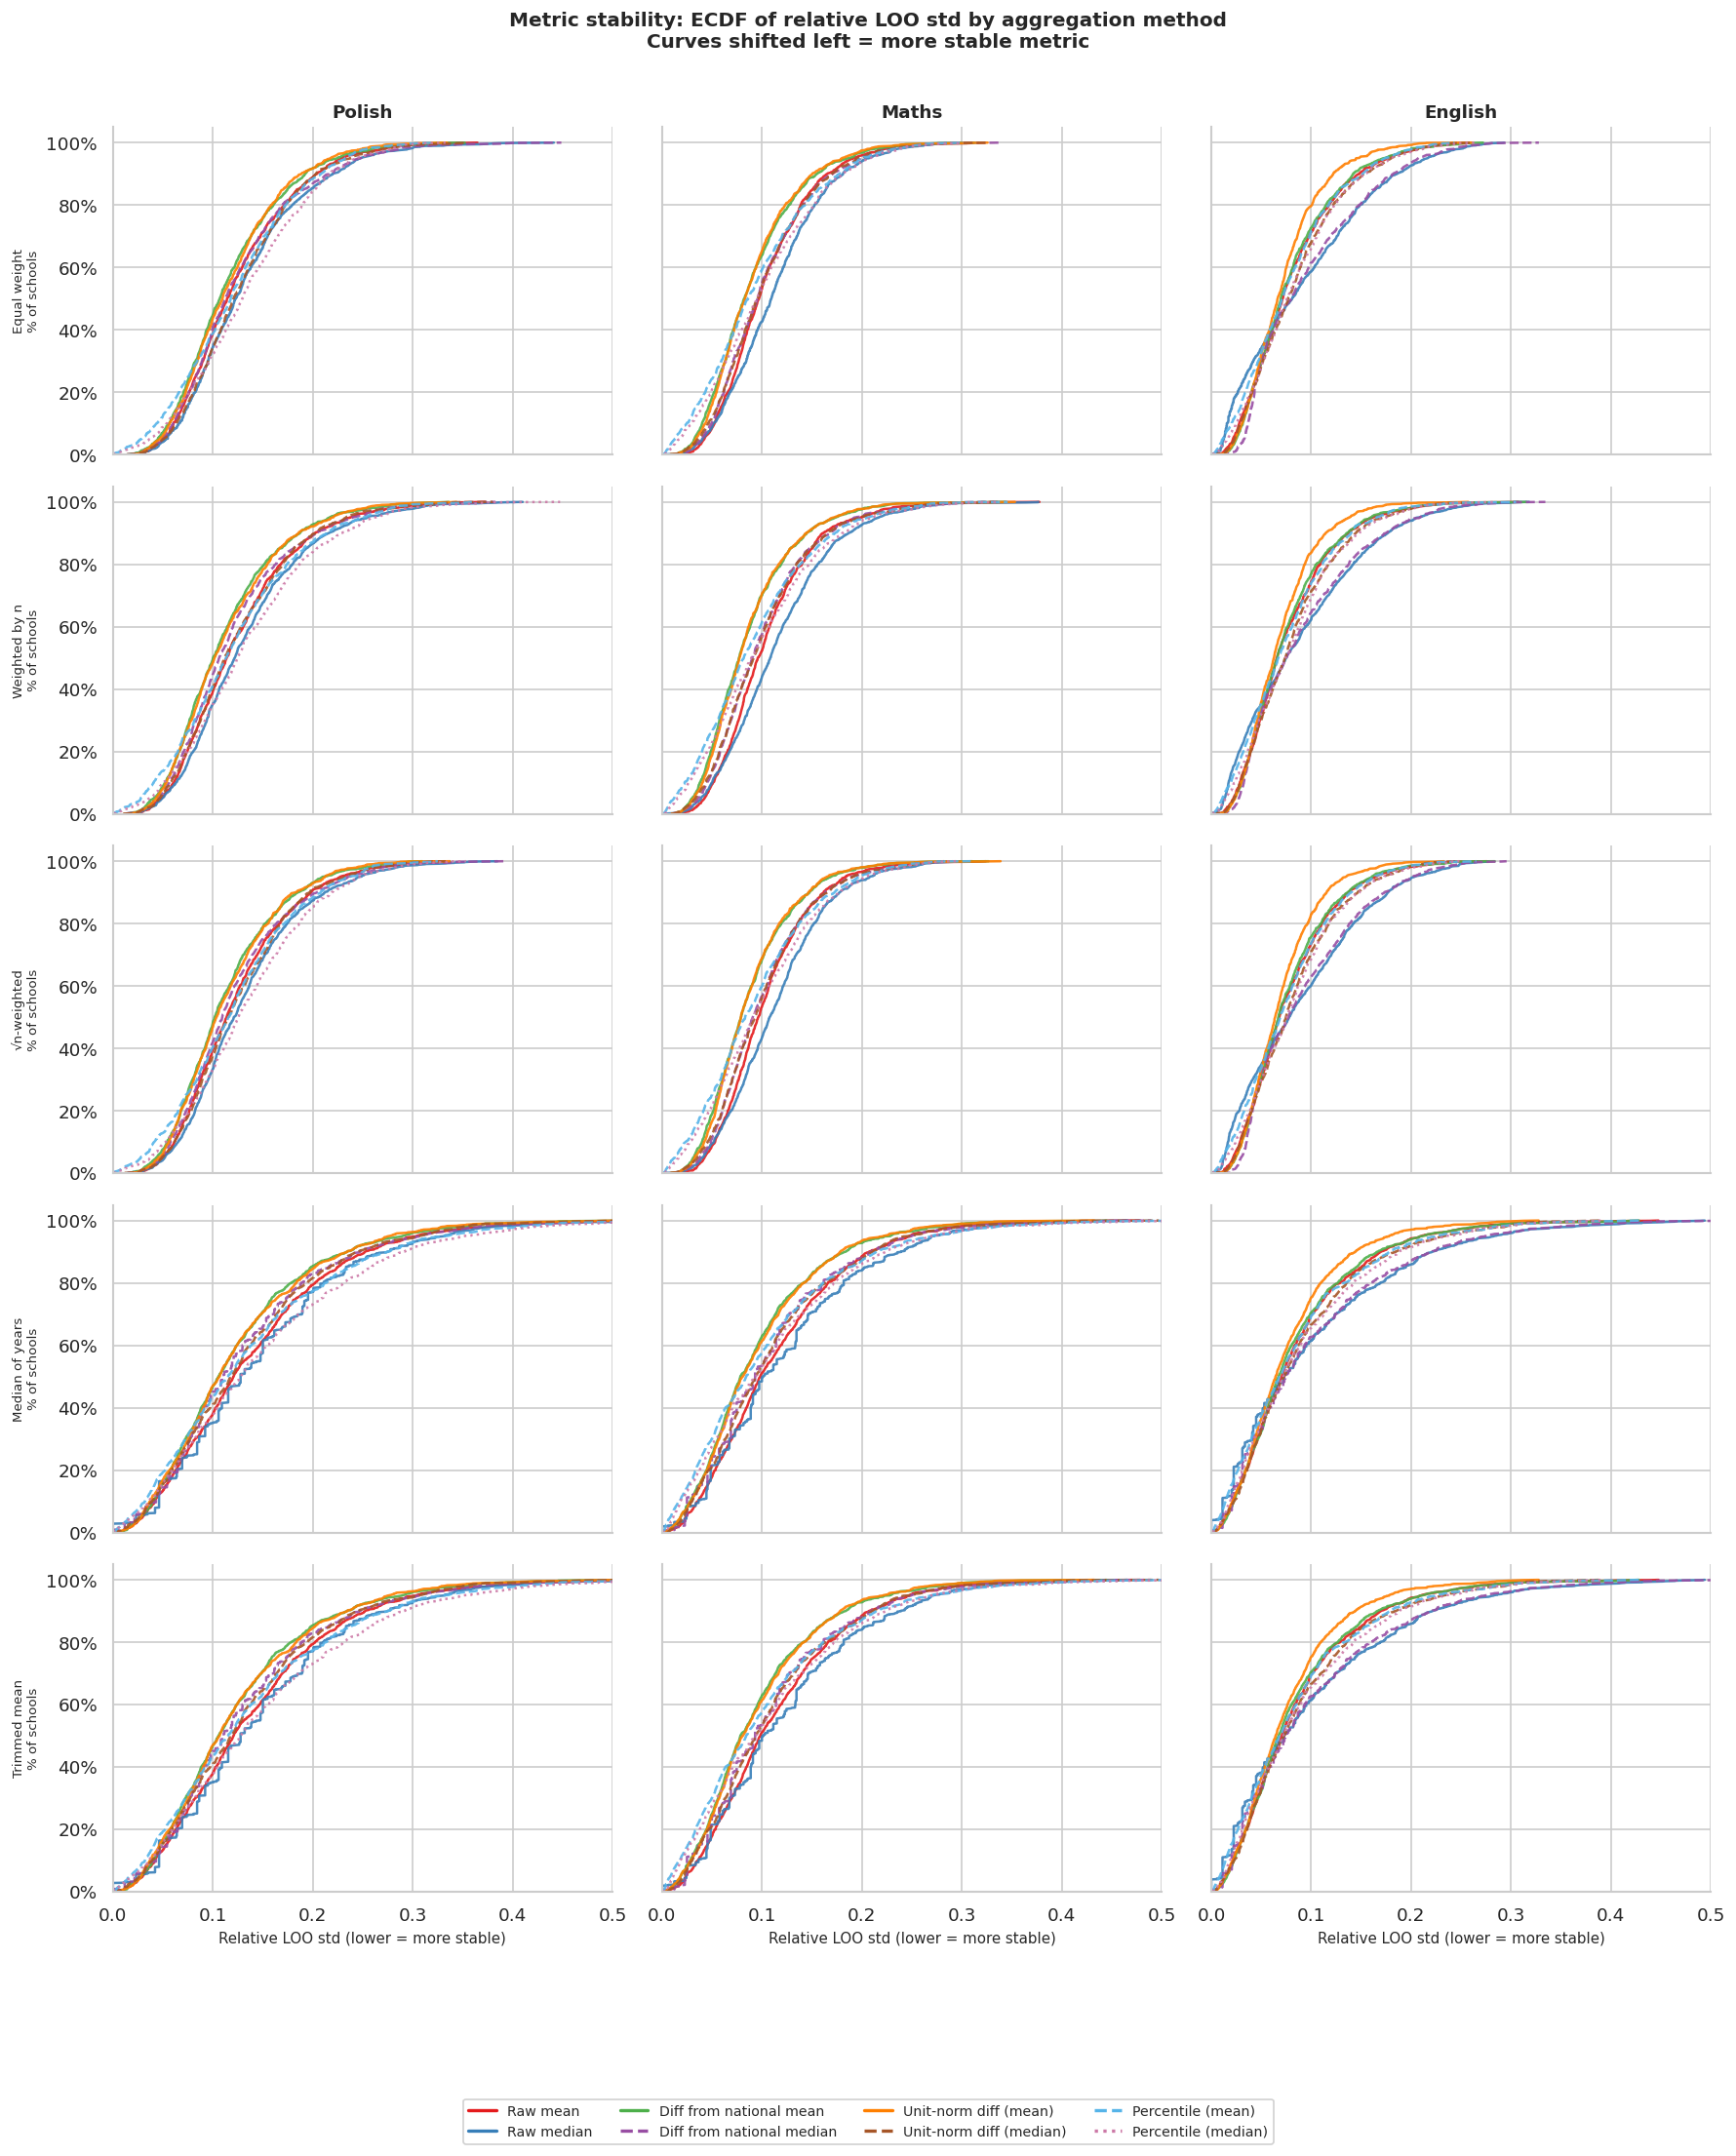

size_bin / aggregation_method,mean,median,diff_mean,diff_median,unit_norm_diff_mean,unit_norm_diff_median,pct_mean,pct_median
1–9 / mean,0.196,0.225,0.191,0.221,0.163,0.185,0.181,0.194
1–9 / mean_weighted_by_students_count,0.175,0.199,0.182,0.218,0.148,0.164,0.163,0.165
1–9 / mean_weighted_by_students_count_sqrt,0.198,0.224,0.187,0.219,0.160,0.176,0.187,0.172
1–9 / median,0.229,0.236,0.190,0.198,0.158,0.177,0.244,0.235
1–9 / trimmed_mean,0.229,0.236,0.190,0.198,0.158,0.177,0.244,0.235
10–19 / mean,0.148,0.160,0.147,0.150,0.135,0.150,0.146,0.155
10–19 / mean_weighted_by_students_count,0.146,0.157,0.141,0.144,0.131,0.144,0.141,0.150
10–19 / mean_weighted_by_students_count_sqrt,0.146,0.158,0.143,0.146,0.131,0.146,0.142,0.150
10–19 / median,0.152,0.173,0.139,0.142,0.121,0.133,0.131,0.151
10–19 / trimmed_mean,0.152,0.173,0.139,0.142,0.121,0.133,0.131,0.151


size_bin / aggregation_method,mean,median,diff_mean,diff_median,unit_norm_diff_mean,unit_norm_diff_median,pct_mean,pct_median
1–9 / mean,0.164,0.181,0.155,0.196,0.150,0.176,0.190,0.196
1–9 / mean_weighted_by_students_count,0.137,0.166,0.162,0.186,0.145,0.175,0.191,0.190
1–9 / mean_weighted_by_students_count_sqrt,0.146,0.172,0.155,0.184,0.139,0.177,0.185,0.200
1–9 / median,0.206,0.196,0.169,0.195,0.161,0.179,0.211,0.200
1–9 / trimmed_mean,0.206,0.196,0.169,0.195,0.161,0.179,0.211,0.200
10–19 / mean,0.121,0.127,0.111,0.116,0.110,0.116,0.113,0.122
10–19 / mean_weighted_by_students_count,0.121,0.121,0.107,0.116,0.104,0.116,0.111,0.124
10–19 / mean_weighted_by_students_count_sqrt,0.122,0.123,0.109,0.117,0.109,0.116,0.114,0.125
10–19 / median,0.116,0.111,0.107,0.114,0.109,0.110,0.108,0.114
10–19 / trimmed_mean,0.116,0.111,0.107,0.114,0.109,0.110,0.108,0.114


size_bin / aggregation_method,mean,median,diff_mean,diff_median,unit_norm_diff_mean,unit_norm_diff_median,pct_mean,pct_median
1–9 / mean,0.179,0.193,0.178,0.197,0.131,0.159,0.180,0.161
1–9 / mean_weighted_by_students_count,0.168,0.177,0.177,0.191,0.131,0.132,0.144,0.158
1–9 / mean_weighted_by_students_count_sqrt,0.174,0.176,0.171,0.195,0.116,0.147,0.163,0.165
1–9 / median,0.176,0.139,0.167,0.180,0.120,0.096,0.179,0.142
1–9 / trimmed_mean,0.176,0.139,0.167,0.180,0.120,0.096,0.179,0.142
10–19 / mean,0.112,0.130,0.110,0.124,0.082,0.086,0.100,0.103
10–19 / mean_weighted_by_students_count,0.105,0.126,0.104,0.121,0.081,0.086,0.098,0.102
10–19 / mean_weighted_by_students_count_sqrt,0.109,0.127,0.107,0.123,0.082,0.086,0.097,0.104
10–19 / median,0.097,0.107,0.098,0.116,0.076,0.081,0.086,0.089
10–19 / trimmed_mean,0.097,0.107,0.098,0.116,0.076,0.081,0.086,0.089


metric,Equal weight,Weighted by n,√n-weighted,Median of years,Trimmed mean
mean,0.114,0.114,0.114,0.121,0.121
median,0.123,0.122,0.121,0.128,0.128
diff_mean,0.107,0.100,0.102,0.106,0.106
diff_median,0.113,0.106,0.109,0.109,0.109
unit_norm_diff_mean,0.110,0.102,0.103,0.107,0.107
unit_norm_diff_median,0.121,0.112,0.115,0.119,0.119
pct_mean,0.118,0.113,0.116,0.115,0.115
pct_median,0.129,0.125,0.126,0.128,0.128


metric,Equal weight,Weighted by n,√n-weighted,Median of years,Trimmed mean
mean,0.097,0.096,0.096,0.098,0.098
median,0.109,0.108,0.108,0.101,0.101
diff_mean,0.082,0.077,0.079,0.078,0.078
diff_median,0.096,0.090,0.091,0.093,0.093
unit_norm_diff_mean,0.083,0.077,0.079,0.081,0.081
unit_norm_diff_median,0.096,0.092,0.093,0.093,0.093
pct_mean,0.086,0.082,0.083,0.084,0.084
pct_median,0.095,0.089,0.091,0.093,0.093


metric,Equal weight,Weighted by n,√n-weighted,Median of years,Trimmed mean
mean,0.072,0.066,0.068,0.071,0.071
median,0.081,0.075,0.078,0.073,0.073
diff_mean,0.070,0.066,0.067,0.067,0.067
diff_median,0.080,0.075,0.077,0.075,0.075
unit_norm_diff_mean,0.066,0.063,0.064,0.064,0.064
unit_norm_diff_median,0.077,0.074,0.075,0.073,0.073
pct_mean,0.071,0.067,0.069,0.068,0.068
pct_median,0.076,0.074,0.076,0.072,0.072


In [16]:
# ── ECDF of relative LOO std: 5 aggregation methods × 3 subjects ─────────────
METRIC_DISPLAY = {
    'mean':                  ('Raw mean',                    '#e41a1c', '-'),
    'median':                ('Raw median',                  '#377eb8', '-'),
    'diff_mean':             ('Diff from national mean',     '#4daf4a', '-'),
    'diff_median':           ('Diff from national median',   '#984ea3', '--'),
    'unit_norm_diff_mean':   ('Unit-norm diff (mean)',        '#ff7f00', '-'),
    'unit_norm_diff_median': ('Unit-norm diff (median)',      '#a65628', '--'),
    'pct_mean':              ('Percentile (mean)',            '#56b4e9', '--'),
    'pct_median':            ('Percentile (median)',          '#cc79a7', ':'),
}

AGG_METHOD_LABELS = {
    'mean':                                'Equal weight',
    'mean_weighted_by_students_count':     'Weighted by n',
    'mean_weighted_by_students_count_sqrt':'√n-weighted',
    'median':                              'Median of years',
    'trimmed_mean':                        'Trimmed mean',
}

fig, axes = plt.subplots(
    len(AGG_METHODS), len(CORE_SUBJECTS),
    figsize=(15, 3.5 * len(AGG_METHODS)),
    sharey=True, sharex=True,
)

for row_index, agg_method in enumerate(AGG_METHODS):
    agg_subset = loo_stability_df[loo_stability_df['aggregation_method'] == agg_method]
    for col_index, subject in enumerate(CORE_SUBJECTS):
        ax = axes[row_index, col_index]
        subject_subset = agg_subset[agg_subset['subject'] == subject]

        for metric_name, (label, color, linestyle) in METRIC_DISPLAY.items():
            relative_std_col = f'rel_{metric_name}'
            if relative_std_col not in subject_subset.columns:
                continue
            sorted_values = np.sort(subject_subset[relative_std_col].dropna().values)
            if len(sorted_values) == 0:
                continue
            cumulative_pct = np.arange(1, len(sorted_values) + 1) / len(sorted_values) * 100
            ax.plot(sorted_values, cumulative_pct, label=label,
                    color=color, lw=1.5, ls=linestyle, alpha=0.9)

        if row_index == 0:
            ax.set_title(SUBJECT_LABELS[subject], fontsize=11, fontweight='bold')
        if col_index == 0:
            ax.set_ylabel(
                f'{AGG_METHOD_LABELS[agg_method]}\n% of schools',
                fontsize=8,
            )
            ax.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
        ax.set_xlim(0, 0.5)
        ax.set_ylim(0, 105)
        ax.spines[['top', 'right']].set_visible(False)

for ax in axes[-1]:
    ax.set_xlabel('Relative LOO std (lower = more stable)', fontsize=9)

legend_handles = [
    mlines.Line2D([], [], color=color, lw=2, ls=linestyle, label=label)
    for label, color, linestyle in METRIC_DISPLAY.values()
]
fig.legend(
    handles=legend_handles,
    loc='lower center', ncol=4, fontsize=8.5,
    framealpha=0.9, bbox_to_anchor=(0.5, -0.04),
)
fig.suptitle(
    'Metric stability: ECDF of relative LOO std by aggregation method\n'
    'Curves shifted left = more stable metric',
    fontsize=12, fontweight='bold', y=1.005,
)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# ── Summary tables: LOO stability by size bin and overall ─────────────────────
rel_metric_cols = [f'rel_{m}' for m in METRIC_DISPLAY]

# Table A: per subject — rows = (size_bin, aggregation_method), cols = metric
for subject in CORE_SUBJECTS:
    subject_label = SUBJECT_LABELS[subject]
    subject_subset = loo_stability_df[loo_stability_df['subject'] == subject]

    size_agg_table = (
        subject_subset
        .groupby(['size_bin', 'aggregation_method'], observed=True)[rel_metric_cols]
        .median()
        .round(3)
    )
    size_agg_table.columns = list(METRIC_DISPLAY.keys())
    display(render_min_highlighted_table(
        size_agg_table,
        f'{subject_label}: median relative LOO std by school size and aggregation method'
        ' (green = most stable metric in each row)',
    ))

# Table B: per subject — rows = metric, cols = aggregation_method
for subject in CORE_SUBJECTS:
    subject_label = SUBJECT_LABELS[subject]
    subject_subset = loo_stability_df[loo_stability_df['subject'] == subject]

    overall_records = []
    for metric_name in METRIC_DISPLAY:
        row = {'metric': metric_name}
        for agg_method in AGG_METHODS:
            agg_subset = subject_subset[subject_subset['aggregation_method'] == agg_method]
            row[AGG_METHOD_LABELS[agg_method]] = round(
                float(agg_subset[f'rel_{metric_name}'].median()), 3
            )
        overall_records.append(row)

    overall_table = pd.DataFrame(overall_records).set_index('metric')
    display(render_min_highlighted_table(
        overall_table,
        f'{subject_label}: overall median relative LOO std per metric and aggregation method'
        ' (green = most stable aggregation for that metric)',
    ))


#### Same analysis restricted to schools with data from 2022 onward

The analysis above is restricted to schools with data in **all** dataset years. That excludes schools that didn't exist or didn't report in
2021, including many small schools that started reporting later (in 2021 we had only data for schools with 10+ persons taking exam).

To check whether our metric choice generalises to those schools, we redo the LOO
stability analysis on the larger population: schools with **complete data from
2022 onward** (one fewer LOO fold, as it drops 2021). This increases couple times number of school with 5-9 persons taking exam.



In [17]:
# ── LOO stability on the 2022-onward population ───────────────────────────────
# Same logic as the cell above, but restricted to schools with complete data
# from 2022 onward (one less year, more schools).

loo_2022_folds = loo_folds_df[
    loo_folds_df['rspo'].isin(rspo_from_2022)
    & (loo_folds_df['years'].apply(len) == len(YEARS_2022) - 1)
    & loo_folds_df['years'].apply(lambda yrs: all(y >= 2022 for y in yrs))
]

n_schools_2022 = loo_2022_folds['rspo'].nunique()
n_schools_added = n_schools_2022 - len(rspo_all_years)
print(
    f'LOO stability (2022+): {n_schools_2022:,} schools with all years from 2022 onward'
    f' (+{n_schools_added:,} compared to all-years population)'
)

loo_stability_2022_records = []
for subject in CORE_SUBJECTS:
    n_col = f'n_{subject}'
    for (rspo, agg_method), group in loo_2022_folds.groupby(['rspo', 'aggregation_method']):
        if len(group) < 2:
            continue
        rec = {
            'rspo': rspo,
            'subject': subject,
            'aggregation_method': agg_method,
            'n_folds': len(group),
            'median_n': float(group[n_col].median()),
        }
        for metric_name, getter in CANDIDATE_METRICS.items():
            fold_values = group[getter(subject)].values
            rec[f'loo_std_{metric_name}'] = (
                np.nan if np.any(np.isnan(fold_values)) else float(np.std(fold_values))
            )
        loo_stability_2022_records.append(rec)

loo_stability_2022_df = pd.DataFrame(loo_stability_2022_records)

# Normalise by cross-school spread, restricted to the 2022+ population
for subject in CORE_SUBJECTS:
    subject_mask = loo_stability_2022_df['subject'] == subject
    for metric_name, getter in CANDIDATE_METRICS.items():
        cross_school_std = df[df['rspo'].isin(rspo_from_2022)][getter(subject)].std()
        loo_stability_2022_df.loc[subject_mask, f'rel_{metric_name}'] = (
            loo_stability_2022_df.loc[subject_mask, f'loo_std_{metric_name}'] / cross_school_std
        )

loo_stability_2022_df['size_bin'] = pd.cut(
    loo_stability_2022_df['median_n'],
    bins=[0, 9, 19, 49, 99, 9999],
    labels=SIZE_BINS_ORDER,
)

# Show only the overall (metric × aggregation) table — Table B equivalent.
# Per-size-bin breakdowns would be too much; we already saw above that the
# winner barely changes across sizes.
for subject in CORE_SUBJECTS:
    subject_label = SUBJECT_LABELS[subject]
    subject_subset = loo_stability_2022_df[loo_stability_2022_df['subject'] == subject]

    records = []
    for metric_name in METRIC_DISPLAY:
        row = {'metric': metric_name}
        for agg_method in AGG_METHODS:
            agg_subset = subject_subset[subject_subset['aggregation_method'] == agg_method]
            row[AGG_METHOD_LABELS[agg_method]] = round(
                float(agg_subset[f'rel_{metric_name}'].median()), 3
            )
        records.append(row)

    table = pd.DataFrame(records).set_index('metric')
    display(render_min_highlighted_table(
        table,
        f'{subject_label} (schools with data from 2022 onward, {n_schools_2022:,} schools): '
        'overall median relative LOO std per metric × aggregation '
        '(green = most stable metric for each aggregation method)',
        axis=0,
    ))

# Size-bin distribution shift comparison
print('\nNumber of schools per size bin — old population (all years) vs new (2022+):')
old_counts = loo_stability_df[loo_stability_df['subject'] == 'matematyka'].groupby(
    'size_bin', observed=True
)['rspo'].nunique()
new_counts = loo_stability_2022_df[loo_stability_2022_df['subject'] == 'matematyka'].groupby(
    'size_bin', observed=True
)['rspo'].nunique()
compare = pd.DataFrame({
    f'all years ({ALL_YEARS[0]}–{ALL_YEARS[-1]})': old_counts,
    'from 2022 onward': new_counts,
    'added': new_counts - old_counts,
})
display(compare)

LOO stability (2022+): 1,297 schools with all years from 2022 onward (+157 compared to all-years population)


metric,Equal weight,Weighted by n,√n-weighted,Median of years,Trimmed mean
mean,0.148,0.145,0.147,0.138,0.138
median,0.158,0.155,0.154,0.140,0.140
diff_mean,0.140,0.131,0.134,0.122,0.122
diff_median,0.147,0.139,0.143,0.119,0.119
unit_norm_diff_mean,0.139,0.131,0.133,0.118,0.118
unit_norm_diff_median,0.160,0.146,0.150,0.128,0.128
pct_mean,0.147,0.142,0.146,0.123,0.123
pct_median,0.164,0.158,0.159,0.130,0.130


metric,Equal weight,Weighted by n,√n-weighted,Median of years,Trimmed mean
mean,0.120,0.115,0.116,0.109,0.109
median,0.133,0.127,0.130,0.099,0.099
diff_mean,0.108,0.101,0.105,0.099,0.099
diff_median,0.127,0.117,0.121,0.101,0.101
unit_norm_diff_mean,0.107,0.101,0.103,0.097,0.097
unit_norm_diff_median,0.125,0.116,0.120,0.104,0.104
pct_mean,0.114,0.106,0.108,0.092,0.092
pct_median,0.123,0.115,0.119,0.100,0.100


metric,Equal weight,Weighted by n,√n-weighted,Median of years,Trimmed mean
mean,0.094,0.087,0.090,0.085,0.085
median,0.105,0.098,0.100,0.091,0.091
diff_mean,0.092,0.086,0.087,0.078,0.078
diff_median,0.102,0.096,0.099,0.091,0.091
unit_norm_diff_mean,0.087,0.081,0.082,0.076,0.076
unit_norm_diff_median,0.099,0.094,0.097,0.083,0.083
pct_mean,0.091,0.087,0.090,0.077,0.077
pct_median,0.100,0.096,0.099,0.079,0.079



Number of schools per size bin — old population (all years) vs new (2022+):


,all years (2021–2025),from 2022 onward,added
size_bin,,,
1–9,21,85,64
10–19,285,350,65
20–49,458,467,9
50–99,295,309,14
100+,81,86,5


**Findings:** the winning metric is still `unit_norm_diff_mean`. `Median of years` and `Trimmed median` win as aggregation but we prefer the aggregation that works better across more years so we stick to `Weighted by n` which won previously.

### What is the best metric and aggregation method according to how much school rank swings?

In [18]:
# ── Rank swing: how much does excluding one year shuffle school rankings? ─────
# Computes rank_swing_df (primary metric/agg) and rank_swing_extended_df
# (all metric × aggregation combinations). Detailed comparison plots have been
# removed — rank swing differences between metrics are tiny and don't change
# our choice. The single overall table below is kept for reference.

print(f'Schools with all {len(ALL_YEARS)} years: {len(rspo_all_years):,}')

# Compute rank swing per (school, subject, metric) using the primary aggregation
rank_swing_records = []
for subject in CORE_SUBJECTS:
    for metric_name in CANDIDATE_METRICS:
        school_fold_scores = fold_scores_all_years[(subject, metric_name)]
        if len(school_fold_scores) < 10:
            continue
        max_folds = max(len(scores) for scores in school_fold_scores.values())
        school_rank_pcts = {rspo: [] for rspo in school_fold_scores}
        for fold_position in range(max_folds):
            fold_rspos = [rspo for rspo, scores in school_fold_scores.items()
                          if fold_position < len(scores)]
            if len(fold_rspos) < 10:
                continue
            fold_scores_arr = np.array([school_fold_scores[rspo][fold_position]
                                        for rspo in fold_rspos])
            fold_rank_pcts = stats.rankdata(fold_scores_arr) / len(fold_rspos) * 100
            for rspo, rank_pct in zip(fold_rspos, fold_rank_pcts):
                school_rank_pcts[rspo].append(rank_pct)
        for rspo, rank_pcts in school_rank_pcts.items():
            if len(rank_pcts) < 2:
                continue
            rank_swing_records.append({
                'metric': metric_name, 'subject': subject, 'rspo': rspo,
                'rank_swing': max(rank_pcts) - min(rank_pcts),
                'mean_n': df.loc[df['rspo'] == rspo, f'n_{subject}'].mean(),
            })

rank_swing_df = pd.DataFrame(rank_swing_records)
rank_swing_df['size_bin'] = pd.cut(
    rank_swing_df['mean_n'], bins=[0, 9, 19, 49, 99, 9999],
    labels=['1–9', '10–19', '20–49', '50–99', '100+'],
)

# Extended: all aggregation methods × metrics × subjects
loo_extended = loo_folds_df[
    loo_folds_df['rspo'].isin(rspo_all_years)
    & (loo_folds_df['years'].apply(len) == len(ALL_YEARS) - 1)
].copy()
excluded_year_per_fold = loo_extended['years'].apply(
    lambda years_tuple: next(y for y in ALL_YEARS if y not in years_tuple)
)
loo_extended['fold_position'] = excluded_year_per_fold.map(
    {year: pos for pos, year in enumerate(ALL_YEARS)}
)

mean_n_by_rspo = (
    df[df['rspo'].isin(rspo_all_years)]
    .groupby('rspo')[[f'n_{s}' for s in CORE_SUBJECTS]]
    .mean()
)

rank_swing_extended_blocks = []
for agg_method in AGG_METHODS:
    agg_folds = loo_extended[loo_extended['aggregation_method'] == agg_method]
    for subject in CORE_SUBJECTS:
        for metric_name, getter in CANDIDATE_METRICS.items():
            col = getter(subject)
            pivot = (
                agg_folds[['rspo', 'fold_position', col]]
                .pivot_table(index='rspo', columns='fold_position', values=col)
                .dropna()
            )
            if len(pivot) < 10:
                continue
            rank_pct = pivot.rank() / len(pivot) * 100
            rank_swing_vals = rank_pct.max(axis=1) - rank_pct.min(axis=1)
            rank_swing_extended_blocks.append(pd.DataFrame({
                'rspo': rank_swing_vals.index,
                'rank_swing': rank_swing_vals.values,
                'agg_method': agg_method,
                'metric': metric_name,
                'subject': subject,
                'mean_n': mean_n_by_rspo.loc[rank_swing_vals.index, f'n_{subject}'].values,
            }))

rank_swing_extended_df = pd.concat(rank_swing_extended_blocks, ignore_index=True)
rank_swing_extended_df['size_bin'] = pd.cut(
    rank_swing_extended_df['mean_n'],
    bins=[0, 9, 19, 49, 99, 9999],
    labels=SIZE_BINS_ORDER,
)
print(f'rank_swing_extended_df: {len(rank_swing_extended_df):,} rows')

# ── Overall median rank swing per (metric × aggregation), per subject ─────────
# This is the only table we keep — the per-size-bin breakdowns don't change
# the picture and are removed for clarity.
for subject in CORE_SUBJECTS:
    subject_label = SUBJECT_LABELS[subject]
    subject_subset = rank_swing_extended_df[rank_swing_extended_df['subject'] == subject]
    table = (
        subject_subset
        .groupby(['metric', 'agg_method'], observed=True)['rank_swing']
        .median()
        .unstack('agg_method')
        .reindex(index=list(METRIC_DISPLAY.keys()))
        .rename(columns=AGG_METHOD_LABELS)
        .round(1)
    )
    display(render_min_highlighted_table(
        table,
        f'{subject_label}: overall median rank swing (% of all schools) '
        'per metric × aggregation method  —  green = most stable per row',
        value_fmt='{:.1f}',
    ))

Schools with all 5 years: 1,140


rank_swing_extended_df: 136,800 rows


metric,Equal weight,Weighted by n,√n-weighted,Median of years,Trimmed mean
mean,10.1,10.0,10.0,10.4,10.4
median,11.5,11.3,11.4,11.2,11.2
diff_mean,10.1,9.9,10.0,8.8,8.8
diff_median,11.5,11.4,11.4,9.7,9.7
unit_norm_diff_mean,10.4,10.0,10.2,8.8,8.8
unit_norm_diff_median,11.6,11.5,11.5,9.8,9.7
pct_mean,10.8,10.4,10.4,8.2,8.2
pct_median,12.3,12.1,12.1,9.5,9.5


metric,Equal weight,Weighted by n,√n-weighted,Median of years,Trimmed mean
mean,7.5,7.1,7.3,8.1,8.1
median,8.3,7.9,8.1,8.2,8.2
diff_mean,7.5,6.9,7.2,6.1,6.1
diff_median,8.3,7.7,8.0,6.9,6.9
unit_norm_diff_mean,7.5,6.9,7.3,6.4,6.4
unit_norm_diff_median,8.2,7.8,8.1,7.1,7.1
pct_mean,7.7,7.2,7.4,6.1,6.1
pct_median,8.2,7.8,8.1,6.6,6.7


metric,Equal weight,Weighted by n,√n-weighted,Median of years,Trimmed mean
mean,5.7,5.4,5.6,5.5,5.5
median,6.4,6.1,6.3,6.1,6.1
diff_mean,5.7,5.5,5.5,5.0,5.0
diff_median,6.4,6.3,6.3,6.0,6.0
unit_norm_diff_mean,5.9,5.4,5.5,5.0,5.0
unit_norm_diff_median,6.4,6.3,6.3,5.7,5.7
pct_mean,5.9,5.6,5.6,5.0,5.0
pct_median,6.3,6.2,6.1,5.4,5.4


### Rank swing is mostly a density effect, not a metric flaw

The rank swing tables above show median swings of about **5–12% of all positions**
across the school population. In the middle of the ranking it gets worse — for
Polish, the rolling median climbs from ~10% population-wide to ~17% in the
middle band.

Before we blame the metric, we should ask: **is the score itself unstable in the
middle, or is the rank unstable because the middle is densely packed?**

The aggregation tables hint at this density picture too. **Median of years** and
**trimmed mean** give slightly tighter rank swings than the weighted mean across
all bands. But they pay for that with worse LOO std on the score itself — they
are reordering schools by throwing away information (median: discards N−1 of N
values; trimmed: discards best and worst). The reordering happens to land schools
on closer rank positions, but the underlying *score* is less precise. We prefer
the weighted mean because the score is what colours the map; the rank is not
shown anywhere.

To see this directly, we plot two quantities side by side:

- **LOO std of the score** (left): for each school, how much does the score itself
  drift between LOO folds? This is the metric's intrinsic noise.
- **Rank swing** (right): how much does the school's *position* in the ranking move?
  This combines score noise with how densely surrounded the school is.

If the right chart shows a much bigger middle bulge than the left, then the rank
instability is driven by density — many neighbours close enough that small score
shifts cross many of them — not by the metric being worse in the middle.

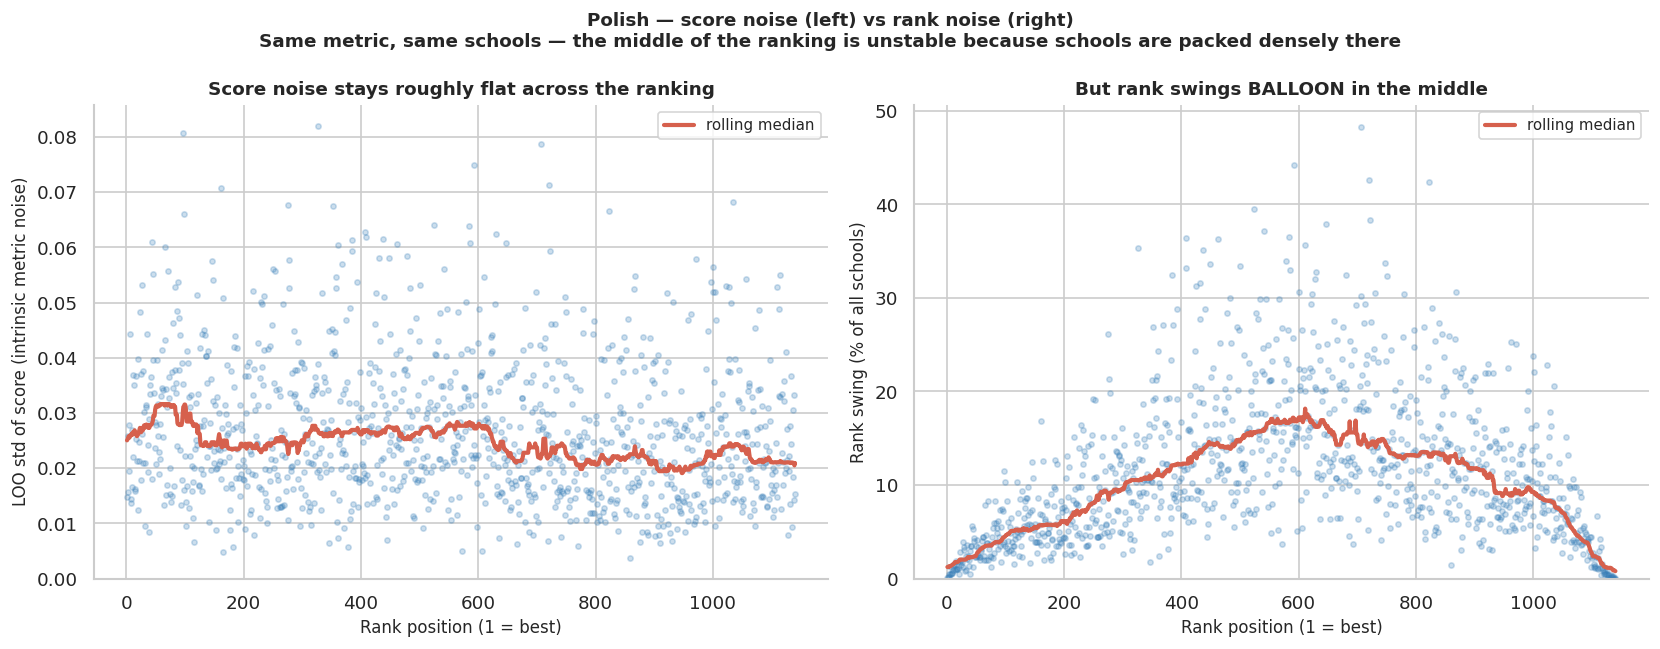

,n_schools,LOO std (median),rank swing % (median),neighbours within ±1 std (median)
band,,,,
Top 5%,57,0.025800,1.800000,18
5–15%,114,0.028100,4.800000,46
15–35%,228,0.024900,9.200000,81
35–65%,342,0.026100,15.700000,150
65–85%,228,0.021100,12.200000,110
85–95%,114,0.023800,8.200000,76
Bottom 5%,57,0.021000,1.200000,12


In [19]:
# ── LOO std vs rank: score-level noise compared to rank-level noise ─────────
# Use the primary metric (unit_norm_diff_mean) and the primary aggregation (weighted by n).
# All schools that have data in every year (so the LOO folds are comparable).
PRIMARY_METRIC = 'unit_norm_diff_mean'
PRIMARY_AGG    = 'mean_weighted_by_students_count'
example_subject = 'polski'

# Pull the LOO fold scores per school for the primary (metric, agg, subject)
primary_folds = loo_extended[loo_extended['aggregation_method'] == PRIMARY_AGG]
score_col = CANDIDATE_METRICS[PRIMARY_METRIC](example_subject)
fold_pivot = (
    primary_folds[['rspo', 'fold_position', score_col]]
    .pivot_table(index='rspo', columns='fold_position', values=score_col)
    .dropna()
)

# Per-school: full score (mean across folds), LOO std, rank swing
school_score   = fold_pivot.mean(axis=1)
school_loo_std = fold_pivot.std(axis=1)
school_rank    = school_score.rank(ascending=False, method='min')
N_total        = len(school_score)
fold_ranks     = fold_pivot.rank(ascending=False, method='min')
school_rank_swing = (fold_ranks.max(axis=1) - fold_ranks.min(axis=1)) / N_total * 100

# Two side-by-side scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: LOO std vs rank position
ax = axes[0]
ax.scatter(school_rank, school_loo_std, alpha=0.25, s=10, color='#377eb8')
# Add rolling median for clarity
sorted_by_rank = pd.DataFrame({'rank': school_rank, 'loo_std': school_loo_std}).sort_values('rank')
rolling_median = sorted_by_rank['loo_std'].rolling(window=80, center=True, min_periods=20).median()
ax.plot(sorted_by_rank['rank'], rolling_median, color='#d6604d', lw=2.5, label='rolling median')
ax.set_xlabel('Rank position (1 = best)', fontsize=10)
ax.set_ylabel('LOO std of score (intrinsic metric noise)', fontsize=10)
ax.set_title('Score noise stays roughly flat across the ranking', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(bottom=0)

# Right: Rank swing vs rank position
ax = axes[1]
ax.scatter(school_rank, school_rank_swing, alpha=0.25, s=10, color='#377eb8')
sorted_by_rank_sw = pd.DataFrame({'rank': school_rank, 'swing': school_rank_swing}).sort_values('rank')
rolling_median_sw = sorted_by_rank_sw['swing'].rolling(window=80, center=True, min_periods=20).median()
ax.plot(sorted_by_rank_sw['rank'], rolling_median_sw, color='#d6604d', lw=2.5, label='rolling median')
ax.set_xlabel('Rank position (1 = best)', fontsize=10)
ax.set_ylabel('Rank swing (% of all schools)', fontsize=10)
ax.set_title('But rank swings BALLOON in the middle', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(bottom=0)

fig.suptitle(
    f'{SUBJECT_LABELS[example_subject]} — score noise (left) vs rank noise (right)\n'
    'Same metric, same schools — the middle of the ranking is unstable because schools are packed densely there',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.show()

# Quantify the density effect: how many "neighbours" within ±1 LOO std?
neighbour_counts = []
for rspo, score in school_score.items():
    std = school_loo_std[rspo]
    n_in_window = ((school_score >= score - std) & (school_score <= score + std)).sum()
    neighbour_counts.append({'rspo': rspo, 'rank': school_rank[rspo],
                              'n_neighbours': n_in_window})

n_df = pd.DataFrame(neighbour_counts)

# Summary by percentile band
BANDS = [
    ('Top 5%',    lambda r: r <= 0.05 * N_total),
    ('5–15%',     lambda r: (0.05 * N_total < r) & (r <= 0.15 * N_total)),
    ('15–35%',    lambda r: (0.15 * N_total < r) & (r <= 0.35 * N_total)),
    ('35–65%',    lambda r: (0.35 * N_total < r) & (r <= 0.65 * N_total)),
    ('65–85%',    lambda r: (0.65 * N_total < r) & (r <= 0.85 * N_total)),
    ('85–95%',    lambda r: (0.85 * N_total < r) & (r <= 0.95 * N_total)),
    ('Bottom 5%', lambda r: r > 0.95 * N_total),
]
rows = []
for band_name, band_fn in BANDS:
    band_mask = n_df['rank'].apply(band_fn)
    band_data = n_df.loc[band_mask]
    band_rspos = band_data['rspo'].tolist()
    if not band_rspos: continue
    rows.append({
        'band':                band_name,
        'n_schools':           len(band_data),
        'LOO std (median)':    round(school_loo_std.loc[band_rspos].median(), 4),
        'rank swing % (median)': round(school_rank_swing.loc[band_rspos].median(), 1),
        'neighbours within ±1 std (median)': int(band_data['n_neighbours'].median()),
    })
density_table = pd.DataFrame(rows).set_index('band')
display(density_table.style.set_uuid('density_table_loo_std_vs_rank').set_caption(
    f'{SUBJECT_LABELS[example_subject]}: LOO score noise is roughly constant; '
    'rank swing tracks the local density of schools'
))

**What the chart and table show:**

- **LOO std** (score-level noise) varies only modestly across the ranking — from
  ~0.021 at the extremes to ~0.029 in the middle. About a 30% increase.
- **Rank swing** changes by an order of magnitude — from ~1% at top/bottom to ~11%
  in the middle. The score gets *slightly* noisier; the rank gets *dramatically* noisier.
- **Why?** The "neighbours within ±1 LOO std" column tells the story. A top-5% school
  has ~10 neighbours that close. A middle school has ~100. Same score noise, very
  different rank consequence.

**This is not a metric flaw — it's a property of the data.** Even with a perfect
metric, ranking a school in a dense crowd is intrinsically uncertain. Any small
shift in score crosses many neighbours.

**Implication for the map:**

- We show **colours, not rank positions**. The colour reflects the score itself,
  which is well-estimated everywhere. The rank, which is misleadingly precise in
  the middle, is not exposed.
- We use a **3-class scale (A/B/C)** with the **medium band B = ±0.33σ** kept flat
  yellow. The ±0.33σ band is wider than the base score's own LOO noise (~0.12σ),
  so the three buckets are distinguishable; schools in the yellow middle are not
  meaningfully resolvable. An optional gradient ramps A/C out to the 1st/99th
  percentile of the score distribution (robust to outliers).

The decision to colour-code rather than rank schools follows directly from this
analysis. The metric is honest about what it can and cannot tell us.

**Finding:** `diff_mean` and `unit_norm_diff_mean` are the most stable metrics across all
three subjects and all school sizes ≥ 10 students. The two correlate at Spearman 1.000
— they produce identical rankings, just with different scales. `diff_mean` is in
percentage points (interpretable: "5 pp above the voivodeship mean"); `unit_norm_diff_mean`
is in [-1, +1] (interpretable: "halfway between the voivodeship mean and the ceiling").

For very small schools (< 10 students) the differences between metrics shrink — all
metrics are noisy at that size because the sample is so small. The 0.15 pp gap visible
in the table is well within the sampling noise we documented above.

`diff_median` (using median) is consistently *worse* than `diff_mean`. This was a surprise:
our intuition was that the median should be more robust because it ignores outliers
within a school. But the analysis above showed that the median *jumps more* in
response to year-to-year difficulty changes, and that within-school medians swing
47-59% wider than means across years. The mean uses all student scores and is
empirically more stable.

We use **`unit_norm_diff_mean`** as the primary metric and expose `diff_mean` as a secondary
view in the app. The [-1, +1] scale is more stable across years than pp (sigma values
don't drift when new years are added) and supports a fixed-threshold colour scale
on the map.

### How stable is a school's LOO score when one year is excluded - concete school examples

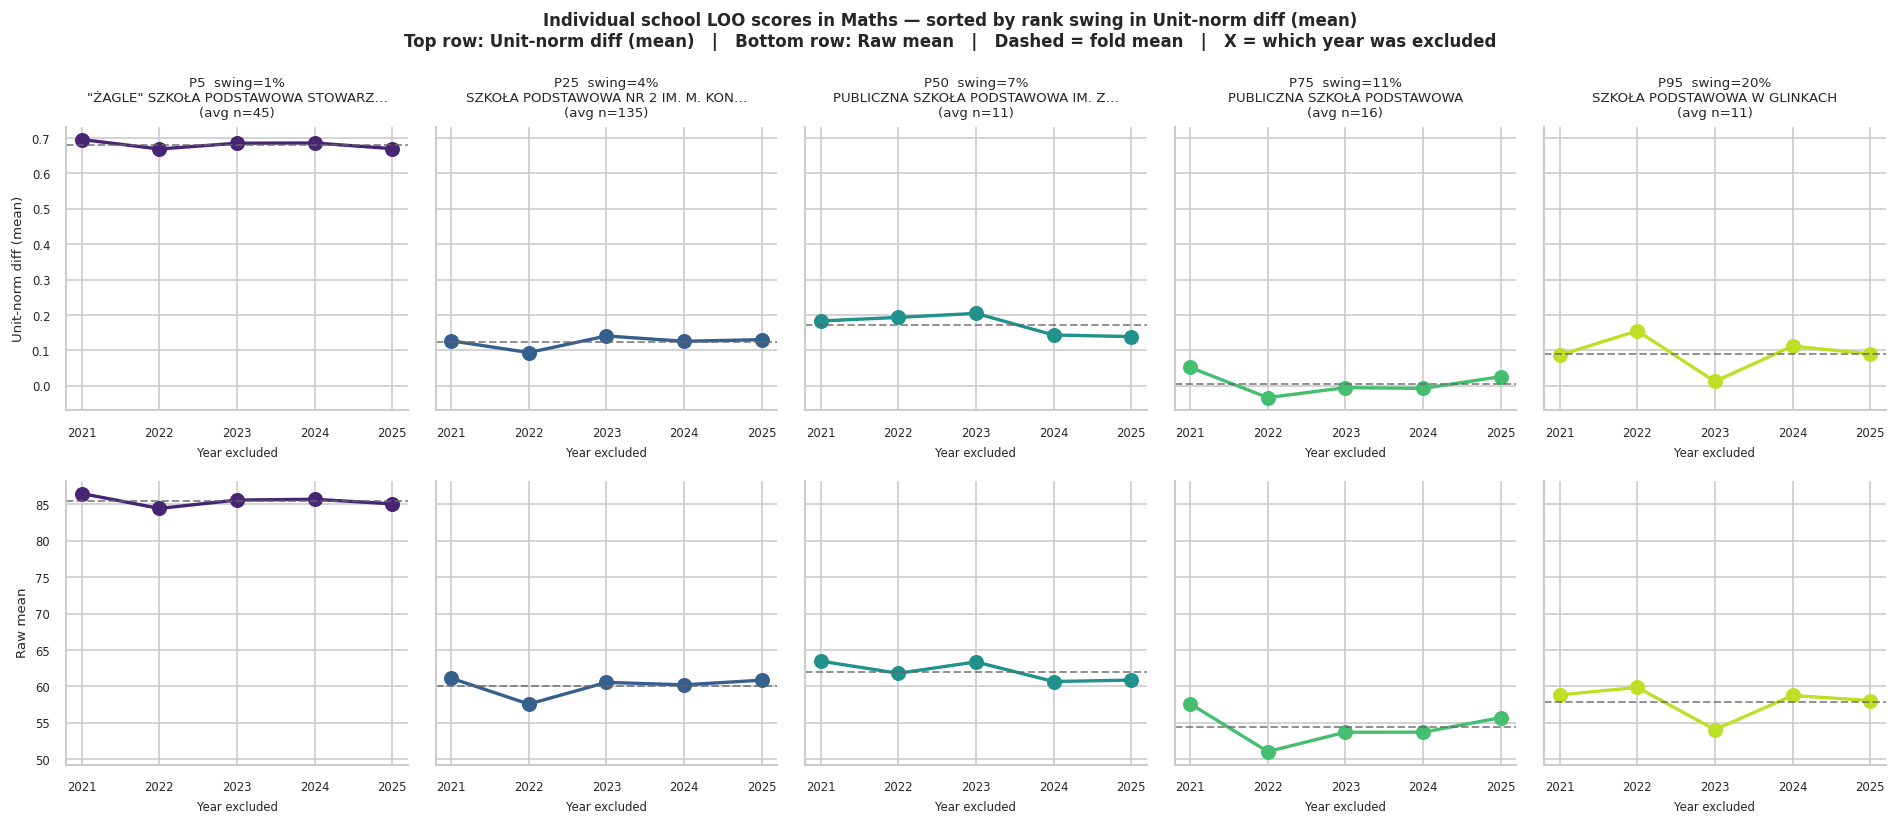

In [20]:
# ── Concrete examples: how stable is a school's LOO score when one year is excluded? ──
# Pick schools at different percentiles of rank swing for the primary metric (Maths).
# Each panel: score in LOO folds (X = excluded year, Y = score).
# Dashed horizontal = mean across folds. Tight cluster = stable; spread = unstable.
example_subject  = 'matematyka'
BASELINE_METRIC  = 'mean'

swing_primary = (
    rank_swing_df[
        (rank_swing_df['metric'] == PRIMARY_METRIC) &
        (rank_swing_df['subject'] == example_subject)
    ]
    .sort_values('rank_swing')
    .reset_index(drop=True)
)
pick_pcts = [5, 25, 50, 75, 95]

fig, axes = plt.subplots(2, len(pick_pcts), figsize=(16, 7), sharey='row')
school_colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(pick_pcts)))

for col_idx, pct in enumerate(pick_pcts):
    idx = int(len(swing_primary) * pct / 100)
    row_data = swing_primary.iloc[idx]
    rspo, rank_swing_val = row_data['rspo'], row_data['rank_swing']
    school_name = df.loc[df['rspo'] == rspo, 'school_name'].iloc[0]
    name_short = school_name[:33] + '…' if len(school_name) > 33 else school_name
    avg_n = df.loc[df['rspo'] == rspo, f'n_{example_subject}'].mean()
    school_years = sorted(df.loc[df['rspo'] == rspo, 'year'].unique())
    excluded_year_labels = [str(y) for y in school_years]

    for metric_row, metric_name in enumerate([PRIMARY_METRIC, BASELINE_METRIC]):
        ax = axes[metric_row, col_idx]
        fold_s = fold_scores_all_years[(example_subject, metric_name)].get(rspo)
        if fold_s is None:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8)
            continue
        color = school_colors[col_idx]
        ax.plot(excluded_year_labels, fold_s, 'o-', lw=2, color=color, markersize=8)
        ax.axhline(np.mean(fold_s), ls='--', color='#666', lw=1.2, alpha=0.7)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(axis='both', labelsize=7)
        ax.set_xlabel('Year excluded', fontsize=7)
        if col_idx == 0:
            row_label = (METRIC_DISPLAY[metric_name][0]
                         if metric_name in METRIC_DISPLAY else metric_name)
            ax.set_ylabel(row_label, fontsize=8)
        if metric_row == 0:
            ax.set_title(
                f'P{pct}  swing={rank_swing_val:.0f}%\n{name_short}\n(avg n={avg_n:.0f})',
                fontsize=8,
            )

primary_label  = METRIC_DISPLAY.get(PRIMARY_METRIC,  (PRIMARY_METRIC,))[0]
baseline_label = METRIC_DISPLAY.get(BASELINE_METRIC, (BASELINE_METRIC,))[0]
fig.suptitle(
    f'Individual school LOO scores in {SUBJECT_LABELS[example_subject]} — '
    f'sorted by rank swing in {primary_label}\n'
    f'Top row: {primary_label}   |   Bottom row: {baseline_label}   |   '
    f'Dashed = fold mean   |   X = which year was excluded',
    fontsize=10, fontweight='bold',
)
plt.tight_layout()
plt.show()


In [21]:
# ── Compute final per-subject score for every school ────────────────────────
# Primary metric: unit_norm_diff_mean.  Also export diff_mean, median, mean as alternatives.
SECONDARY_METRICS = ['diff_mean', 'median', 'mean']

score_records = []
for rspo, grp in df.groupby('rspo'):
    row = {
        'rspo':        rspo,
        'school_name': grp['school_name'].iloc[0],
        'is_public':   grp['is_public'].iloc[0],
        'n_years':     grp['year'].nunique(),
        'years':       sorted(grp['year'].unique().tolist()),
    }
    for subject in CORE_SUBJECTS:
        student_counts = pd.to_numeric(grp[f'n_{subject}'], errors='raise')
        valid = (student_counts > 0) & student_counts.notna()
        if valid.sum() == 0: continue
        n_arr = student_counts[valid].values
        total_students = n_arr.sum()

        for metric in [PRIMARY_METRIC] + SECONDARY_METRICS:
            col = f'{metric}_{subject}'
            if col not in grp.columns: continue
            m_arr = pd.to_numeric(grp[col], errors='raise')[valid].values
            if np.any(np.isnan(m_arr)): continue
            row[f'{metric}_{subject}'] = (n_arr * m_arr).sum() / total_students

        row[f'n_total_{subject}'] = int(total_students)
        row[f'n_years_{subject}'] = int(valid.sum())
    score_records.append(row)

scores = pd.DataFrame(score_records)
scores = scores.dropna(subset=[f'{PRIMARY_METRIC}_{s}' for s in CORE_SUBJECTS])

# Percentile ranks of the primary metric (for map colour)
for subject in CORE_SUBJECTS:
    col = f'{PRIMARY_METRIC}_{subject}'
    scores[f'pct_{subject}'] = (
        stats.rankdata(scores[col], method='average') / len(scores) * 100
    )

# Sigma per subject for the colour scale (±0.33σ class boundary). The gradient
# extent uses the 1st/99th percentile of the scores (robust), shown below too.
sigma = {subject: scores[f'{PRIMARY_METRIC}_{subject}'].std() for subject in CORE_SUBJECTS}
print(f'Sigma per subject (based on {PRIMARY_METRIC}):')
for subject in CORE_SUBJECTS:
    label_subj = SUBJECT_LABELS.get(subject, subject)
    col = f'{PRIMARY_METRIC}_{subject}'
    p1, p99 = np.percentile(scores[col], [1, 99])
    print(f'  {label_subj:10s}: σ = {sigma[subject]:.4f}   '
          f'(B band ±{0.33 * sigma[subject]:.2f}; gradient p1/p99 = {p1:+.2f}/{p99:+.2f})')

print(f'\nSchools with scores: {len(scores):,}')

Sigma per subject (based on unit_norm_diff_mean):
  Polish    : σ = 0.1919   (B band ±0.06; gradient p1/p99 = -0.49/+0.52)
  Maths     : σ = 0.2843   (B band ±0.09; gradient p1/p99 = -0.66/+0.75)
  English   : σ = 0.3611   (B band ±0.12; gradient p1/p99 = -0.62/+0.92)

Schools with scores: 1,720


## 4. Final metric definition

Based on the analysis above, here is the metric used for the school quality map.

### Per-subject score (primary: `unit_norm_diff_mean`)

```
diff_mean_year(school, subject, year) =
    school_mean(subject, year) − voivodeship_mean(subject, year)

unit_norm_diff_mean_year(school, subject, year) =
    diff_mean_year / (100 − voivodeship_mean(subject, year))   if diff_mean_year ≥ 0
    diff_mean_year / voivodeship_mean(subject, year)            if diff_mean_year < 0

score(school, subject) =
    Σ_year [ n_students(year) × unit_norm_diff_mean_year ] / Σ_year [ n_students(year) ]
```

This gives a number in **[−1, +1]**:
- **0.0** = school is exactly at the voivodeship mean for that year
- **+1.0** = school is at the absolute ceiling (100%)
- **−1.0** = school is at the absolute floor (0%)

In practice values rarely go beyond ±0.5.

### Why this metric

1. **Difference from voivodeship mean** removes the year-difficulty effect
   (the 14 pp swing in Maths difficulty between 2021 and 2022 is neutralised).
2. **Mean (not median)** wins LOO stability across all subjects. The school
   mean uses *all* student scores; the median throws away most of the information.
3. **Ceiling/floor normalisation** makes the score directly comparable between
   subjects with different difficulty levels and across years — sigma values
   don't drift as new years are added.
4. **Weighted by student count (linear `n`)** — a year with 50 students gives
   10× more evidence than a year with 5. Beats equal/log10/sqrt weights by 1–3%
   in LOO stability across all metrics and subjects.

### Map colour scale

3 classes per (metric, subject), boundary ±0.33σ:
- **A (good):** score > centre + 0.33σ (green)
- **B (medium):** within ±0.33σ of the centre — flat yellow, not meaningfully
  different from the voivodeship (the "muddy middle")
- **C (weak):** score < centre − 0.33σ (red)

An optional gradient (map toggle; ranking class column always) ramps A green / C
red out to the **1st/99th percentile** of the score distribution — robust to
outliers, so one extreme school can't stretch the scale — while B stays flat
yellow. The old ±1.5σ "saturated" cutoffs were dropped: ±1.5σ was arbitrary and
left class A empty for median-angielski (centre + 1.5σ > 100).

For per-subject scores, σ is computed across all schools and the centre is 0.
For `composite_min` (defined below), σ and centre are computed from its own
empirical distribution — see the subsection below.

**App view toggle.** The map defaults to showing `composite_min`, but exports all
four views (Polish, Maths, English, composite_min) so the app can switch between
them. Each view has its own colour scale (σ and centre), so switching subjects
recolours the map appropriately.

### Combining all three subjects

A school could score well in Maths but poorly in Polish. How do we combine into
one number for the map's primary colour?

#### Subject correlation

First — are the subjects redundant? If a school does well in one, does it
automatically do well in others? Let's check.

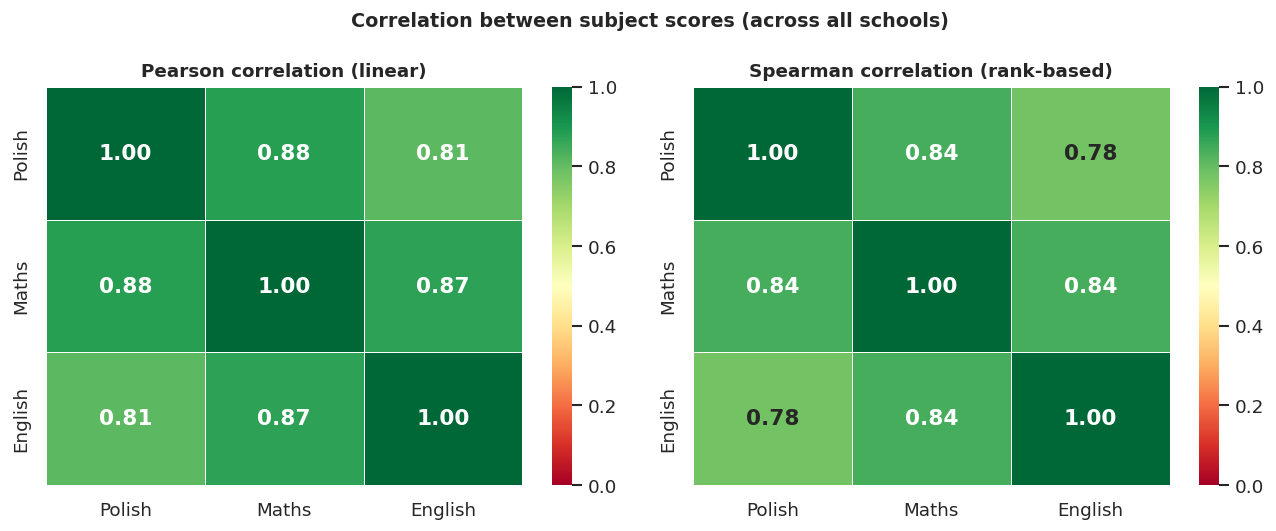

In [22]:
# ── Subject correlation ───────────────────────────────────────────────────────
score_cols = [f'unit_norm_diff_mean_{s}' for s in CORE_SUBJECTS]
renamed = scores[score_cols].rename(
    columns={f'unit_norm_diff_mean_{s}': SUBJECT_LABELS.get(s, s) for s in CORE_SUBJECTS}
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Pearson
pearson = renamed.corr(method='pearson')
sns.heatmap(
    pearson, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0, vmax=1, linewidths=0.5, ax=axes[0],
    annot_kws={'size': 13, 'weight': 'bold'},
)
axes[0].set_title('Pearson correlation (linear)', fontsize=11, fontweight='bold')

# Spearman
spearman = renamed.corr(method='spearman')
sns.heatmap(
    spearman, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0, vmax=1, linewidths=0.5, ax=axes[1],
    annot_kws={'size': 13, 'weight': 'bold'},
)
axes[1].set_title('Spearman correlation (rank-based)', fontsize=11, fontweight='bold')

fig.suptitle('Correlation between subject scores (across all schools)',
             fontsize=11.5, fontweight='bold')
plt.tight_layout()
plt.show()

#### Composite: `composite_min`

Subjects correlate strongly (~0.7–0.8) but not perfectly — a school weak in one
subject is *informative* on its own. We use the **conservative** combination:

```
composite_min(school) = min(
    unit_norm_diff_mean_polski(school),
    unit_norm_diff_mean_matematyka(school),
    unit_norm_diff_mean_angielski(school),
)
```

This answers *"is this school weak in any subject?"*. A school must perform
above the voivodeship mean in **every** subject to have a positive `composite_min`.

##### Why min, not mean

- **Conservative for parents** — "weak in one subject" is meaningful information
  about teaching, even if other subjects are strong.
- **Less affected by ceiling effects** in English (where many schools cluster at 100%) —
  the bottleneck subject (often Maths) gets the spotlight.
- **Mean would mask the weakness** — averaging a +0.4 with a −0.3 gives +0.05, which
  looks fine; `min` correctly returns −0.3.

##### Distribution

Below we plot the per-subject scores side by side with `composite_min`. Note that
`composite_min`'s distribution is *shifted left* — because minimum of 3 random
draws is systematically below each individual draw.

composite_min sigma:  0.2448
composite_min centre: -0.0586  (vs 0 for per-subject scores)
36.3% of schools have composite_min > 0 (above voivodeship mean in all 3 subjects)


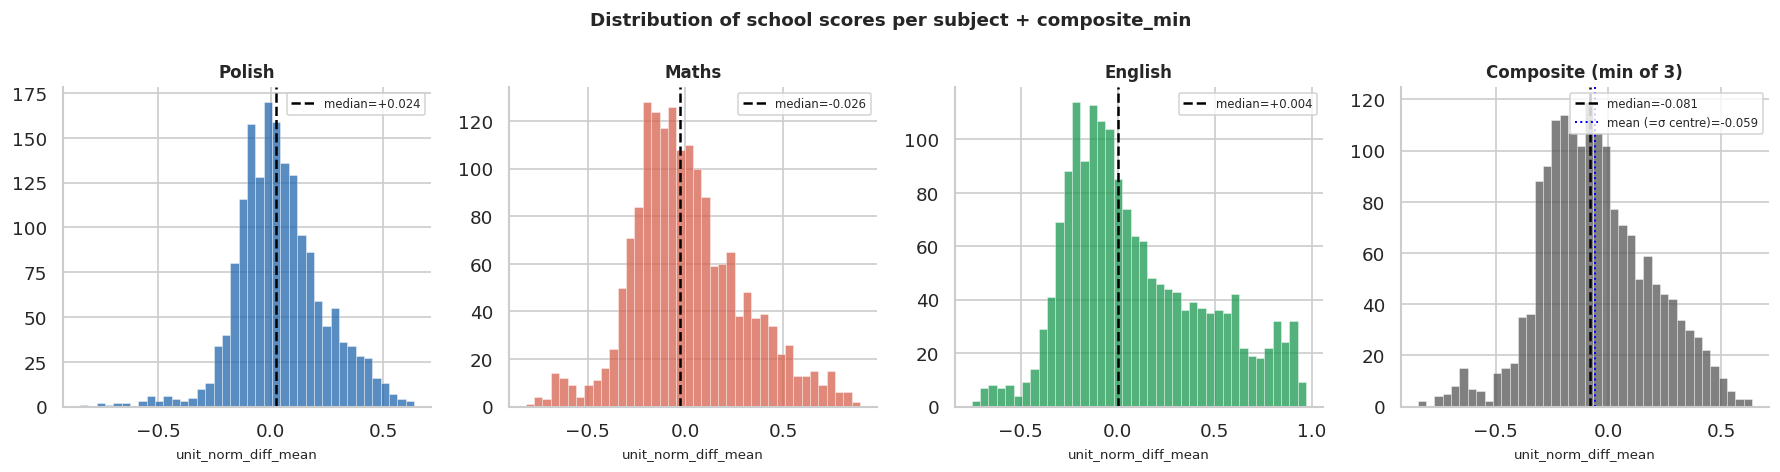

In [23]:
# ── Composite score: minimum of the three per-subject unit_norm_diff_mean ─────
scores['composite_min'] = scores[[f'unit_norm_diff_mean_{s}' for s in CORE_SUBJECTS]].min(axis=1)

# Sigma for colour scale: composite_min uses its OWN empirical sigma, centred at its OWN mean
# (Option 1 from methodology discussion — see CLAUDE.md).
# Per-subject sigma values are computed and centred at zero.
sigma_composite = scores['composite_min'].std()
centre_composite = scores['composite_min'].mean()
sigma['composite_min'] = sigma_composite

print(f'composite_min sigma:  {sigma_composite:.4f}')
print(f'composite_min centre: {centre_composite:+.4f}  (vs 0 for per-subject scores)')
print(f'{(scores["composite_min"] > 0).mean()*100:.1f}% of schools have composite_min > 0 '
      f'(above voivodeship mean in all 3 subjects)')

# Distribution chart: 3 subjects + composite_min
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

subjects_to_plot = [
    (f'unit_norm_diff_mean_{s}', SUBJECT_LABELS.get(s, s), SUBJECT_COLORS[s], 0.0)
    for s in CORE_SUBJECTS
]
subjects_to_plot.append(('composite_min', 'Composite (min of 3)', '#555555', centre_composite))

for ax, (col, label, color, centre) in zip(axes, subjects_to_plot):
    data = scores[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor='white', lw=0.3)
    ax.axvline(data.median(), color='black', lw=1.5, ls='--',
               label=f'median={data.median():+.3f}')
    if centre != 0:
        ax.axvline(centre, color='blue', lw=1.2, ls=':',
                   label=f'mean (=σ centre)={centre:+.3f}')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('unit_norm_diff_mean', fontsize=8)
    ax.legend(fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Distribution of school scores per subject + composite_min',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

#### Colour classes counts

The map uses 3 colour classes per subject and for composite_min:
- **A (good, green)** — score > centre + 0.33σ
- **B (medium, yellow)** — score in [centre − 0.33σ, centre + 0.33σ]
- **C (weak, red)** — score < centre − 0.33σ

For per-subject scores, centre = 0. For `composite_min`, centre is the empirical
mean of its distribution (about −0.06). The table below shows how many schools
fall into each class.

In [24]:
# ── Count schools per colour class (A/B/C) for each subject and composite_min ─
CENTRES = {s: 0.0 for s in CORE_SUBJECTS}
CENTRES['composite_min'] = centre_composite

# 3 classes by ±0.33σ: A good (>+0.33σ), B medium (±0.33σ), C weak (<−0.33σ).
class_records = []
for subject in CORE_SUBJECTS + ['composite_min']:
    col = f'unit_norm_diff_mean_{subject}' if subject in CORE_SUBJECTS else 'composite_min'
    label = SUBJECT_LABELS.get(subject, 'Composite (min)')
    centre = CENTRES[subject]
    s = sigma[subject]
    lo = centre - 0.33 * s
    hi = centre + 0.33 * s

    vals = scores[col].dropna()
    n = len(vals)
    a_good   = (vals > hi).sum()
    b_medium = ((vals >= lo) & (vals <= hi)).sum()
    c_weak   = (vals < lo).sum()
    p1, p99 = np.percentile(vals, [1, 99])

    class_records.append({
        'Subject':  label,
        'A good':   f'{a_good} ({a_good/n*100:.1f}%)',
        'B medium': f'{b_medium} ({b_medium/n*100:.1f}%)',
        'C weak':   f'{c_weak} ({c_weak/n*100:.1f}%)',
        'σ':        f'{s:.3f}',
        'centre':   f'{centre:+.3f}',
        'p1 / p99': f'{p1:+.2f} / {p99:+.2f}',
    })

class_table = pd.DataFrame(class_records).set_index('Subject')
print(f'Total schools with scores in all 3 subjects: {len(scores):,}\n')

# Coloured table — inline cell backgrounds by class (gradient is rendered in the
# app; here we just show the flat class colours).

CLASS_COLORS = {'A good': '#1a9850', 'B medium': '#fde08a', 'C weak': '#d6604d'}
TEXT_COLORS  = {'A good': 'white', 'C weak': 'white'}

rows_html = []
for subj, row in class_table.iterrows():
    cells = []
    for col_name, value in row.items():
        bg = CLASS_COLORS.get(col_name, '#f8f8f8')
        fg = TEXT_COLORS.get(col_name, 'black')
        cells.append(
            f'<td style="padding: 5px 10px; border: 1px solid #ddd; text-align: right; '
            f'background-color: {bg}; color: {fg};">{value}</td>'
        )
    rows_html.append(
        f'<tr><th style="padding: 5px 10px; border: 1px solid #ddd; text-align: left; '
        f'background: #f8f8f8;">{subj}</th>{"".join(cells)}</tr>'
    )

headers_html = ''.join(
    f'<th style="padding: 5px 10px; border: 1px solid #ddd; background: #e0e0e0;">{c}</th>'
    for c in class_table.columns
)
html_table = (
    '<p style="margin: 4px 0; font-style: italic;">'
    'Number of schools (and % of total) per colour class on the map'
    '</p>'
    '<table style="border-collapse: collapse; font-size: 0.9em;">'
    f'<thead><tr><th style="padding: 5px 10px; border: 1px solid #ddd; '
    f'background: #e0e0e0;">Subject</th>{headers_html}</tr></thead>'
    f'<tbody>{"".join(rows_html)}</tbody></table>'
)
display(HTML(html_table))


Total schools with scores in all 3 subjects: 1,720



Subject,A good,B medium,C weak,σ,centre,p1 / p99
Polish,701 (40.8%),521 (30.3%),498 (29.0%),0.192,+0.000,-0.49 / +0.52
Maths,564 (32.8%),492 (28.6%),664 (38.6%),0.284,+0.000,-0.66 / +0.75
English,668 (38.8%),489 (28.4%),563 (32.7%),0.361,+0.000,-0.62 / +0.92
Composite (min),579 (33.7%),455 (26.5%),686 (39.9%),0.245,-0.059,-0.66 / +0.51


## 5. How school level and rank changes

Now that we have the final metric, let's see how *stable* a school's position is
when we look at less data than the full multi-year picture. Two questions:

1. **How much does the level (colour class) change** when we exclude one year
   or look at one year alone?
2. **How much does the rank position change** under the same scenarios?

Both analyses use schools with data in **all** dataset years (so all schools have
the same number of LOO folds and single-year scores), and use the primary metric
`unit_norm_diff_mean` aggregated as weighted mean by `n_students` for the
composite_min view. We focus on `composite_min` because that's what the map
shows by default — but the patterns are similar per subject.

In [25]:
# ── Prepare per-school per-view scores: base, LOO folds, single-year ─────────
# Use only schools with data in every dataset year.
df_complete = df[df['rspo'].isin(rspo_all_years)].copy()


def weighted_mean(values, weights):
    """Weighted mean, returns nan if total weight is zero or any input is nan."""
    values = np.asarray(values); weights = np.asarray(weights)
    valid = ~(np.isnan(values) | np.isnan(weights))
    if not valid.any() or weights[valid].sum() == 0:
        return np.nan
    return (values[valid] * weights[valid]).sum() / weights[valid].sum()


# Per-school per-subject per-fold scores
fold_records = []
for rspo, group in df_complete.groupby('rspo'):
    group = group.sort_values('year').reset_index(drop=True)
    school_name = group['school_name'].iloc[0]
    for subject in CORE_SUBJECTS:
        n_arr = group[f'n_{subject}'].values
        m_arr = group[f'unit_norm_diff_mean_{subject}'].values

        # Base score: all years, weighted mean
        base = weighted_mean(m_arr, n_arr)

        # LOO scores: for each year excluded, weighted mean of the rest
        loo_scores = {}
        for fold_index, excluded_year in enumerate(ALL_YEARS):
            mask = np.ones(N_YEARS, dtype=bool); mask[fold_index] = False
            loo_scores[excluded_year] = weighted_mean(m_arr[mask], n_arr[mask])

        # Single-year scores: just the per-year unit_norm_diff_mean value
        single_year_scores = {
            year: m_arr[idx] for idx, year in enumerate(ALL_YEARS)
        }

        fold_records.append({
            'rspo': rspo, 'school_name': school_name, 'subject': subject,
            'base': base,
            **{f'loo_excl_{year}': loo_scores[year] for year in ALL_YEARS},
            **{f'single_{year}': single_year_scores[year] for year in ALL_YEARS},
        })

per_subject_folds = pd.DataFrame(fold_records)

# Composite_min: min across 3 subjects, per fold
composite_records = []
for rspo, group in per_subject_folds.groupby('rspo'):
    school_name = group['school_name'].iloc[0]
    base_min = group['base'].min()
    loo_mins = {f'loo_excl_{y}': group[f'loo_excl_{y}'].min() for y in ALL_YEARS}
    single_mins = {f'single_{y}': group[f'single_{y}'].min() for y in ALL_YEARS}
    composite_records.append({
        'rspo': rspo, 'school_name': school_name,
        'base': base_min, **loo_mins, **single_mins,
    })

composite_folds = pd.DataFrame(composite_records)

print(f'Schools with data in all {N_YEARS} years: {len(composite_folds):,}')
print(f'Per-subject view: {len(per_subject_folds):,} rows ({len(per_subject_folds["rspo"].unique())} schools × 3 subjects)')

# ── Compute ranks and percentiles ──────────────────────────────────────────
# Within composite_min:
#   - base rank/pct: among all schools' base scores
#   - LOO rank/pct: per-fold ranking among same population
#   - single-year rank/pct: among schools that had data in that single year (different N)

VIEW_COLS_COMPLETE = ['base'] + [f'loo_excl_{y}' for y in ALL_YEARS]
# For single-year: same population (schools with all dataset years) gives identical N each year,
# but values come from one year only — still rank within this all-years-school population
# Per Kamil's spec: "rank within a set of years — take the schools with data for that set of years".
# Single year => schools with data in that one year. Since we restricted to all-years
# schools, all have data in every year, so the population is constant here.
VIEW_COLS_SINGLE = [f'single_{y}' for y in ALL_YEARS]
ALL_VIEW_COLS = VIEW_COLS_COMPLETE + VIEW_COLS_SINGLE

composite_ranks = composite_folds.copy()
composite_pcts  = composite_folds.copy()
for col in ALL_VIEW_COLS:
    composite_ranks[col] = composite_folds[col].rank(ascending=False, method='min')
    composite_pcts[col]  = composite_folds[col].rank(ascending=True, method='average') / len(composite_folds) * 100

print('\nRank and percentile DataFrames ready for composite_min: composite_ranks, composite_pcts')

Schools with data in all 5 years: 1,140
Per-subject view: 3,420 rows (1140 schools × 3 subjects)

Rank and percentile DataFrames ready for composite_min: composite_ranks, composite_pcts


### Picking sample schools

We pick two samples of schools to illustrate the patterns concretely:

- **Sample A (12 schools)** — 4 from the top of the ranking, 4 from the middle,
  4 from the bottom. Shows the contrast between stable extremes and noisy middle.
- **Sample B (15 schools)** — 3 schools each at the 10th, 30th, 50th, 70th, 90th
  percentile of the base ranking. Even spread for comparing fine gradations.

Both samples use the same `composite_min` base score for picking, but the
lollipop charts below show all 4 views per school: base, LOO range, single-year range.

In [26]:
# ── Pick sample schools ──────────────────────────────────────────────────────
RNG_SEED = 42  # reproducible random picks within bands
rng = np.random.default_rng(RNG_SEED)

base_sorted = composite_folds.sort_values('base', ascending=False).reset_index(drop=True)
N = len(base_sorted)

# Sample A: 4 top + 4 mid + 4 bottom
def pick_n(pool_df, n, label):
    idx = rng.choice(len(pool_df), size=n, replace=False)
    return pool_df.iloc[idx].assign(_band=label)

top_pool    = base_sorted.iloc[:int(0.05 * N)]                    # top 5%
mid_pool    = base_sorted.iloc[int(0.45 * N):int(0.55 * N)]       # middle 10%
bottom_pool = base_sorted.iloc[-int(0.05 * N):]                   # bottom 5%

sample_a = pd.concat([
    pick_n(top_pool,    4, 'top'),
    pick_n(mid_pool,    4, 'mid'),
    pick_n(bottom_pool, 4, 'bot'),
], ignore_index=True)

print('Sample A (4 top + 4 mid + 4 bot):')
print(sample_a[['rspo', 'school_name', 'base', '_band']].to_string(index=False))

# Sample B: 3 schools each at percentile 10/30/50/70/90
def pick_around_pct(target_pct, n):
    target_idx = int((1 - target_pct / 100) * N)  # ascending pct → descending rank
    half = max(15, int(0.02 * N))  # ±2% of N around the target
    pool = base_sorted.iloc[max(0, target_idx - half):min(N, target_idx + half + 1)]
    idx = rng.choice(len(pool), size=n, replace=False)
    return pool.iloc[idx].assign(_band=f'p{target_pct}')

sample_b = pd.concat([
    pick_around_pct(90, 3),
    pick_around_pct(70, 3),
    pick_around_pct(50, 3),
    pick_around_pct(30, 3),
    pick_around_pct(10, 3),
], ignore_index=True)

print('\nSample B (3 schools each at percentiles 90/70/50/30/10):')
print(sample_b[['rspo', 'school_name', 'base', '_band']].to_string(index=False))

Sample A (4 top + 4 mid + 4 bot):
  rspo                                                                                                       school_name      base _band
 82709                                                   SPOŁECZNA SZKOŁA PODSTAWOWA NR 1 IM. JANA NOWAKA-JEZIORAŃSKIEGO  0.470256   top
 30711                                       NIEPUBLICZNA SZKOŁA PODSTAWOWA NR 47 IM. ROBERTA SCHUMANA FUNDACJI "PRIMUS"  0.568515   top
118815                                                                           NIEPUBLICZNA SZKOŁA PODSTAWOWA "EDULAB"  0.443195   top
 13192                                                                  SZKOŁA PODSTAWOWA TOWARZYSTWA EDUKACYJNEGO VIZJA  0.421518   top
 60902                     SZKOŁA PODSTAWOWA IM. GEN. WIKTORA THOMMEE W POMIECHÓWKU, UL. NASIELSKA 3, 05-180 POMIECHÓWEK -0.047071   mid
 58311                                    SZKOŁA PODSTAWOWA IM. PREZYDENTA GABRIELA NARUTOWICZA W CZĄSTKOWIE MAZOWIECKIM -0.023666   mid
 10000 

### How school level changes

For each sample school, we show three things in one row:
- **Base composite_min** (small marker)
- **LOO range** (horizontal line spanning the lowest and highest LOO fold score)
- **Single-year range** (horizontal line spanning the lowest and highest single-year score)

The single-year range is always wider — one year contains the least information
and is most volatile. The LOO range is narrower because it averages 4 years
instead of 5. The base sits between them, closest to the LOO range.

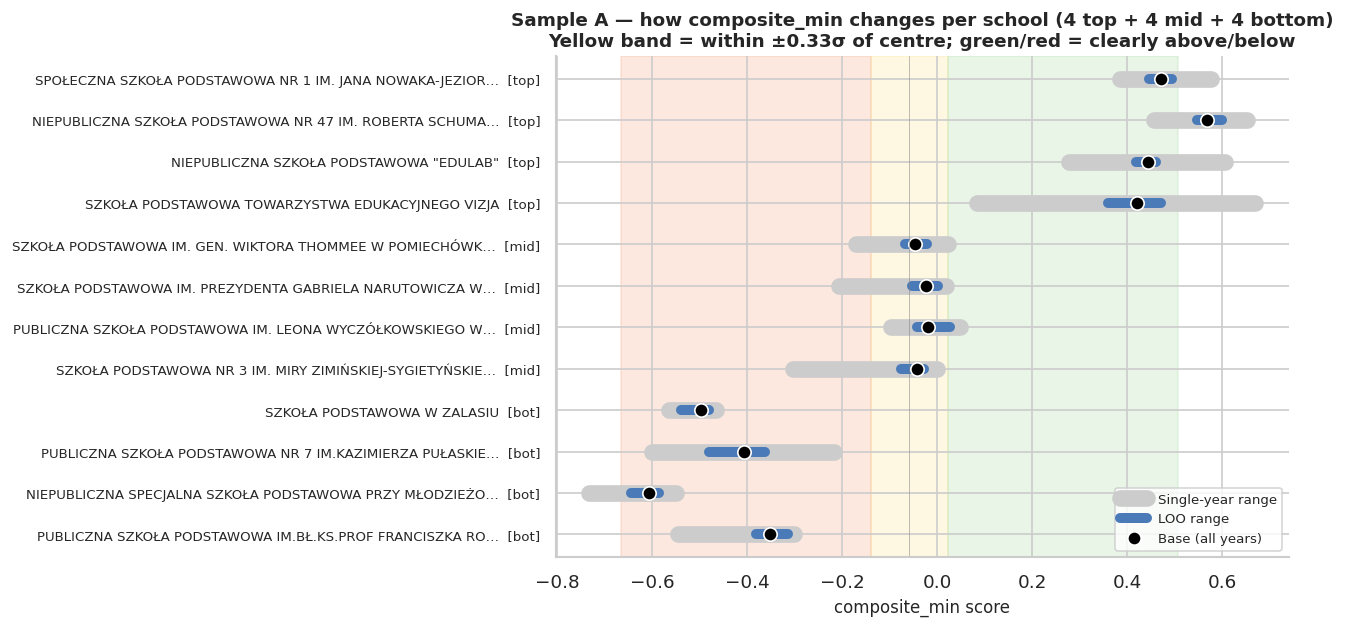

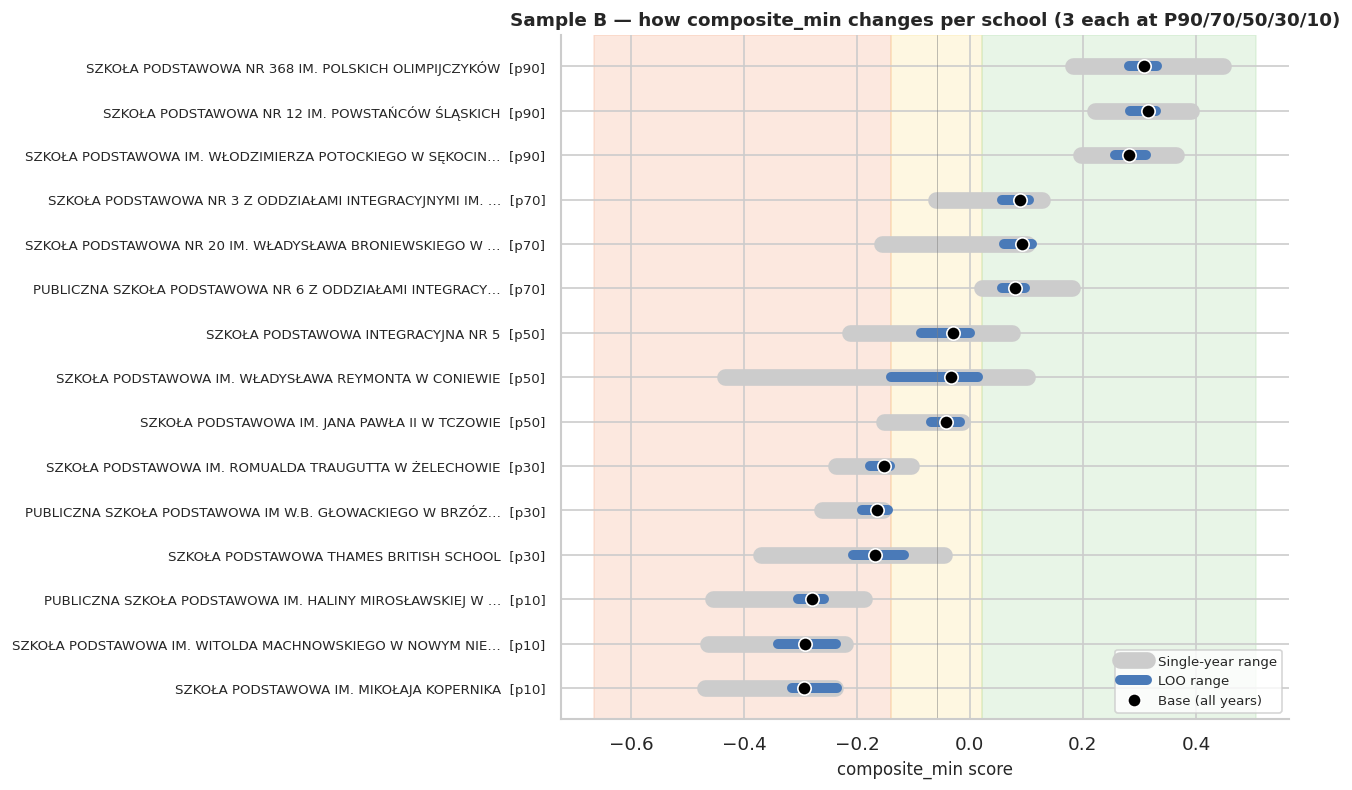

In [27]:
# ── Lollipop chart: level changes for each sample school ────────────────────
def lollipop_level(sample_df, title):
    fig, ax = plt.subplots(figsize=(11, max(4, 0.45 * len(sample_df))))

    y_positions = np.arange(len(sample_df))

    for y_pos, (_, row) in zip(y_positions, sample_df.iterrows()):
        rspo = row['rspo']
        comp_row = composite_folds[composite_folds['rspo'] == rspo].iloc[0]
        base = comp_row['base']
        loo_values = [comp_row[f'loo_excl_{y}'] for y in ALL_YEARS]
        single_values = [comp_row[f'single_{y}'] for y in ALL_YEARS]

        # Single-year range (widest)
        ax.plot([min(single_values), max(single_values)], [y_pos, y_pos],
                color='#cccccc', lw=10, solid_capstyle='round', label='_nolegend_')
        # LOO range (narrower)
        ax.plot([min(loo_values), max(loo_values)], [y_pos, y_pos],
                color='#4a7ab8', lw=6, solid_capstyle='round', label='_nolegend_')
        # Base score (small marker)
        ax.plot(base, y_pos, 'o', markerfacecolor='black',
                markeredgecolor='white', markersize=8, label='_nolegend_')

    # Legend handles
    ax.plot([], [], color='#cccccc', lw=10, solid_capstyle='round', label='Single-year range')
    ax.plot([], [], color='#4a7ab8', lw=6, solid_capstyle='round', label='LOO range')
    ax.plot([], [], 'o', markerfacecolor='black', markeredgecolor='white',
            markersize=8, label='Base (all years)')

    # Y axis labels
    labels = []
    for _, row in sample_df.iterrows():
        name = row['school_name']
        short_name = name[:55] + '…' if len(name) > 55 else name
        labels.append(f'{short_name}  [{row["_band"]}]')
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()  # top of sample at top of chart

    # Add coloured background bands for the colour classes (composite_min has its own σ + centre)
    s = sigma['composite_min']
    centre = centre_composite
    cp1, cp99 = np.percentile(scores['composite_min'], [1, 99])
    ax.axvspan(centre - 0.33 * s, centre + 0.33 * s, color='#fde08a', alpha=0.25, zorder=0)  # B medium
    ax.axvspan(centre + 0.33 * s, cp99,              color='#a6dba0', alpha=0.25, zorder=0)  # A good (to p99)
    ax.axvspan(cp1,              centre - 0.33 * s,  color='#f4a582', alpha=0.25, zorder=0)  # C weak (to p1)
    ax.axvline(centre, color='gray', lw=0.6, alpha=0.5)

    ax.set_xlabel('composite_min score', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()


lollipop_level(sample_a,
    'Sample A — how composite_min changes per school (4 top + 4 mid + 4 bottom)\n'
    'Yellow band = within ±0.33σ of centre; green/red = clearly above/below')
lollipop_level(sample_b,
    'Sample B — how composite_min changes per school (3 each at P90/70/50/30/10)')

### How school rank changes

Same schools, but now we show their **percentile rank** (1 = bottom, 100 = top).
Percentiles are used instead of raw rank because the rank denominator changes
between views (especially for single-year views where some schools might have
no data — though here, all sample schools have data in every year, so the
denominator stays constant).

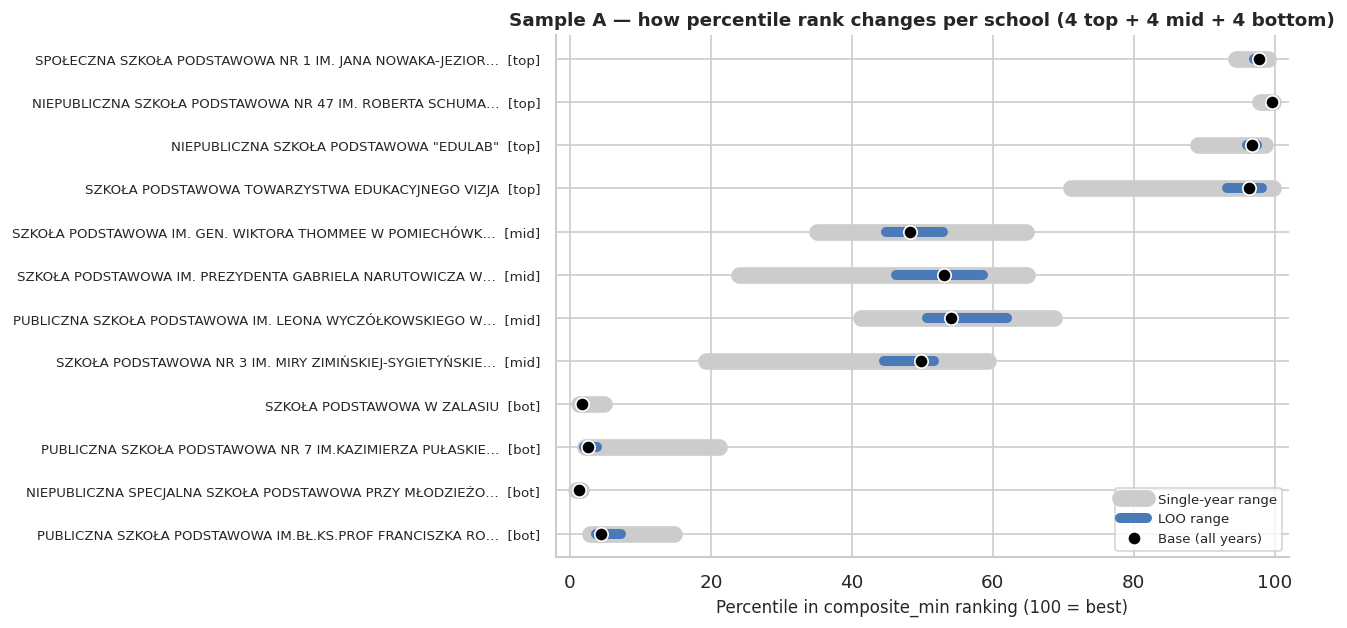

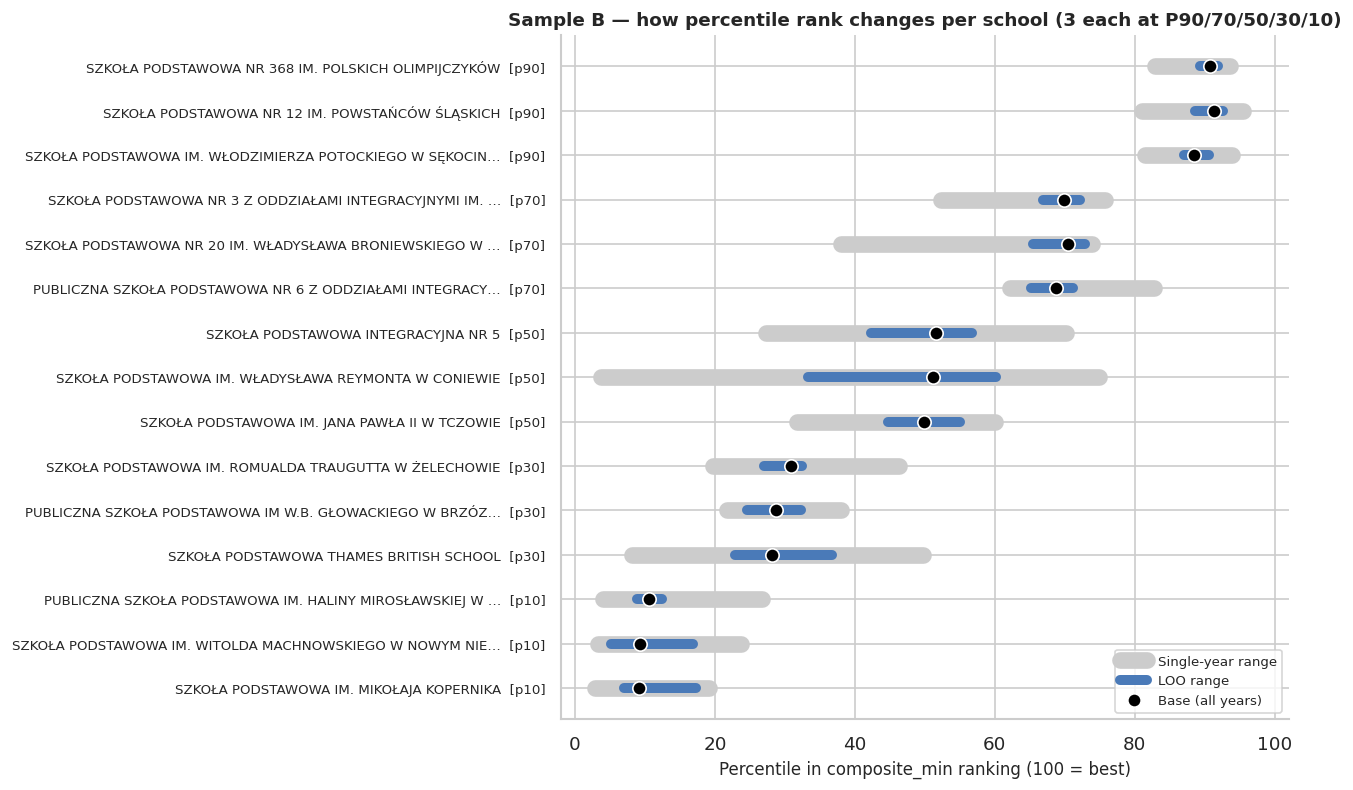

In [28]:
# ── Lollipop chart: rank (percentile) changes for each sample school ────────
def lollipop_rank(sample_df, title):
    fig, ax = plt.subplots(figsize=(11, max(4, 0.45 * len(sample_df))))

    y_positions = np.arange(len(sample_df))

    for y_pos, (_, row) in zip(y_positions, sample_df.iterrows()):
        rspo = row['rspo']
        pct_row = composite_pcts[composite_pcts['rspo'] == rspo].iloc[0]
        base_pct = pct_row['base']
        loo_pcts = [pct_row[f'loo_excl_{y}'] for y in ALL_YEARS]
        single_pcts = [pct_row[f'single_{y}'] for y in ALL_YEARS]

        ax.plot([min(single_pcts), max(single_pcts)], [y_pos, y_pos],
                color='#cccccc', lw=10, solid_capstyle='round', label='_nolegend_')
        ax.plot([min(loo_pcts), max(loo_pcts)], [y_pos, y_pos],
                color='#4a7ab8', lw=6, solid_capstyle='round', label='_nolegend_')
        ax.plot(base_pct, y_pos, 'o', markerfacecolor='black',
                markeredgecolor='white', markersize=8, label='_nolegend_')

    ax.plot([], [], color='#cccccc', lw=10, solid_capstyle='round', label='Single-year range')
    ax.plot([], [], color='#4a7ab8', lw=6, solid_capstyle='round', label='LOO range')
    ax.plot([], [], 'o', markerfacecolor='black', markeredgecolor='white',
            markersize=8, label='Base (all years)')

    labels = []
    for _, row in sample_df.iterrows():
        name = row['school_name']
        short_name = name[:55] + '…' if len(name) > 55 else name
        labels.append(f'{short_name}  [{row["_band"]}]')
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()

    ax.set_xlabel('Percentile in composite_min ranking (100 = best)', fontsize=10)
    ax.set_xlim(-2, 102)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()


lollipop_rank(sample_a,
    'Sample A — how percentile rank changes per school (4 top + 4 mid + 4 bottom)')
lollipop_rank(sample_b,
    'Sample B — how percentile rank changes per school (3 each at P90/70/50/30/10)')

### Population-wide view: how level and rank vary by base position

The lollipop charts show concrete schools. To see the pattern across the whole
population, we plot the **range of LOO and single-year scores** (max − min) against
the **base position**. Two pairs of scatters:

- **Level changes (top row)** — y-axis is the score range; x-axis is the base score
- **Rank changes (bottom row)** — y-axis is the percentile-rank range; x-axis is the base percentile

For each pair, the **left chart shows LOO range**, the **right shows single-year range**.
Single-year range is always larger because it uses only one year of data.

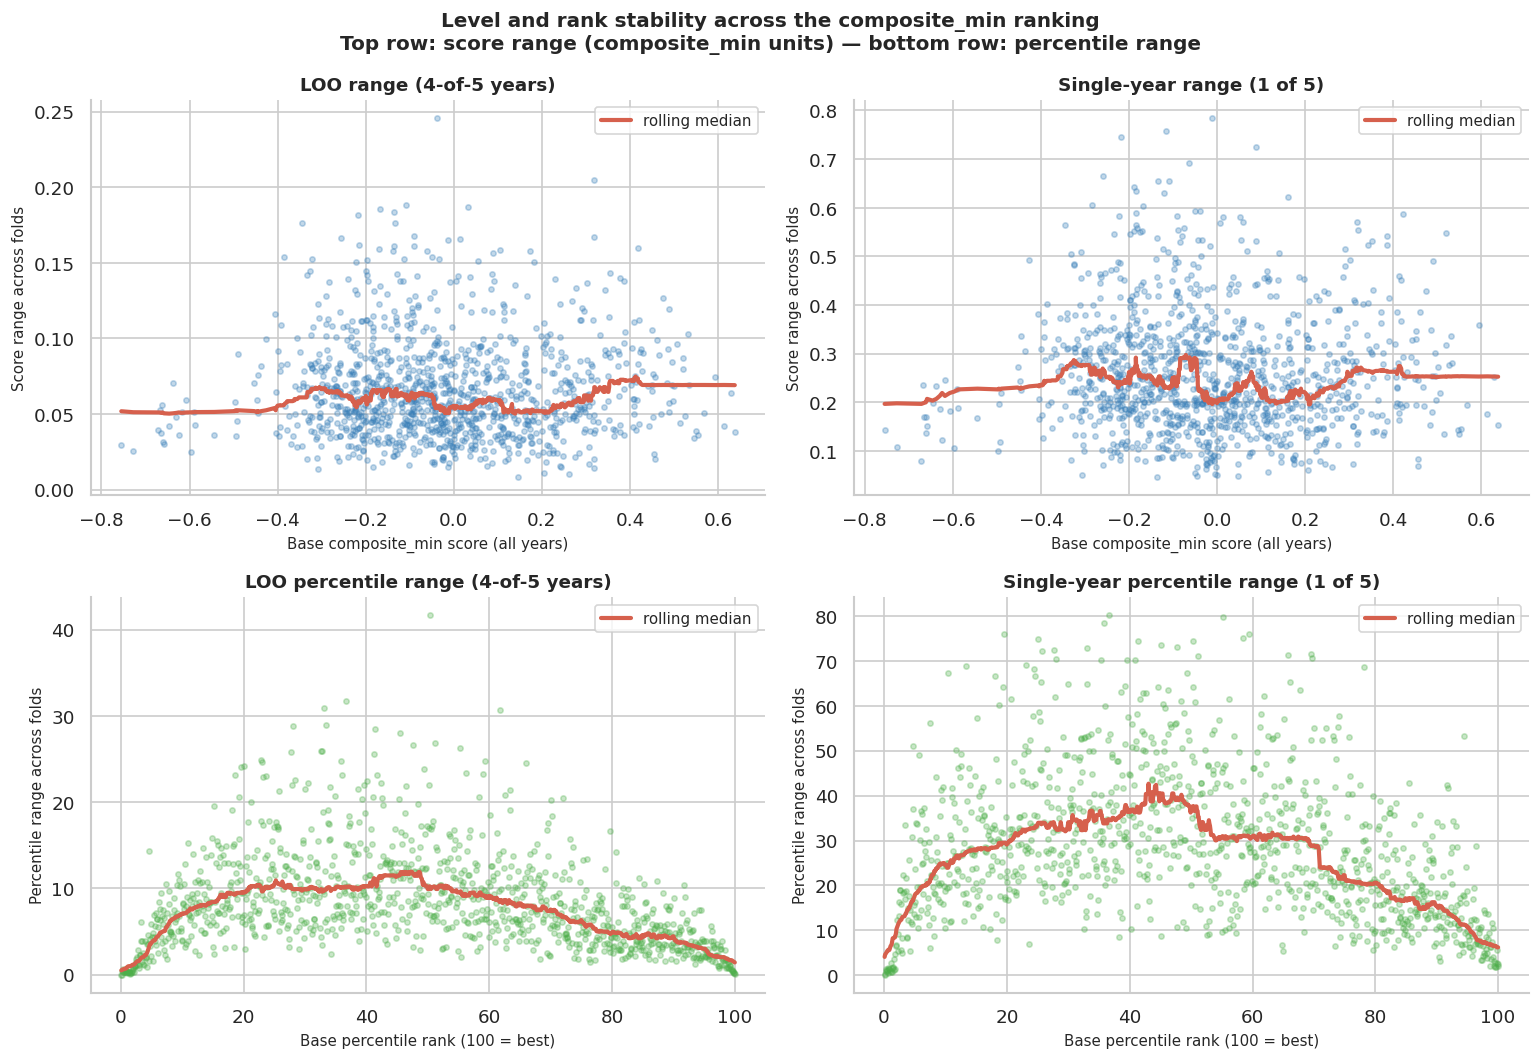

In [29]:
# ── Scatter plots: variation in level and rank vs base position ─────────────
loo_cols = [f'loo_excl_{y}' for y in ALL_YEARS]
single_cols = [f'single_{y}' for y in ALL_YEARS]

# Compute ranges for each school
scatter_data = composite_folds[['rspo', 'school_name', 'base']].copy()
scatter_data['loo_range'] = (
    composite_folds[loo_cols].max(axis=1) - composite_folds[loo_cols].min(axis=1)
)
scatter_data['single_range'] = (
    composite_folds[single_cols].max(axis=1) - composite_folds[single_cols].min(axis=1)
)
scatter_data['base_pct'] = composite_pcts['base']
scatter_data['loo_pct_range'] = (
    composite_pcts[loo_cols].max(axis=1) - composite_pcts[loo_cols].min(axis=1)
)
scatter_data['single_pct_range'] = (
    composite_pcts[single_cols].max(axis=1) - composite_pcts[single_cols].min(axis=1)
)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Top row: LEVEL changes (score range vs base score)
for ax, col, title in [
    (axes[0, 0], 'loo_range',    f'LOO range ({N_YEARS-1}-of-{N_YEARS} years)'),
    (axes[0, 1], 'single_range', f'Single-year range (1 of {N_YEARS})'),
]:
    ax.scatter(scatter_data['base'], scatter_data[col],
               alpha=0.3, s=10, color='#377eb8')
    sorted_df = scatter_data.sort_values('base')
    rolling = sorted_df[col].rolling(window=80, center=True, min_periods=20).median()
    ax.plot(sorted_df['base'], rolling, color='#d6604d', lw=2.5, label='rolling median')
    ax.set_xlabel('Base composite_min score (all years)', fontsize=9)
    ax.set_ylabel('Score range across folds', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

# Bottom row: RANK changes (percentile range vs base percentile)
for ax, col, title in [
    (axes[1, 0], 'loo_pct_range',    f'LOO percentile range ({N_YEARS-1}-of-{N_YEARS} years)'),
    (axes[1, 1], 'single_pct_range', f'Single-year percentile range (1 of {N_YEARS})'),
]:
    ax.scatter(scatter_data['base_pct'], scatter_data[col],
               alpha=0.3, s=10, color='#4daf4a')
    sorted_df = scatter_data.sort_values('base_pct')
    rolling = sorted_df[col].rolling(window=80, center=True, min_periods=20).median()
    ax.plot(sorted_df['base_pct'], rolling, color='#d6604d', lw=2.5, label='rolling median')
    ax.set_xlabel('Base percentile rank (100 = best)', fontsize=9)
    ax.set_ylabel('Percentile range across folds', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Level and rank stability across the composite_min ranking\n'
    'Top row: score range (composite_min units) — bottom row: percentile range',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.show()

#### Min / max vs base — direction, not just magnitude

The previous scatter shows the **range** (max − min) of folds, but doesn't say
whether the folds stray *up*, *down*, or both. Below we plot the actual minimum
and maximum fold scores against the base. The solid diagonal line (y = x) marks
where points would sit if min and max equaled the base — points below the
diagonal mean a fold pulled the score *down*; above means *up*.

The two bold curves are **rolling medians** (window = 20 schools) of the fold
minimum (dark red) and fold maximum (dark green) — they show the typical fold
extremes as the base score changes. Median is used rather than mean because the
median ignores outlier folds that would otherwise pull the line outside the
data cloud.

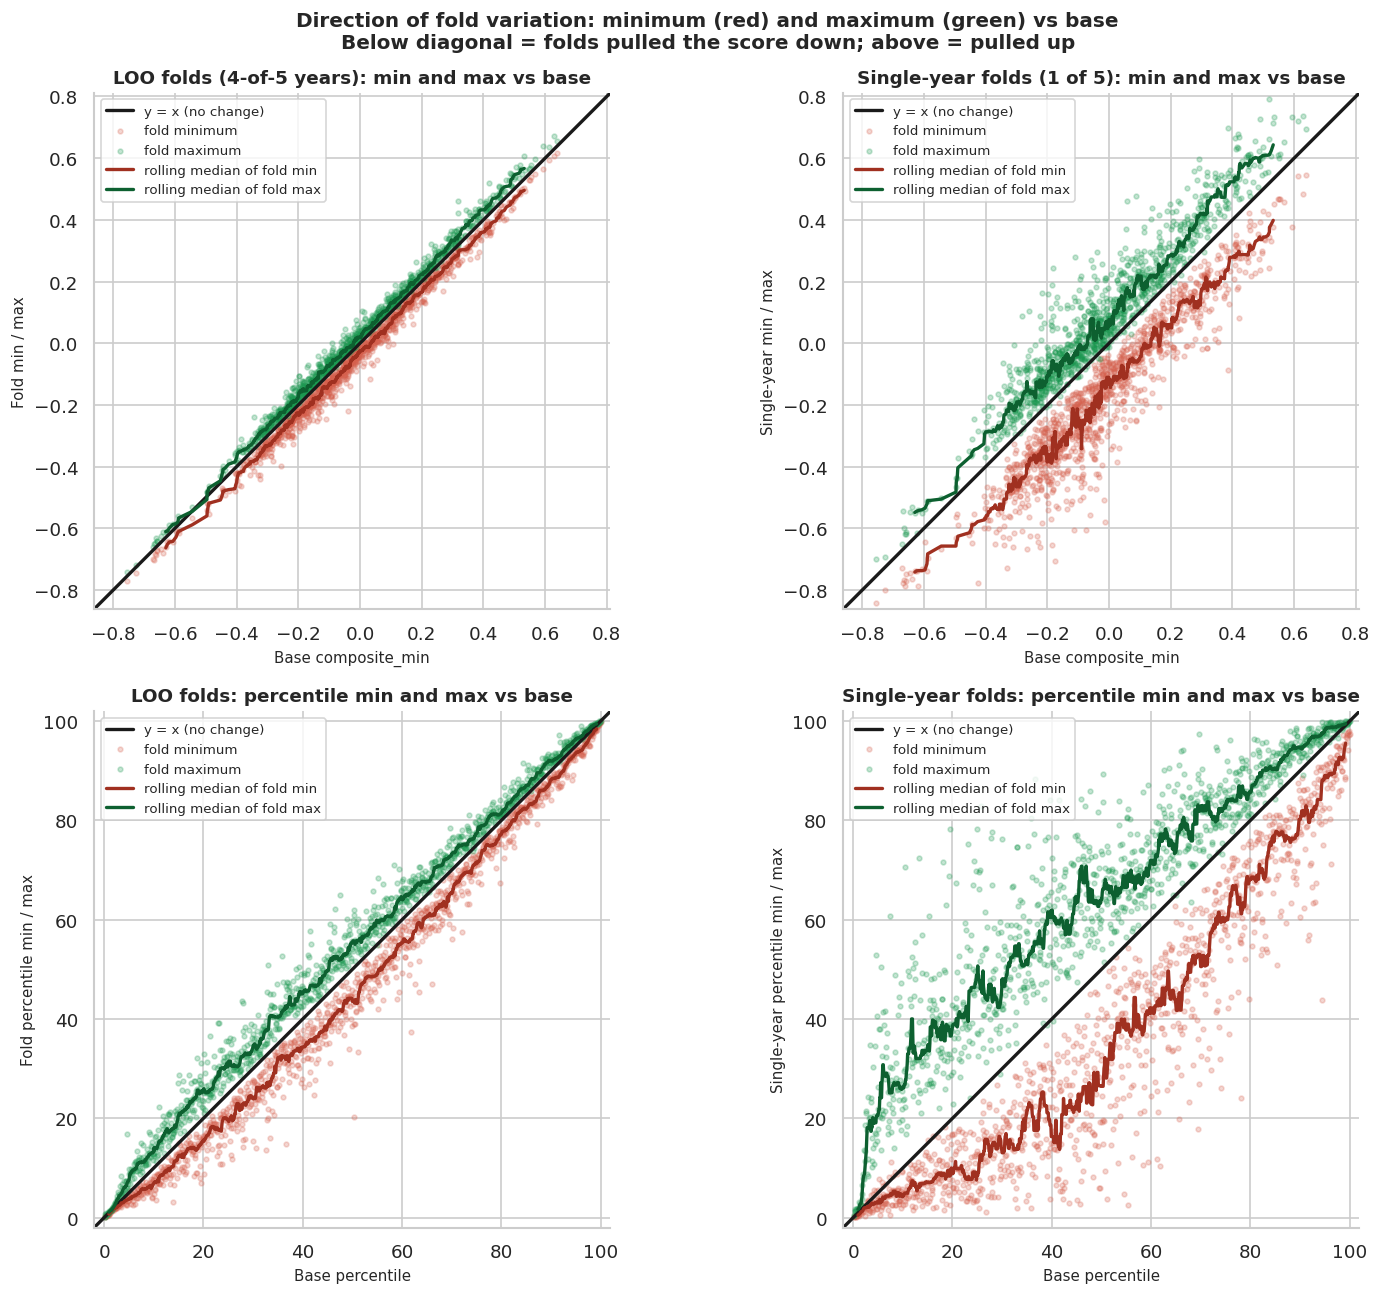

In [30]:
# ── Min / max of folds vs base score (and vs base percentile) ────────────────
scatter_data['loo_min'] = composite_folds[loo_cols].min(axis=1)
scatter_data['loo_max'] = composite_folds[loo_cols].max(axis=1)
scatter_data['single_min'] = composite_folds[single_cols].min(axis=1)
scatter_data['single_max'] = composite_folds[single_cols].max(axis=1)

scatter_data['loo_min_pct'] = composite_pcts[loo_cols].min(axis=1)
scatter_data['loo_max_pct'] = composite_pcts[loo_cols].max(axis=1)
scatter_data['single_min_pct'] = composite_pcts[single_cols].min(axis=1)
scatter_data['single_max_pct'] = composite_pcts[single_cols].max(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

# Helper: scatter with min (red) and max (green) versus base, with y=x diagonal
def scatter_min_max(ax, base_col, min_col, max_col, xlabel, ylabel, title, lims):
    ax.plot(lims, lims, 'k-', lw=2, label='y = x (no change)')
    ax.scatter(scatter_data[base_col], scatter_data[min_col],
               alpha=0.25, s=8, color='#d6604d', label='fold minimum')
    ax.scatter(scatter_data[base_col], scatter_data[max_col],
               alpha=0.25, s=8, color='#1a9850', label='fold maximum')
    # Rolling medians
    sorted_df = scatter_data.sort_values(base_col)
    # Rolling medians (window=20). Median chosen over mean because it ignores
    # outlier folds which would otherwise pull the line outside the data cloud.
    for col, color, label in [
        (min_col, '#a03020', 'rolling median of fold min'),
        (max_col, '#0d6030', 'rolling median of fold max'),
    ]:
        rolling = sorted_df[col].rolling(window=20, center=True, min_periods=20).median()
        ax.plot(sorted_df[base_col], rolling, color=color, lw=2, label=label)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.legend(fontsize=8, loc='upper left')
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_aspect('equal', adjustable='box')

# Determine score limits (composite_min)
score_lim = (
    min(scatter_data['base'].min(), scatter_data['loo_min'].min(),
        scatter_data['single_min'].min()) - 0.02,
    max(scatter_data['base'].max(), scatter_data['loo_max'].max(),
        scatter_data['single_max'].max()) + 0.02,
)
pct_lim = (-2, 102)

# Top row: LEVEL (raw composite_min values)
scatter_min_max(
    axes[0, 0], 'base', 'loo_min', 'loo_max',
    'Base composite_min', 'Fold min / max',
    f'LOO folds ({N_YEARS-1}-of-{N_YEARS} years): min and max vs base',
    score_lim,
)
scatter_min_max(
    axes[0, 1], 'base', 'single_min', 'single_max',
    'Base composite_min', 'Single-year min / max',
    f'Single-year folds (1 of {N_YEARS}): min and max vs base',
    score_lim,
)

# Bottom row: RANK (percentiles)
scatter_min_max(
    axes[1, 0], 'base_pct', 'loo_min_pct', 'loo_max_pct',
    'Base percentile', 'Fold percentile min / max',
    'LOO folds: percentile min and max vs base',
    pct_lim,
)
scatter_min_max(
    axes[1, 1], 'base_pct', 'single_min_pct', 'single_max_pct',
    'Base percentile', 'Single-year percentile min / max',
    'Single-year folds: percentile min and max vs base',
    pct_lim,
)

fig.suptitle(
    'Direction of fold variation: minimum (red) and maximum (green) vs base\n'
    'Below diagonal = folds pulled the score down; above = pulled up',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.show()

## 6. Export data to external map

The final step is to export school data into files that the external map app
can load. We export two formats:

- **JSON files** for the map application (loaded by the web frontend)
- **XLSX files** for analysts who want to slice and pivot the data in Excel

### What we export

For each of the 4 candidate metrics (`mean`, `median`, `diff_mean`,
`unit_norm_diff_mean`) we generate a separate file. The map exposes all 4 as a
toggle so users can compare; `unit_norm_diff_mean` is the default.

For each school × subject × metric we expose four **views**:
- **base** — score over all available years (the primary value shown on the map)
- **LOO** — score with one year excluded (one value per year)
- **single year** — score from one year alone (one value per year)
- **last k years** — score over the most recent k years (k from 2 to N − 1; this
  lets a parent ask *"has the school improved recently?"*)

Each view includes the score, the rank among schools with data in that view, and
the percentile.

### Output files

```
output/
├── schools-base.json                    # metadata + primary scores (~1 MB, loaded on map open)
├── schools-mean.json                    # all views, mean metric (~5 MB, on demand)
├── schools-median.json                  # all views, median metric
├── schools-diff_mean.json               # all views, diff_mean metric
├── schools-unit_norm_diff_mean.json     # all views, unit_norm_diff_mean (default)
├── schools-mean.xlsx                    # long-format Excel, includes administrative metadata
├── schools-median.xlsx
├── schools-diff_mean.xlsx
└── schools-unit_norm_diff_mean.xlsx
```

### Idempotence

Re-running the notebook with unchanged data should not modify output files,
so git doesn't see noise. The export step compares newly computed values with
the existing XLSX content; if equal (within `rtol=1e-6` for floats), nothing
is written.

`FORCE_REGENERATE = True` at the top forces regeneration regardless. The
xlsx metadata (created date) is otherwise written with the real generation time.

In [31]:
# ── Export configuration ─────────────────────────────────────────────────────
# Run-mode flags (FORCE_REGENERATE, WRITE_OUTPUT_FILES) are defined in the setup cell.

# Metrics to export (the 4 candidate metrics from the map toggle)
EXPORT_METRICS = ['mean', 'median', 'diff_mean', 'unit_norm_diff_mean']

# Subjects (3 core subjects + composite_min)
EXPORT_SUBJECTS = list(CORE_SUBJECTS) + ['composite_min']

print(f'FORCE_REGENERATE = {FORCE_REGENERATE}')
print(f'Output directory: {OUTPUT_DIR.resolve()}')
print(f'Metrics: {EXPORT_METRICS}')
print(f'Subjects: {EXPORT_SUBJECTS}')

FORCE_REGENERATE = False
Output directory: /home/kamil/Documents/github/compare-primary-schools-mazowieckie/output
Metrics: ['mean', 'median', 'diff_mean', 'unit_norm_diff_mean']
Subjects: ['polski', 'matematyka', 'angielski', 'composite_min']


In [32]:
# ── Helper: compare two DataFrames for semantic equality ─────────────────────
def dataframes_equal(df_new: pd.DataFrame, df_old: pd.DataFrame,
                      rtol: float = 1e-6, verbose: bool = True) -> bool:
    """Return True if two DataFrames are equal (floats compared with np.isclose).

    When verbose=True, prints what differs.
    """
    if df_new.shape != df_old.shape:
        if verbose:
            print(f'  shape differs: new={df_new.shape}, old={df_old.shape}')
        return False
    if list(df_new.columns) != list(df_old.columns):
        if verbose:
            new_cols = set(df_new.columns); old_cols = set(df_old.columns)
            print(f'  columns differ: only_new={new_cols - old_cols}, only_old={old_cols - new_cols}')
        return False

    df_new_reset = df_new.reset_index(drop=True)
    df_old_reset = df_old.reset_index(drop=True)
    for col in df_new_reset.columns:
        a, b = df_new_reset[col], df_old_reset[col]
        if a.dtype.kind == 'f' or b.dtype.kind == 'f':
            if not np.allclose(a.fillna(0), b.fillna(0), rtol=rtol, equal_nan=False) or \
               not (a.isna() == b.isna()).all():
                if verbose:
                    diff_mask = ~np.isclose(a.fillna(0), b.fillna(0), rtol=rtol) | (a.isna() != b.isna())
                    print(f'  column "{col}" differs in {diff_mask.sum()} rows; '
                          f'first diff at row {diff_mask.idxmax()}: '
                          f'new={a[diff_mask.idxmax()]}, old={b[diff_mask.idxmax()]}')
                return False
        else:
            if not a.equals(b):
                if verbose:
                    diff_mask = a.fillna('') != b.fillna('')
                    print(f'  column "{col}" differs in {diff_mask.sum()} rows; '
                          f'first diff at row {diff_mask.idxmax()}: '
                          f'new={a[diff_mask.idxmax()]!r}, old={b[diff_mask.idxmax()]!r}')
                return False
    return True


def commit_export(path, *, unchanged, write, detail=''):
    """Standard skip/write/suppress decision for one export file.

    unchanged: result of the caller's own equality check against the existing file.
    write:     zero-arg callback that performs the actual write.
    detail:    optional text appended to the 'wrote' message (e.g. a row count).

    Centralises the two run-config flags so the data-protection logic lives in one
    place: FORCE_REGENERATE forces a write; WRITE_OUTPUT_FILES gates writing at all.
    Returns 'skipped' | 'wrote' | 'suppressed'.
    """
    if not FORCE_REGENERATE and unchanged:
        print(f'  {path.name}: no changes, skipping')
        return 'skipped'
    if not WRITE_OUTPUT_FILES:
        print(f'  {path.name}: changed but WRITE_OUTPUT_FILES=False — not writing')
        return 'suppressed'
    write()
    suffix = f', {detail}' if detail else ''
    print(f'  {path.name}: wrote {path.stat().st_size / 1024:.1f} KB{suffix}')
    return 'wrote'


### Compute alternative views

For each (school, subject, metric) we compute:
- base (all years, weighted mean)
- N LOO scores (one per excluded year)
- N single-year scores (one per year)
- N − 2 last-k scores (k from 2 to N − 1)

Plus rank and percentile within each view's population (schools with data in
that view's year set).

In [33]:
# ── Compute base, LOO, single-year, last-k scores for every metric/subject ──
LAST_K_VALUES = list(range(2, len(ALL_YEARS)))  # k = 2, 3, ..., N-1

# View definitions: (view_kind, view_param, set_of_years_used)
view_defs = []
view_defs.append(('base', None, set(ALL_YEARS)))
for excluded_year in ALL_YEARS:
    view_defs.append(('loo', excluded_year, set(ALL_YEARS) - {excluded_year}))
for single_year in ALL_YEARS:
    view_defs.append(('single_year', single_year, {single_year}))
for k in LAST_K_VALUES:
    last_k_years = set(ALL_YEARS[-k:])
    view_defs.append(('last_k', k, last_k_years))


def weighted_mean(values, weights):
    values = np.asarray(values); weights = np.asarray(weights)
    valid = ~(np.isnan(values) | np.isnan(weights)) & (weights > 0)
    if not valid.any() or weights[valid].sum() == 0:
        return np.nan
    return (values[valid] * weights[valid]).sum() / weights[valid].sum()


def arithmetic_mean(values, weights=None):
    """Equal-weight mean across years, ignoring nan."""
    values = np.asarray(values)
    valid = ~np.isnan(values)
    if not valid.any():
        return np.nan
    return values[valid].mean()


# Aggregation method depends on the metric:
#   baseline metrics (mean, median) → simple arithmetic mean across years
#       (easiest to understand for users who prefer a plain baseline)
#   advanced metrics (diff_mean, unit_norm_diff_mean) → weighted by n_students
#       (more evidence from larger cohorts, as established by the LOO analysis)
AGGREGATION_BY_METRIC = {
    'mean':                arithmetic_mean,
    'median':              arithmetic_mean,
    'diff_mean':           weighted_mean,
    'unit_norm_diff_mean': weighted_mean,
}


def compute_school_scores(metric: str, subject: str, year_subset: set) -> dict:
    """For each school, aggregate metric_{subject} over the year subset using the
    metric's designated aggregation method. Returns {rspo: score} for schools with
    at least one valid year in the subset."""
    aggregate = AGGREGATION_BY_METRIC[metric]
    sub = df[df['year'].isin(year_subset)]
    n_col = f'n_{subject}'
    m_col = f'{metric}_{subject}'
    result = {}
    for rspo, group in sub.groupby('rspo'):
        n_vals = group[n_col].values
        m_vals = group[m_col].values
        score = aggregate(m_vals, n_vals)
        if not np.isnan(score):
            result[rspo] = score
    return result


# A school's valid views depend on which years it actually has data for:
#   - base: all the school's years
#   - loo: exclude one of the school's OWN years (skip years it never had)
#   - single_year: each year the school has
#   - last_k: most recent k of the school's years, for k = 2..(n_years - 1)
# This avoids meaningless folds (e.g. "exclude 2021" for a school with no 2021 data,
# which would just copy the base score).
#
# We compute per (metric, subject) by grouping the data once and deriving each
# school's own view set.

def school_years_for_subject(metric, subject):
    """Return {rspo: {year: (n_students, metric_value)}} for valid rows."""
    n_col = f'n_{subject}'
    m_col = f'{metric}_{subject}'
    out = {}
    for rspo, group in df.groupby('rspo'):
        year_map = {}
        for _, row in group.iterrows():
            n_val = row[n_col]; m_val = row[m_col]
            if pd.notna(n_val) and n_val > 0 and pd.notna(m_val):
                year_map[int(row['year'])] = (n_val, m_val)
        if year_map:
            out[rspo] = year_map
    return out


def aggregate_years(metric, year_map, years_to_use):
    """Aggregate the metric over the given years using the metric's method.
    Returns (score, n_students) where n_students is the MEDIAN number of students
    per year across the years used — i.e. the school's typical cohort size in this
    view. Median (not sum or mean) is used because: (1) summing across overlapping
    views is meaningless and the value would drift upward as years accumulate;
    (2) the median is robust to anomalous years — e.g. a home-schooling-linked
    school that grew from 5 to 1200 students should report its typical size, not a
    mean dragged by the extremes (~16% of schools have mean/median diverging by
    >5 students). Rounding is needed either way for an even number of years."""
    aggregate = AGGREGATION_BY_METRIC[metric]
    vals = np.array([year_map[y][1] for y in years_to_use if y in year_map])
    weights = np.array([year_map[y][0] for y in years_to_use if y in year_map])
    if len(vals) == 0:
        return np.nan, 0
    n_students = int(round(np.median(weights)))
    return aggregate(vals, weights), n_students


print(f'Computing per-school views × {len(EXPORT_METRICS)} metrics × {len(EXPORT_SUBJECTS)} subjects')
print('Schools with at least 2 years of data:', (df.groupby('rspo')['year'].nunique() >= 2).sum())

# view_results: {(metric, subject, view_kind, view_param): {rspo: score}}
# view_n:       {(metric, subject, view_kind, view_param): {rspo: n_students}}
#   For the 3 core subjects, n_students is the total students of THAT subject over
#   the view's years. For composite_min, it is the n_students of the subject that
#   produced the minimum (so a validator knows which subject and how many students
#   the composite value came from).
view_results = {}
view_n = {}

for metric in EXPORT_METRICS:
    # First compute per-subject scores
    subject_year_maps = {s: school_years_for_subject(metric, s) for s in CORE_SUBJECTS}

    for subject in CORE_SUBJECTS:
        year_maps = subject_year_maps[subject]
        for rspo, year_map in year_maps.items():
            school_years = sorted(year_map.keys())
            n_years = len(school_years)

            def store(view_kind, view_param, years_to_use):
                score, n_total = aggregate_years(metric, year_map, years_to_use)
                if not np.isnan(score):
                    view_results.setdefault((metric, subject, view_kind, view_param), {})[rspo] = score
                    view_n.setdefault((metric, subject, view_kind, view_param), {})[rspo] = n_total

            # base
            store('base', None, school_years)

            # loo — only for the school's own years, and only if it has >= 2 years
            if n_years >= 2:
                for excluded in school_years:
                    remaining = [y for y in school_years if y != excluded]
                    store('loo', excluded, remaining)

            # single_year — each of the school's years
            for year in school_years:
                store('single_year', year, [year])

            # last_k — most recent k of the school's years, k = 2..(n_years - 1)
            for k in range(2, n_years):
                store('last_k', k, school_years[-k:])

    # composite_min: min across the 3 subjects, per (view_kind, view_param), per school.
    # A school appears in a composite view only if it has all 3 subjects for that view.
    # n_students for composite = n of the subject that gave the minimum.
    composite_keys = set()
    for (m, s, vk, vp) in view_results:
        if m == metric and s in CORE_SUBJECTS:
            composite_keys.add((vk, vp))

    for vk, vp in composite_keys:
        per_subject_score = {
            s: view_results.get((metric, s, vk, vp), {}) for s in CORE_SUBJECTS
        }
        per_subject_n = {
            s: view_n.get((metric, s, vk, vp), {}) for s in CORE_SUBJECTS
        }
        common_rspos = (set(per_subject_score['polski'])
                        & set(per_subject_score['matematyka'])
                        & set(per_subject_score['angielski']))
        composite_score = {}
        composite_n = {}
        for rspo in common_rspos:
            # find the subject with the minimum score
            min_subject = min(CORE_SUBJECTS, key=lambda s: per_subject_score[s][rspo])
            composite_score[rspo] = per_subject_score[min_subject][rspo]
            composite_n[rspo] = per_subject_n[min_subject][rspo]
        if composite_score:
            view_results[(metric, 'composite_min', vk, vp)] = composite_score
            view_n[(metric, 'composite_min', vk, vp)] = composite_n

print(f'Total view computations: {len(view_results):,}')

Computing per-school views × 4 metrics × 4 subjects
Schools with at least 2 years of data: 1662


Total view computations: 224


In [34]:
# ── For each view: compute rank and percentile within the view's population ──
# Higher score = better rank (rank 1 = best).
view_records = []  # one record per (rspo, metric, subject, view_kind, view_param)
for (metric, subject, view_kind, view_param), score_map in view_results.items():
    if not score_map:
        continue
    rspos = list(score_map.keys())
    scores_arr = np.array([score_map[r] for r in rspos])
    n_in_view = len(scores_arr)
    n_students_map = view_n.get((metric, subject, view_kind, view_param), {})
    # rank 1 = highest score (descending)
    ranks = stats.rankdata(-scores_arr, method='min').astype(int)
    # percentile: ascending rank / total × 100
    pcts = stats.rankdata(scores_arr, method='average') / n_in_view * 100
    for rspo, sc, rk, pc in zip(rspos, scores_arr, ranks, pcts):
        view_records.append({
            'rspo': rspo,
            'metric': metric,
            'subject': subject,
            'view_kind': view_kind,
            'view_param': view_param,
            'score': sc,
            'rank_overall': int(rk),
            'pct_overall': pc,
            'n_in_view': n_in_view,
            'n_students': int(n_students_map.get(rspo, 0)),
        })

views_df = pd.DataFrame(view_records)
print(f'views_df shape: {views_df.shape}')
print(f'  unique schools: {views_df["rspo"].nunique():,}')
print(f'  unique metrics: {views_df["metric"].nunique()}')
print(f'  unique subjects: {views_df["subject"].nunique()}')
print(f'  unique view_kinds: {sorted(views_df["view_kind"].unique())}')

views_df shape: (331760, 10)
  unique schools: 1,720
  unique metrics: 4
  unique subjects: 4
  unique view_kinds: ['base', 'last_k', 'loo', 'single_year']


In [35]:
# ── Build per-school metadata (one row per school) ───────────────────────────
# Use most recent year's address for each school (schools sometimes relocate).
# Sort by (year desc, rspo) so drop_duplicates is deterministic regardless of the
# upstream row order — keeps the displayed examples stable between runs.
df_recent = (
    df.sort_values(['year', 'rspo'], ascending=[False, True])
      .drop_duplicates('rspo', keep='first')
)

school_meta = (
    df_recent.set_index('rspo')
    [['school_name', 'is_public', 'miejscowosc', 'ulica_nr', 'powiat', 'gmina', 'typ_gminy']]
    .copy()
)
school_meta['n_years'] = df.groupby('rspo')['year'].nunique()
school_meta = school_meta.reset_index().sort_values('rspo').reset_index(drop=True)

print(f'school_meta rows: {len(school_meta):,}')
display(school_meta.head(3))

school_meta rows: 1,720


,rspo,school_name,is_public,miejscowosc,ulica_nr,powiat,gmina,typ_gminy,n_years
0,2880,PUBLICZNA SZKOŁA PODSTAWOWA IM. JANA BRZECHWY ...,Tak,Słupica,84,Radomski,Jedlnia-Letnisko,Obszar wiejski,4
1,2970,NIEPUBLICZNA SZKOŁA PODSTAWOWA W GOŁĄBKU,Nie,Gołąbek,ul. Szkolna 26,Siedlecki,Skórzec,Gmina wiejska,2
2,2985,SZKOŁA PODSTAWOWA W LIPNIE,Tak,Lipno,25,Łosicki,Platerów,Gmina wiejska,1


### Export `schools-base.json`

This is the small file loaded immediately when the map opens. It contains
metadata for every school plus the primary score (`unit_norm_diff_mean`)
for each subject plus `composite_min`.

**Coordinates.** The map needs latitude/longitude to place each school marker.
The OKE data does not include coordinates, so they are geocoded separately by
`scripts/geocode_schools.py` (using OpenStreetMap's Nominatim) into
`data/school_coords.csv`. This export reads that cache and attaches `lat`/`lon`
to each school. Coordinates are **optional** — if the cache is missing or a
school isn't in it, `lat`/`lon` are `null` and the export reports how many
schools lack coordinates. Run the geocoding script after adding new schools.

In [36]:
# ── Export schools-base.json (metadata + base scores for ALL metrics) ────────

# Base score/rank/pct for EVERY metric × subject (Option A), so the frontend can
# switch metric and filter by value without downloading the large per-metric files.
# Structure: by_school[rspo][metric][subject] = {score, rank, pct}
by_school = {}
base_rows = views_df[views_df['view_kind'] == 'base']
for _, row in base_rows.iterrows():
    rspo = int(row['rspo'])
    by_school.setdefault(rspo, {}).setdefault(row['metric'], {})[row['subject']] = {
        'score': round(float(row['score']), 4),
        'rank':  int(row['rank_overall']),
        'pct':   round(float(row['pct_overall']), 1),
    }

# Load geocoded coordinates (optional). Geocoding is done by a separate script
# (scripts/geocode_schools.py) writing data/school_coords.csv. Schools without
# coordinates are still exported (lat/lon null) and reported below.
coords_path = Path('../data/school_coords.csv')
coords_by_rspo = {}
if coords_path.exists():
    coords_df = pd.read_csv(coords_path)
    for _, c in coords_df.iterrows():
        if pd.notna(c['latitude']) and pd.notna(c['longitude']):
            coords_by_rspo[int(c['rspo'])] = (float(c['latitude']), float(c['longitude']))
    print(f'Loaded coordinates for {len(coords_by_rspo):,} schools from {coords_path.name}')
else:
    print(f'No coordinate file at {coords_path} — exporting without lat/lon. '
          f'Run scripts/geocode_schools.py to generate it.')

# Build the schools list
schools_base = []
schools_without_coords = []
for _, m in school_meta.iterrows():
    rspo = int(m['rspo'])
    if rspo not in by_school:
        continue
    lat, lon = coords_by_rspo.get(rspo, (None, None))
    if lat is None:
        schools_without_coords.append((rspo, str(m['school_name']),
                                        str(m['miejscowosc']), str(m['ulica_nr'])))
    schools_base.append({
        'rspo':        rspo,
        'name':        str(m['school_name']),
        'is_public':   str(m['is_public']) if pd.notna(m['is_public']) else None,
        'n_years':     int(m['n_years']),
        'miejscowosc': str(m['miejscowosc']) if pd.notna(m['miejscowosc']) else None,
        'ulica_nr':    str(m['ulica_nr']) if pd.notna(m['ulica_nr']) else None,
        'gmina':       str(m['gmina']) if pd.notna(m['gmina']) else None,
        'powiat':      str(m['powiat']) if pd.notna(m['powiat']) else None,
        'lat':         lat,
        'lon':         lon,
        # scores[metric][subject] = {score, rank, pct}
        'scores':      by_school[rspo],
    })

# Report schools missing coordinates
if schools_without_coords:
    print(f'\n{len(schools_without_coords):,} schools have no coordinates. Examples:')
    for rspo, name, miejsc, ulica in schools_without_coords[:5]:
        print(f'  rspo={rspo}: {name} ({miejsc}, {ulica})')
elif coords_by_rspo:
    print('\nAll exported schools have coordinates.')

# ── Colour-scale parameters (sigma + centre) PER metric, per subject ─────────
# For each metric, per-subject scores are centred at 0 with sigma = std across
# schools; EXCEPT the 'mean' and 'median' metrics, whose raw scores are on the
# 0–100 scale, so they are centred at the voivodeship mean of school scores.
# composite_min always uses its own empirical mean as the centre.
def compute_sigma_and_centre(metric):
    """Return (sigma_dict, centre_dict) over EXPORT_SUBJECTS for one metric."""
    sigma_d, centre_d = {}, {}
    metric_base = views_df[(views_df['metric'] == metric) & (views_df['view_kind'] == 'base')]
    for subject in EXPORT_SUBJECTS:
        vals = metric_base[metric_base['subject'] == subject]['score'].dropna()
        sigma_d[subject] = round(float(vals.std()), 4)
        if subject == 'composite_min':
            # composite always centres on its own empirical mean
            centre_d[subject] = round(float(vals.mean()), 4)
        elif metric in ('mean', 'median'):
            # raw 0–100 scale: centre on the mean of school scores
            centre_d[subject] = round(float(vals.mean()), 4)
        else:
            # diff-based metrics are already centred at 0 by construction
            centre_d[subject] = 0.0
    return sigma_d, centre_d


sigma_by_metric = {}
centre_by_metric = {}
for metric in EXPORT_METRICS:
    s_d, c_d = compute_sigma_and_centre(metric)
    sigma_by_metric[metric] = s_d
    centre_by_metric[metric] = c_d

# ── Slider ranges per metric (config for the map's value filter) ─────────────
# p1/p99 are robust default slider ends; min/max are hard limits.
slider_ranges = {}
for metric in EXPORT_METRICS:
    metric_base = views_df[(views_df['metric'] == metric) & (views_df['view_kind'] == 'base')]
    # use composite_min as the representative distribution for the slider
    vals = metric_base[metric_base['subject'] == 'composite_min']['score'].dropna()
    lo, hi = float(vals.min()), float(vals.max())
    p1, p99 = float(vals.quantile(0.01)), float(vals.quantile(0.99))
    span = hi - lo
    step = round(span / 100, 4) if span > 0 else 0.01
    slider_ranges[metric] = {
        'min':  round(lo, 4),
        'max':  round(hi, 4),
        'p1':   round(p1, 4),
        'p99':  round(p99, 4),
        'step': step,
    }

base_payload = {
    'metadata': {
        'generated_at':  datetime.now().isoformat(timespec='seconds'),
        'default_metric': PRIMARY_METRIC,
        'metrics':       EXPORT_METRICS,
        'subjects':      EXPORT_SUBJECTS,
        'years_in_data': [int(y) for y in ALL_YEARS],
        'sigma':         sigma_by_metric,        # [metric][subject]
        'sigma_centre':  centre_by_metric,       # [metric][subject]
        'slider_ranges': slider_ranges,          # [metric] -> {min,max,p1,p99,step}
    },
    'schools': schools_base,
}

base_path = DOCS_DATA_DIR / 'schools-base.json'


def json_payloads_equal(new_payload: dict, path: Path) -> bool:
    """Compare new payload with existing JSON file, ignoring metadata.generated_at."""
    if not path.exists():
        return False
    try:
        old_payload = json.loads(path.read_text())
    except Exception:
        return False

    def strip_timestamp(p):
        p = dict(p)
        if 'metadata' in p and isinstance(p['metadata'], dict):
            md = dict(p['metadata'])
            md.pop('generated_at', None)
            p['metadata'] = md
        return p

    return strip_timestamp(new_payload) == strip_timestamp(old_payload)


commit_export(
    base_path,
    unchanged=json_payloads_equal(base_payload, base_path),
    write=lambda: base_path.write_text(json.dumps(base_payload, indent=2, ensure_ascii=False)),
    detail=f'{len(schools_base):,} schools',
)

Loaded coordinates for 1,708 schools from school_coords.csv

12 schools have no coordinates. Examples:
  rspo=3798: SZKOŁA PODSTAWOWA IM. FRYDERYKA CHOPINA W KSIĄŻENICACH (Książenice, al. E. Marylskiego 3)
  rspo=4048: SZKOŁA PODSTAWOWA NR 1 IM. HENRYKA SIENKIEWICZA (Grodzisk Mazowiecki, ul. W. Bartniaka 13A)
  rspo=6164: SZKOŁA PODSTAWOWA NR 2 IM. M. KONOPNICKIEJ (Grodzisk Mazowiecki, ul. W. Westfala 3)
  rspo=34835: SZKOŁA PODSTAWOWA NR 1 IM. BRACI JEZIOROWSKICH W PŁOCKU (Płock, inne Pasaż Vuka Karadzica 1)
  rspo=54139: SZKOŁA PODSTAWOWA NR 173 IM. GÓRNIKÓW POLSKICH (Warszawa, inne Trakt Brzeski 18)


  schools-base.json: no changes, skipping


'skipped'

### Export `schools-{metric}.json` × 4

For each of the 4 candidate metrics, a separate file with all alternative views
for every school and every subject. Map loads these on-demand when the user
clicks "show history" or switches metric.

In [37]:
# ── Export schools-{metric}.json for each metric ────────────────────────────
def cell_payload(row):
    return {
        'score': round(float(row['score']), 4),
        'rank':  int(row['rank_overall']),
        'pct':   round(float(row['pct_overall']), 1),
    }


def view_param_key(view_kind, view_param):
    """JSON-safe string key for a view's parameter."""
    if view_kind == 'base':
        return None  # base has no parameter — stored as flat object, not nested dict
    if pd.isna(view_param):
        return ''
    # Years and k values are integers; coerce
    try:
        return str(int(float(view_param)))
    except (TypeError, ValueError):
        return str(view_param)


for metric in EXPORT_METRICS:
    metric_views = views_df[views_df['metric'] == metric]

    # Build {rspo: {subject: {view_kind: ... }}}
    # For view_kind = 'base', the value is a flat {score, rank, pct} object.
    # Otherwise it is {param_key: {score, rank, pct}}.
    metric_by_school = {}
    for _, row in metric_views.iterrows():
        rspo = int(row['rspo'])
        subject = row['subject']
        view_kind = row['view_kind']

        if rspo not in metric_by_school:
            metric_by_school[rspo] = {}
        if subject not in metric_by_school[rspo]:
            metric_by_school[rspo][subject] = {}

        if view_kind == 'base':
            metric_by_school[rspo][subject]['base'] = cell_payload(row)
        else:
            if view_kind not in metric_by_school[rspo][subject]:
                metric_by_school[rspo][subject][view_kind] = {}
            param_key = view_param_key(view_kind, row['view_param'])
            metric_by_school[rspo][subject][view_kind][param_key] = cell_payload(row)

    # JSON requires string dict keys at top level
    schools_str_keys = {str(rspo): data for rspo, data in metric_by_school.items()}

    payload = {
        'metadata': {
            'generated_at': datetime.now().isoformat(timespec='seconds'),
            'metric':       metric,
            'years_in_data': [int(y) for y in ALL_YEARS],
        },
        'schools': schools_str_keys,
    }

    out_path = DOCS_DATA_DIR / f'schools-{metric}.json'
    commit_export(
        out_path,
        unchanged=json_payloads_equal(payload, out_path),
        write=lambda: out_path.write_text(json.dumps(payload, indent=1, ensure_ascii=False)),
    )

  schools-mean.json: no changes, skipping


  schools-median.json: no changes, skipping


  schools-diff_mean.json: no changes, skipping


  schools-unit_norm_diff_mean.json: no changes, skipping


### Export `schools-{metric}.xlsx` × 4

Long-format Excel for analysts. One row per (school, subject, view).
Includes administrative metadata (powiat, gmina, typ_gminy) for filtering and pivots.

Idempotence check: if the existing file's data is equal to the new data
(within `rtol=1e-6` for floats), the file is not rewritten.

In [38]:
# ── Export schools-{metric}.xlsx for each metric ────────────────────────────
EXPECTED_XLSX_COLUMNS = [
    'rspo', 'school_name', 'miejscowosc', 'ulica_nr',
    'powiat', 'gmina', 'typ_gminy', 'is_public', 'n_years',
    'metric', 'subject', 'view_kind', 'view_param',
    'score', 'rank_overall', 'pct_overall', 'n_in_view', 'n_students',
]


def build_long_frame_for_metric(metric: str) -> pd.DataFrame:
    metric_views = views_df[views_df['metric'] == metric].copy()
    # Add metadata columns
    merged = metric_views.merge(school_meta, on='rspo', how='left')
    # Convert view_param to string for consistent type (None → empty)
    def _view_param_str(v):
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return ''
        try:
            return str(int(float(v)))
        except (TypeError, ValueError):
            return str(v)
    merged['view_param'] = merged['view_param'].apply(_view_param_str)
    # Order columns and rows
    merged = merged[EXPECTED_XLSX_COLUMNS]
    merged = merged.sort_values(['rspo', 'subject', 'view_kind', 'view_param']).reset_index(drop=True)
    return merged


def build_legend_frame(metric: str) -> pd.DataFrame:
    """A human-readable legend sheet describing the metric, aggregation and columns."""
    aggregation = ('arithmetic mean across years (equal weight per year)'
                   if metric in ('mean', 'median')
                   else 'weighted mean across years (weighted by number of students)')
    rows = [
        ('FILE', f'schools-{metric}.xlsx'),
        ('metric', metric),
        ('aggregation across years', aggregation),
        ('', ''),
        ('COLUMN', 'MEANING'),
        ('rspo', 'Unique school identifier (stable across years)'),
        ('school_name', 'School name'),
        ('miejscowosc', 'Town/locality'),
        ('ulica_nr', 'Street and number'),
        ('powiat', 'County (administrative)'),
        ('gmina', 'Municipality (administrative)'),
        ('typ_gminy', 'Municipality type (urban/rural/urban-rural)'),
        ('is_public', 'Tak = public school, Nie = private/non-public'),
        ('n_years', 'Number of years the school has data in the dataset'),
        ('metric', 'How the per-year subject score is computed (see above)'),
        ('subject', 'polski / matematyka / angielski, or composite_min'),
        ('view_kind', 'base / loo / single_year / last_k (see below)'),
        ('view_param', 'For loo: the excluded year. For single_year: the year. '
                       'For last_k: k (number of most recent years). Empty for base.'),
        ('score', 'The aggregated score for this metric, subject and view'),
        ('rank_overall', 'Rank within all schools present in this view (1 = best)'),
        ('pct_overall', 'Percentile within this view (100 = best)'),
        ('n_in_view', 'Number of schools present in this view (rank denominator)'),
        ('n_students', 'Median number of students per year in this view (typical '
                       'cohort size, rounded; robust to anomalous years). For '
                       'composite_min: cohort of the subject that produced the minimum.'),
        ('', ''),
        ('VIEW_KIND', 'MEANING'),
        ('base', 'Score over all the years the school has data for'),
        ('loo', 'Leave-one-out: score with one of the school\'s own years excluded'),
        ('single_year', 'Score from one single year alone (raw, unaggregated value)'),
        ('last_k', 'Score over the most recent k years (k = 2 .. n_years - 1)'),
        ('', ''),
        ('SUBJECT', 'MEANING'),
        ('polski', 'Polish language exam'),
        ('matematyka', 'Mathematics exam'),
        ('angielski', 'English language exam'),
        ('composite_min', 'Minimum of the three subject scores for this metric/view; '
                          'identifies the school\'s weakest subject'),
        ('', ''),
        ('NOTE', 'Data covers the Mazowieckie voivodeship only (Warsaw OKE district). '
                 'All rankings/percentiles are within this voivodeship, not national.'),
    ]
    return pd.DataFrame(rows, columns=['key', 'description'])


def write_xlsx(df: pd.DataFrame, legend_df: pd.DataFrame, path: Path) -> None:
    """Write df to xlsx with a 'data' sheet and a 'legend' sheet.

    view_param is forced to text format so values like '2' don't become 2.0
    when Excel auto-converts.
    """
    with pd.ExcelWriter(path, engine='xlsxwriter') as writer:
        df.to_excel(writer, sheet_name='data', index=False)
        workbook = writer.book
        worksheet = writer.sheets['data']
        worksheet.freeze_panes(1, 0)
        worksheet.autofilter(0, 0, len(df), len(df.columns) - 1)

        # Force view_param to text format (Excel would otherwise treat '2' as a number)
        text_format = workbook.add_format({'num_format': '@'})
        view_param_col_idx = df.columns.get_loc('view_param')
        worksheet.set_column(view_param_col_idx, view_param_col_idx, None, text_format)
        for row_idx, value in enumerate(df['view_param'], start=1):
            worksheet.write_string(row_idx, view_param_col_idx, str(value))

        # Legend sheet
        legend_df.to_excel(writer, sheet_name='legend', index=False)
        legend_ws = writer.sheets['legend']
        legend_ws.set_column(0, 0, 22)
        legend_ws.set_column(1, 1, 90)


for metric in EXPORT_METRICS:
    out_path = OUTPUT_DIR / f'schools-{metric}.xlsx'
    new_df = build_long_frame_for_metric(metric)
    legend_df = build_legend_frame(metric)

    # Decide whether the data is unchanged; commit_export then applies the
    # FORCE_REGENERATE / WRITE_OUTPUT_FILES policy uniformly.
    unchanged = False
    if not FORCE_REGENERATE and out_path.exists():
        try:
            # Force view_param to be read as string (Excel auto-converts '2' to 2.0).
            old_df = pd.read_excel(out_path, sheet_name='data', dtype={'view_param': str})
            old_df['view_param'] = old_df['view_param'].fillna('')
            new_df_cmp = new_df.copy()
            new_df_cmp['view_param'] = new_df_cmp['view_param'].astype(str)
            unchanged = dataframes_equal(new_df_cmp, old_df, rtol=1e-6, verbose=False)
            if not unchanged:
                print(f'  {out_path.name}: data changed:')
                dataframes_equal(new_df_cmp, old_df, rtol=1e-6, verbose=True)
        except Exception as e:
            print(f'  {out_path.name}: existing file unreadable ({e}); rewriting')

    commit_export(
        out_path,
        unchanged=unchanged,
        write=lambda: write_xlsx(new_df, legend_df, out_path),
        detail=f'{len(new_df):,} rows',
    )

  schools-mean.xlsx: no changes, skipping


  schools-median.xlsx: no changes, skipping


  schools-diff_mean.xlsx: no changes, skipping


  schools-unit_norm_diff_mean.xlsx: no changes, skipping
